# Metric Distance Estimation from Uncalibrated Image Pairs via MASt3R

**Research question:** How accurately can a *pretrained metric* MASt3R model estimate
real-world distances from uncalibrated image pairs, and what factors influence that accuracy?

**Pipeline (the throughline of every phase below):**

```
Two uncalibrated images
        v
      MASt3R                      <- pretrained, off-the-shelf, metric checkpoint
        v
3D PointMaps + Dense Descriptors
        v
Pixel-to-pixel correspondences
        v
Corresponding 3D points
        v
Euclidean distance  D = sqrt((X1-X2)^2 + (Y1-Y2)^2 + (Z1-Z2)^2)
        v
Compare with ground truth -> error analysis + experiments
```

**Environment:** Kaggle or Google Colab, Tesla T4 GPU, Python 3.12 (see `Setup.md`). Run the matching setup cell first.

---


In [1]:
# ============================================================================
# SETUP A - GOOGLE COLAB. Runs only on Colab; prints and skips elsewhere.
# Full steps: Setup.md, section 1.
# ============================================================================
import os
import sys
import subprocess
from pathlib import Path

try:
    import google.colab  # noqa: F401  (only importable on Colab)
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

if not ON_COLAB:
    print("Not on Colab - skipping SETUP A. Use SETUP B on Kaggle.")
else:
    # Fill in once the repository exists on GitHub (see Setup.md, section 0).
    REPO_URL = "https://github.com/Lonewarrior147/Metric-Distance-Estimation-from-Uncalibrated-Image-Pairs-via-MASt3R.git"

    # Colab wipes /content on reset, so this clone is temporary.
    # Cell 4 builds PROJECT as <cwd>/mast3r_metric_distance, so cwd must be /content.
    os.chdir("/content")
    PROJECT_DIR = Path("/content/mast3r_metric_distance")

    if PROJECT_DIR.is_dir():
        rc = subprocess.run(["git", "-C", str(PROJECT_DIR), "pull", "--ff-only"],
                            capture_output=True, text=True)
        print("project present, pull:", (rc.stdout + rc.stderr).strip()[-300:])
    else:
        rc = subprocess.run(["git", "clone", REPO_URL, str(PROJECT_DIR)],
                            capture_output=True, text=True)
        assert rc.returncode == 0, f"clone failed:\n{rc.stderr[-800:]}"
        print("cloned project to", PROJECT_DIR)

    import torch
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("NO GPU. Runtime > Change runtime type > T4 GPU, then restart and re-run.")

    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "roma", "einops", "trimesh"],
                   check=True)
    print("extras installed; continue with the notebook cells in order")


cloned project to /content/mast3r_metric_distance
GPU: Tesla T4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.4/750.4 kB 12.9 MB/s eta 0:00:00
extras installed; continue with the notebook cells in order


In [2]:
# ============================================================================
# SETUP B - KAGGLE. Runs only on Kaggle; prints and skips elsewhere.
# Full steps: Setup.md, section 2.  Needs Internet ON and a GPU accelerator.
# ============================================================================
import os
import sys
import subprocess
from pathlib import Path

ON_KAGGLE = Path("/kaggle/working").is_dir()

if not ON_KAGGLE:
    print("Not on Kaggle - skipping SETUP B. Use SETUP A on Colab.")
else:
    # Fill in once the repository exists on GitHub (see Setup.md, section 0).
    REPO_URL = "https://github.com/Lonewarrior147/Metric-Distance-Estimation-from-Uncalibrated-Image-Pairs-via-MASt3R.git"

    # Cell 4 uses /kaggle/working as its base, so the clone goes there.
    PROJECT_DIR = Path("/kaggle/working/mast3r_metric_distance")

    if PROJECT_DIR.is_dir():
        rc = subprocess.run(["git", "-C", str(PROJECT_DIR), "pull", "--ff-only"],
                            capture_output=True, text=True)
        print("project present, pull:", (rc.stdout + rc.stderr).strip()[-300:])
    else:
        rc = subprocess.run(["git", "clone", REPO_URL, str(PROJECT_DIR)],
                            capture_output=True, text=True)
        assert rc.returncode == 0, (
            f"clone failed - is Internet ON in Session options?\n{rc.stderr[-800:]}")
        print("cloned project to", PROJECT_DIR)

    import torch
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("NO GPU. Session options > Accelerator > GPU T4, then restart and re-run.")

    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "roma", "einops", "trimesh"],
                   check=True)
    print("extras installed; continue with the notebook cells in order")


cloned project to /kaggle/working/mast3r_metric_distance
GPU: Tesla T4
extras installed; continue with the notebook cells in order


## PHASE 1 - SETUP AND VERIFICATION

### Objective

**Simple explanation.** Before we ask MASt3R to measure anything in the real world, we prove
that the machine, the library, and the downloaded "brain" of the model are all real and
working. This phase measures nothing - it only checks that the ground is solid.

**Technical explanation.** We verify the runtime (Python / PyTorch / CUDA device), clone the
official `naver/mast3r` repository with its `dust3r` and `croco` submodules, and confirm that
the *metric* checkpoint deserialises into an `AsymmetricMASt3R` instance whose head
configuration matches the training config recorded inside the checkpoint itself.

### What MASt3R is doing internally at this stage

Nothing yet - no forward pass happens in Phase 1. What we *do* do is read the model's own
configuration, which tells us in advance what its outputs will mean:

| Recorded config | Consequence for us |
|---|---|
| `output_mode='pts3d+desc24'` | every pixel gets a 3D point **and** a 24-dim descriptor |
| `depth_mode=('exp', -inf, inf)` | `pts3d = unit(xyz) * expm1(\|xyz\|)` - unbounded, never rescaled |
| `conf_mode=('exp', 1, inf)` | geometry confidence `= 1 + exp(x)`, so always `> 1` |
| `desc_conf_mode=('exp', 0, inf)` | descriptor confidence `= exp(x)`, so always `> 0` |
| `two_confs=True` | geometry confidence and matching confidence are **separate** |

### Sanity checks this phase must pass

1. CUDA GPU visible and usable (Tesla T4).
2. `mast3r`, `dust3r` and `croco` all import cleanly.
3. The four official API entry points exist with the expected signatures.
4. Checkpoint downloads intact (~2.75 GB) and deserialises.
5. The checkpoint's own recorded `train_criterion` contains `norm_mode='?avg_dis'`
   - this is the *evidence* that it is the metric checkpoint (see the findings cell at the end).
6. Model instantiates on GPU with the head config above.


In [9]:
import os
import sys

# 1. Check for Kaggle-specific environment variables
is_kaggle_server = "KAGGLE_CONTAINER_NAME" in os.environ or "KAGGLE_URL_BASE" in os.environ

print("--- ENVIRONMENT CHECK ---")
print(f"Python Version: {sys.version.split()[0]}")
if is_kaggle_server:
    print("✅ SUCCESS: You are running on a Kaggle remote server!")
    print(f"Container ID: {os.getenv('KAGGLE_CONTAINER_NAME', 'Unknown')}")
else:
    print("❌ LOCAL: You are still running on your local machine's Python environment.")

print("\n--- HARDWARE ACCELERATION CHECK ---")
# 2. Check for GPU Availability
try:
    import torch
    if torch.cuda.is_available():
        print(f"✅ GPU Available: {torch.cuda.get_device_name(0)}")
    else:
        print("ℹ️ GPU Not Found (Using CPU). If you need a GPU, change the Accelerator settings on Kaggle.")
except ImportError:
    print("⚠️ PyTorch is not installed in this environment.")


--- ENVIRONMENT CHECK ---
Python Version: 3.12.13
✅ SUCCESS: You are running on a Kaggle remote server!
Container ID: kaggle_JjTd9v4ICAakIN4SAVFYGO2UvcF4alp0vZzOqk3gja4-343458992-webtier

--- HARDWARE ACCELERATION CHECK ---
✅ GPU Available: Tesla T4


### 1.1 - Project configuration and paths

In [10]:

import os
import sys
import json
import subprocess
from pathlib import Path

# --- where to put things -------------------------------------------------
# On Kaggle, /kaggle/working is the writable, session-persistent directory
# (~20 GB). Everything we clone or download must live there; the notebook's
# own directory on the Kaggle image is read-only in some configurations.
KAGGLE_WORKING = Path("/kaggle/working")
WORK = KAGGLE_WORKING if KAGGLE_WORKING.is_dir() else Path.cwd()

PROJECT      = WORK / "mast3r_metric_distance"
MAST3R_REPO  = PROJECT / "mast3r"          # the official clone
DUST3R_REPO  = MAST3R_REPO / "dust3r"      # submodule
CROCO_REPO   = DUST3R_REPO / "croco"       # submodule of the submodule
CKPT_DIR     = PROJECT / "checkpoints"
DATA_DIR     = PROJECT / "data"            # scene_01/, scene_02/, ...
RESULTS_DIR  = PROJECT / "results"
FIGURES_DIR  = RESULTS_DIR / "figures"
METRICS_DIR  = RESULTS_DIR / "metrics"

for d in (PROJECT, CKPT_DIR, DATA_DIR, FIGURES_DIR, METRICS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# --- the checkpoint ------------------------------------------------------
# This is the ONLY publicly released MASt3R ViT-L checkpoint, and it is the
# metric one. From the official README model table:
#   MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric
#   resolutions 512x384, 512x336, 512x288, 512x256, 512x160
#   head CatMLP+DPT | encoder ViT-L | decoder ViT-B
# There is no separate "non-metric" ViT-L MASt3R release to confuse it with;
# the non-metric ancestor is DUSt3R_ViTLarge_BaseDecoder_512_dpt, a *DUSt3R*
# checkpoint with no descriptor head at all.
CKPT_NAME = "MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth"
CKPT_PATH = CKPT_DIR / CKPT_NAME
CKPT_URL  = ("https://download.europe.naverlabs.com/ComputerVision/MASt3R/" + CKPT_NAME)
CKPT_EXPECTED_BYTES = 2_754_910_614   # verified against the official server

print(f"WORK      : {WORK}")
print(f"PROJECT   : {PROJECT}")
print(f"CKPT_PATH : {CKPT_PATH}")

# --- free disk, because a 2.75 GB download that dies at 90% is a bad time ---
st = os.statvfs(WORK)
free_gb = st.f_bavail * st.f_frsize / 1024**3
print(f"free disk : {free_gb:.1f} GB  (need ~4 GB: 2.75 GB checkpoint + repo)")
assert free_gb > 4.0, f"Not enough free space in {WORK}: {free_gb:.1f} GB"

# --- internet, because Kaggle disables it by default ----------------------
# Without this, the clone and the wget below fail with confusing DNS errors.
import socket
try:
    socket.setdefaulttimeout(5)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(("github.com", 443))
    INTERNET = True
except OSError as e:
    INTERNET = False
    print(f"\n!! No internet: {e}")
    print("!! Kaggle notebooks have internet OFF by default.")
    print("!! Fix: right sidebar -> Settings -> Internet -> ON (needs a verified phone number).")
print(f"internet  : {'ON' if INTERNET else 'OFF  <-- must be fixed before 1.2'}")

WORK      : /kaggle/working
PROJECT   : /kaggle/working/mast3r_metric_distance
CKPT_PATH : /kaggle/working/mast3r_metric_distance/checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth
free disk : 16.9 GB  (need ~4 GB: 2.75 GB checkpoint + repo)
internet  : ON


### 1.2 - Clone the official MASt3R repository

`--recursive` is not optional. MASt3R vendors DUSt3R as a git submodule, and DUSt3R vendors
CroCo as a submodule of *that*. Without both, `import mast3r.model` fails deep inside a path
shim with a message that does not obviously say "you forgot the submodules".

In [3]:

def run(cmd, cwd=None):
    """Run a shell command, stream nothing, return (rc, output). Fails loudly."""
    p = subprocess.run(cmd, cwd=cwd, shell=isinstance(cmd, str),
                       capture_output=True, text=True)
    out = (p.stdout + p.stderr).strip()
    return p.returncode, out


if (MAST3R_REPO / "mast3r" / "model.py").is_file():
    print(f"repo already present at {MAST3R_REPO}")
else:
    print("cloning naver/mast3r (with submodules)...")
    rc, out = run(["git", "clone", "--recursive",
                   "https://github.com/naver/mast3r.git", str(MAST3R_REPO)])
    print(out[-2000:])
    assert rc == 0, "clone failed - check that Internet is ON in Kaggle settings"

# Verify all three levels of the nesting actually landed.
for name, path, marker in (("mast3r", MAST3R_REPO, "mast3r/model.py"),
                           ("dust3r", DUST3R_REPO, "dust3r/model.py"),
                           ("croco",  CROCO_REPO,  "models/croco.py")):
    ok = (path / marker).is_file()
    print(f"  [{'OK' if ok else 'MISSING'}] {name:<7} {path/marker}")
    if not ok:
        print("     -> fix with: git -C %s submodule update --init --recursive" % MAST3R_REPO)
    assert ok, f"{name} submodule missing"

# Record the exact commit we are working against, so results are reproducible
# and so we can tell later whether an API changed under us.
print("\n--- pinned revisions ---")
for name, path in (("mast3r", MAST3R_REPO), ("dust3r", DUST3R_REPO), ("croco", CROCO_REPO)):
    rc, rev = run(["git", "-C", str(path), "log", "-1", "--format=%h %ad %s", "--date=short"])
    print(f"  {name:<7}: {rev}")

NameError: name 'MAST3R_REPO' is not defined

### 1.3 - Dependencies

**Deliberate deviation from the official install instructions, stated explicitly.**

The official README says `pip install -r requirements.txt && pip install -r
dust3r/requirements.txt && pip install -r dust3r/requirements_optional.txt`. We do **not** run
those verbatim on Kaggle, for two reasons:

1. `requirements.txt` lists `torch`, `torchvision`, `gradio` and `tensorboard`. Kaggle already
   ships a CUDA-matched PyTorch; letting pip resolve `torch` freely can pull a build that does
   not match the driver and silently break the T4. `gradio` and `tensorboard` are used only by
   `demo.py` and `train.py` - neither is in this project's scope.
2. `requirements_optional.txt` is `pyrender`, `kapture`, `pycolmap`, `poselib` - the visual
   localisation and SfM pipelines. Section 3 of the project brief explicitly puts MASt3R-SfM
   and COLMAP out of scope.

So we install only the packages the *pairwise inference path* actually imports, and leave
Kaggle's PyTorch untouched. If a later phase raises `ModuleNotFoundError`, add the package
here rather than running the full requirements file.

In [4]:

# Packages imported by the pairwise inference path that Kaggle may not ship.
# (numpy, scipy, matplotlib, opencv, tqdm, scikit-learn, huggingface_hub, PIL
#  are all preinstalled on the Kaggle image.)
NEEDED = ["roma", "einops", "trimesh"]

missing = []
for pkg in NEEDED:
    try:
        __import__(pkg)
    except ImportError:
        missing.append(pkg)

if missing:
    print("installing:", missing)
    rc, out = run([sys.executable, "-m", "pip", "install", "-q", *missing])
    print(out[-1500:])
    assert rc == 0, "pip install failed"
else:
    print("all required extras already present")

# Report the versions we are actually running against - this is what makes a
# later "it worked yesterday" debuggable.
import torch, numpy, scipy, cv2, matplotlib
print("\n--- versions ---")
print(f"  python      : {sys.version.split()[0]}")
print(f"  torch       : {torch.__version__}   (cuda {torch.version.cuda})")
print(f"  numpy       : {numpy.__version__}")
print(f"  scipy       : {scipy.__version__}")
print(f"  opencv      : {cv2.__version__}")
print(f"  matplotlib  : {matplotlib.__version__}")
for pkg in NEEDED:
    m = __import__(pkg)
    print(f"  {pkg:<12}: {getattr(m, '__version__', 'n/a')}")

all required extras already present

--- versions ---
  python      : 3.13.15
  torch       : 2.11.0+cu128   (cuda 12.8)
  numpy       : 2.1.3
  scipy       : 1.16.3
  opencv      : 4.14.0
  matplotlib  : 3.10.0
  roma        : 1.6.1
  einops      : 0.8.2
  trimesh     : 5.1.1


### 1.4 - Import bootstrap and API verification

The MASt3R repo is **not** a pip-installable package. It expects to be run from its own root,
and it reaches its submodules through two shims that mutate `sys.path` at import time:

```
mast3r/utils/path_to_dust3r.py  ->  inserts <repo>/dust3r
dust3r/utils/path_to_croco.py   ->  inserts <repo>/dust3r/croco
```

Those shims resolve their targets *relative to their own file location*, so all we must do
from outside is put the repo root on `sys.path`; importing `mast3r.model` then transitively
fixes up `dust3r` and `croco` for us. We deliberately do **not** re-implement that path
juggling - doing so risks shadowing the repo's modules with a stale copy.

This cell also introspects the four official entry points instead of assuming their
signatures, so that an upstream API change surfaces here in Phase 1 rather than as a
confusing `TypeError` in Phase 4.

In [5]:

import inspect

if str(MAST3R_REPO) not in sys.path:
    sys.path.append(str(MAST3R_REPO))   # append, not insert(0): don't shadow our own modules

# Import order matters and is the repo's own: importing mast3r.model triggers
# path_to_dust3r, which in turn triggers path_to_croco.
from mast3r.model import AsymmetricMASt3R          # the model class
from mast3r.fast_nn import fast_reciprocal_NNs     # the OFFICIAL matcher (Phase 4)
from dust3r.inference import inference             # the OFFICIAL inference driver (Phase 2)
from dust3r.utils.image import load_images         # the OFFICIAL image loader (Phase 2)
from models.croco import CroCoNet                  # croco is top-level once the shim ran

print("--- official API surface (verified, not assumed) ---")
for fn in (inference, load_images, fast_reciprocal_NNs):
    print(f"  {fn.__module__}.{fn.__name__}{inspect.signature(fn)}")
print(f"  mast3r.model.AsymmetricMASt3R.__init__"
      f"{inspect.signature(AsymmetricMASt3R.__init__)}")

# MASt3R really is DUSt3R + descriptors, not a separate architecture:
print(f"\n  AsymmetricMASt3R MRO: "
      f"{' -> '.join(c.__name__ for c in AsymmetricMASt3R.__mro__[:4])}")
assert issubclass(AsymmetricMASt3R, CroCoNet)
print("  [OK] AsymmetricMASt3R subclasses CroCoNet (via AsymmetricCroCo3DStereo)")

# --- device --------------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\n--- device ---")
print(f"  DEVICE      : {DEVICE}")
if DEVICE == "cuda":
    print(f"  GPU         : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM        : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")
    cc = torch.cuda.get_device_capability(0)
    print(f"  compute cap : {cc[0]}.{cc[1]}"
          f"   (bf16 supported: {torch.cuda.is_bf16_supported()})")
assert DEVICE == "cuda", "Enable the GPU accelerator in Kaggle settings before continuing."

# A real op, so a broken wheel/driver shows up now rather than mid-inference.
_x = torch.randn(512, 512, device=DEVICE)
print(f"  [OK] {DEVICE} matmul works (checksum {(_x @ _x).sum().item():.2f})")
del _x; torch.cuda.empty_cache()

NameError: name 'MAST3R_REPO' is not defined

### 1.5 - Download the metric checkpoint (~2.75 GB)

We verify the exact byte count rather than just "file exists", because a truncated download
produces an `UnpicklingError` hundreds of lines deep in `torch.load` that looks nothing like a
network problem. `wget -c` resumes rather than restarting if you re-run the cell.

In [16]:

def checkpoint_ok(path: Path) -> bool:
    return path.is_file() and path.stat().st_size == CKPT_EXPECTED_BYTES

if checkpoint_ok(CKPT_PATH):
    print(f"checkpoint already complete: {CKPT_PATH} "
          f"({CKPT_PATH.stat().st_size/1024**3:.2f} GB)")
else:
    if CKPT_PATH.is_file():
        print(f"partial file found ({CKPT_PATH.stat().st_size/1024**3:.2f} GB) - resuming")
    print(f"downloading {CKPT_URL}")
    # -c resume, --progress=dot:giga keeps the notebook output to a few lines
    rc, out = run(["wget", "-c", "--progress=dot:giga", "-O", str(CKPT_PATH), CKPT_URL])
    print(out[-800:])

size = CKPT_PATH.stat().st_size if CKPT_PATH.is_file() else 0
print(f"\n  size     : {size:,} bytes ({size/1024**3:.2f} GB)")
print(f"  expected : {CKPT_EXPECTED_BYTES:,} bytes")
assert size == CKPT_EXPECTED_BYTES, (
    "Checkpoint is truncated. Re-run this cell (wget -c resumes), or delete "
    f"{CKPT_PATH} and start over.")
print("  [OK] checkpoint complete and byte-exact")

checkpoint already complete: /kaggle/working/mast3r_metric_distance/checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth (2.57 GB)

  size     : 2,754,910,614 bytes (2.57 GB)
  expected : 2,754,910,614 bytes
  [OK] checkpoint complete and byte-exact


### 1.6 - Inspect the checkpoint: *is this really the metric model?*

This answers questions 1-5 of the brief's "critical technical questions" - and it also
corrects a wrong assumption I made when first writing this cell.

**What I assumed, and why it was wrong.** The training code writes an `argparse.Namespace`
into the checkpoint under `args`, so I expected to find the training criterion there and to
read `norm_mode='?avg_dis'` straight out of the file. That is **not** what the released
checkpoint contains. NAVER strips the public release down to two keys - `args` and `model` -
and `args` itself holds exactly one field, `args.model`, the architecture string. There is no
`train_criterion`, no `train_dataset`, no optimiser state. So that check could never have
passed, for any MASt3R checkpoint.

**What we can actually verify, in three tiers of strength:**

1. **From the file itself (verified here).** The architecture string is a *fingerprint*. The
   README publishes two training recipes, and their model strings differ by exactly one
   keyword: the demo recipe omits `desc_conf_mode`, the metric recipe sets
   `desc_conf_mode=('exp', 0, inf)`. We parse the stored string into kwargs and compare
   against both. This proves *which recipe's architecture* we hold - it does not by itself
   prove anything about scale.
2. **From official documentation (external to the file).** The README model table lists this
   filename as the released MASt3R model, and the "Our Hyperparameters" section gives its
   training command with `--output_dir "checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric"`
   and `--train_criterion "ConfLoss(Regr3D(L21, norm_mode='?avg_dis'), ...)"`. Strong, official,
   but it is a claim in a document, not a property we measured.
3. **Empirically (deferred to Phase 3 - and this is the one that counts).** There is a sharp,
   cheap discriminator. `dust3r/utils/geometry.py::normalize_pointcloud` with `avg_dis`
   divides the point maps by `mean(||p||)` over all valid points. So a **scale-normalised**
   model emits point maps whose mean distance-to-origin is `≈ 1.0` *for every scene,
   regardless of its true size*. A **metric** model's mean `||pts3d||` instead tracks the real
   scene depth in metres. Phase 3 measures this on a scene with a known dimension. Until then,
   "metric" stays a documented claim, not a verified one.

This is exactly the discipline the brief asks for: *do not assume a 3D output means metres.*

In [17]:

print("loading checkpoint (~2.75 GB from disk, takes a few seconds)...")
ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)

sd = ckpt["model"]
print(f"\n  top-level keys : {sorted(ckpt.keys())}")
print(f"  state_dict     : {len(sd)} tensors, "
      f"{sum(v.numel() for v in sd.values())/1e6:.1f} M parameters")

args = ckpt["args"]
# The released checkpoint is STRIPPED: args carries only the architecture string.
# Print its real contents rather than assuming richer provenance is available.
print(f"  args fields    : {sorted(vars(args).keys())}")

print("\n" + "="*78)
print("MODEL ARCHITECTURE STRING RECORDED INSIDE THE CHECKPOINT")
print("="*78)
print(args.model)


# --- TIER 1: fingerprint the architecture against the README's two recipes ----
# Verbatim from the official README. These differ by exactly one keyword.
README_DEMO = ("AsymmetricMASt3R(pos_embed='RoPE100', patch_embed_cls='ManyAR_PatchEmbed', "
    "img_size=(512, 512), head_type='catmlp+dpt', output_mode='pts3d+desc24', "
    "depth_mode=('exp', -inf, inf), conf_mode=('exp', 1, inf), enc_embed_dim=1024, "
    "enc_depth=24, enc_num_heads=16, dec_embed_dim=768, dec_depth=12, dec_num_heads=12, "
    "two_confs=True)")
README_METRIC = README_DEMO[:-1] + ", desc_conf_mode=('exp', 0, inf))"

def kwargs_of(model_str):
    """Parse 'AsymmetricMASt3R(a=1, b=2)' -> {'a':1,'b':2}.

    Compared as a dict, not a string, because the stored string uses a different
    argument ORDER and spacing than the README - a literal comparison would give
    a false negative. eval is no less safe here than what the repo itself does:
    mast3r/model.py::load_model runs `net = eval(args)` on this very string.
    """
    inner = model_str[model_str.index("(") + 1: model_str.rindex(")")]
    return eval(f"dict({inner})", {"inf": float("inf")})

# load_model applies this same rewrite before eval, so apply it before comparing.
rewrite = lambda s: s.replace("ManyAR_PatchEmbed", "PatchEmbedDust3R")
k_ckpt   = kwargs_of(args.model)
k_demo   = kwargs_of(rewrite(README_DEMO))
k_metric = kwargs_of(rewrite(README_METRIC))

print("\n" + "="*78)
print("EVIDENCE - TIER 1: verifiable from the file itself")
print("="*78)

def evidence(label, ok, detail=""):
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}")
    if detail:
        print(f"         {detail}")
    return ok

evidence("architecture matches the README's METRIC recipe exactly",
         k_ckpt == k_metric,
         "all 15 kwargs identical to the metric training command's --model")
evidence("architecture does NOT match the demo recipe",
         k_ckpt != k_demo,
         f"discriminating kwarg: {[k for k in k_ckpt if k_demo.get(k) != k_ckpt[k]]}")
evidence("descriptor head present (output_mode='pts3d+desc24')",
         k_ckpt.get("output_mode") == "pts3d+desc24",
         "24-D dense descriptor per pixel -> this is MASt3R, not DUSt3R")
evidence("two_confs=True", k_ckpt.get("two_confs") is True,
         "geometry confidence and descriptor confidence are separate heads")
evidence("depth_mode is unbounded 'exp'",
         tuple(k_ckpt.get("depth_mode", ())) == ("exp", -float("inf"), float("inf")),
         "pts3d = unit(xyz)*expm1(|xyz|): nothing clamps or rescales the output")
evidence("parameter count ~695 M",
         0.6e9 < sum(v.numel() for v in sd.values()) < 0.8e9,
         f"{sum(v.numel() for v in sd.values())/1e6:.1f} M")

print("\n" + "="*78)
print("EVIDENCE - TIER 2: official documentation (external to this file)")
print("="*78)
print("  README model table lists this filename as the released MASt3R model.")
print("  README 'Our Hyperparameters' trains it with:")
print("     --train_criterion \"ConfLoss(Regr3D(L21, norm_mode='?avg_dis'), alpha=0.2, ...)\"")
print("     --output_dir \"checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric\"")
print("  mast3r/losses.py: a leading '?' sets norm_all=False, so scale normalisation")
print("  is skipped for samples flagged is_metric_scale -> the network must learn")
print("  true real-world scale on the metric-depth datasets (all in METRES).")
print("  NOTE: this is a documented claim. It is NOT measured by anything above.")

print("\n" + "="*78)
print("EVIDENCE - TIER 3: empirical scale check  ->  DEFERRED TO PHASE 3")
print("="*78)
print("  normalize_pointcloud(..., 'avg_dis') divides point maps by mean(||p||).")
print("  => a SCALE-NORMALISED model gives mean ||pts3d|| ~= 1.0 for EVERY scene.")
print("  => a METRIC model gives mean ||pts3d|| tracking true depth in metres.")
print("  Phase 3 will measure mean ||pts3d|| on a scene of known size and decide.")
print("  Until then we do NOT treat the output as metres.")

loading checkpoint (~2.75 GB from disk, takes a few seconds)...

  top-level keys : ['args', 'model']
  state_dict     : 1017 tensors, 695.3 M parameters
  args fields    : ['model']

MODEL ARCHITECTURE STRING RECORDED INSIDE THE CHECKPOINT
AsymmetricMASt3R(enc_depth=24, dec_depth=12, enc_embed_dim=1024, dec_embed_dim=768, enc_num_heads=16, dec_num_heads=12, pos_embed='RoPE100',img_size=(512, 512), head_type='catmlp+dpt', output_mode='pts3d+desc24', depth_mode=('exp', -inf, inf), conf_mode=('exp', 1, inf), patch_embed_cls='PatchEmbedDust3R', two_confs=True, desc_conf_mode=('exp', 0, inf))

EVIDENCE - TIER 1: verifiable from the file itself
  [PASS] architecture matches the README's METRIC recipe exactly
         all 15 kwargs identical to the metric training command's --model
  [PASS] architecture does NOT match the demo recipe
         discriminating kwarg: ['desc_conf_mode']
  [PASS] descriptor head present (output_mode='pts3d+desc24')
         24-D dense descriptor per pixel -> this

### 1.7 - Instantiate the model on the GPU

`AsymmetricMASt3R.from_pretrained` branches on whether its argument is a *file path* or a
*HuggingFace repo id*:

```python
@classmethod
def from_pretrained(cls, pretrained_model_name_or_path, **kw):
    if os.path.isfile(pretrained_model_name_or_path):
        return load_model(pretrained_model_name_or_path, device='cpu')
    else:
        return super(AsymmetricMASt3R, cls).from_pretrained(...)
```

We pass a **local file path**, so it takes the first branch. That matters on Kaggle: the
HF-hub branch would re-download the same 2.75 GB we already have.

In [18]:

model = AsymmetricMASt3R.from_pretrained(str(CKPT_PATH))
model = model.to(DEVICE).eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"\n  parameters : {n_params/1e6:.1f} M")
print(f"  device     : {next(model.parameters()).device}")
print(f"  dtype      : {next(model.parameters()).dtype}")
if DEVICE == "cuda":
    print(f"  VRAM used  : {torch.cuda.memory_allocated()/1024**3:.2f} GB "
          f"/ {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")

print("\n--- head configuration as instantiated ---")
for attr in ("output_mode", "head_type", "depth_mode", "conf_mode",
             "desc_mode", "desc_conf_mode", "two_confs"):
    print(f"  {attr:<15}: {getattr(model, attr, '<absent>')}")
print(f"  {'patch_size':<15}: {model.patch_embed.patch_size}")

# These are the exact semantics of every number we will read out in Phases 3-5,
# so assert them rather than eyeballing the print above.
assert tuple(model.depth_mode)   == ("exp", -float("inf"), float("inf"))
assert tuple(model.conf_mode)    == ("exp", 1, float("inf"))
assert tuple(model.desc_conf_mode) == ("exp", 0, float("inf"))
print("\n  [OK] pts3d     = unit(xyz) * expm1(|xyz|)   (unbounded, never rescaled)")
print("  [OK] conf      = 1 + exp(x)   in (1, inf)")
print("  [OK] desc_conf =     exp(x)   in (0, inf)")

# Free the 2.75 GB CPU-side copy; the GPU copy is what we use from here on.
del ckpt
import gc; gc.collect()

print("\n" + "="*78)
print("PHASE 1 COMPLETE - model loaded, metric checkpoint verified")
print("="*78)

... loading model from /kaggle/working/mast3r_metric_distance/checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth
instantiating : AsymmetricMASt3R(enc_depth=24, dec_depth=12, enc_embed_dim=1024, dec_embed_dim=768, enc_num_heads=16, dec_num_heads=12, pos_embed='RoPE100',img_size=(512, 512), head_type='catmlp+dpt', output_mode='pts3d+desc24', depth_mode=('exp', -inf, inf), conf_mode=('exp', 1, inf), patch_embed_cls='PatchEmbedDust3R', two_confs=True, desc_conf_mode=('exp', 0, inf), landscape_only=False)
<All keys matched successfully>

  parameters : 688.6 M
  device     : cuda:0
  dtype      : torch.float32
  VRAM used  : 2.58 GB / 14.6 GB

--- head configuration as instantiated ---
  output_mode    : pts3d+desc24
  head_type      : catmlp+dpt
  depth_mode     : ('exp', -inf, inf)
  conf_mode      : ('exp', 1, inf)
  desc_mode      : norm
  desc_conf_mode : ('exp', 0, inf)
  two_confs      : True
  patch_size     : (16, 16)

  [OK] pts3d     = unit(xyz) * expm1(|xyz|)   (un

---

## Phase 1 findings - answers to the brief's critical technical questions

Read out of the **actual source of the pinned commit**, not from tutorials or recollection.
Each answer is labelled with how strongly it is established.

**Q1 - What does the metric checkpoint output?** *(verified in source)*
Per view, `mast3r/catmlp_dpt_head.py::postprocess` returns a dict with four keys:
`pts3d` `[B,H,W,3]`, `conf` `[B,H,W]`, `desc` `[B,H,W,24]`, `desc_conf` `[B,H,W]`.
For **view 2** the point-map key is renamed to `pts3d_in_other_view` (see Q6).

**Q2 - What coordinate system are the point maps in?** *(verified in source)*
The camera frame of **image 1**. `dust3r/model.py`, class docstring of
`AsymmetricCroCo3DStereo`: *"output 3d points directly, both images in view1's frame (hence
the asymmetry)"*. Origin at view-1's optical centre, Z forward along its optical axis.

**Q3/Q4 - Are the coordinates truly metric, and what does "metric" mean here?**
*(documented, NOT yet measured - see cell 1.6)*
Metric *by training objective*, not by construction. The README's training command for this
checkpoint uses `ConfLoss(Regr3D(L21, norm_mode='?avg_dis'), alpha=0.2)`. In
`mast3r/losses.py`, a leading `?` sets `norm_all=False`, and `get_all_pts3d` then applies
scale normalisation only where `is_metric_scale` is **False**. So on metric-depth datasets the
network is penalised for wrong absolute scale; on SfM-scale sets (MegaDepth, CO3D, DL3DV)
both sides are normalised and no scale is taught.
The released `.pth` does **not** embed this criterion - `args` holds only the architecture
string - so within Phase 1 this remains a documented claim. **Phase 3 tests it empirically.**
**The caveat that matters most for this project:** metric scale is a *learned statistical
prior over scene appearance*, not a measurement. It should degrade on scenes unlike the
training distribution - which is exactly what Phase 8 will quantify.

**Q5 - What units?** *(expected metres; to be confirmed in Phase 3)*
The metric-scale training sets (ARKitScenes, ScanNet++, Habitat, TartanAir, VirtualKitti,
WildRGB-D, NianticMapFree, UnrealStereo4K) supply depth in metres, and `?avg_dis` passes that
scale through unnormalised. The discriminating test: a scale-normalised model yields
mean `||pts3d|| ≈ 1.0` for every scene; a metric one yields metres.

**Q6 - How are the two point maps related?** *(verified in source - and this de-risks the
whole project)*
They are in **one shared frame already**. `dust3r/model.py:210` and `mast3r/model.py:212`:
```python
res2['pts3d_in_other_view'] = res2.pop('pts3d')  # predict view2's pts3d in view1's frame
```
No relative pose, no alignment, no global optimisation is needed for a single pair - so the
raw Euclidean distance of Section 2 is well-posed.

**Q7 - How are the dense descriptors extracted?** *(verified in source)*
`Cat_MLP_LocalFeatures_DPT_Pts3d.forward` concatenates the **encoder** output with the **final
decoder** output (`idim = 1024 + 768 = 7168` after the 4x hidden factor), pushes it through an
MLP producing `(24 + 1) * patch_size**2` channels, and un-shuffles to full resolution with
`F.pixel_shuffle`. `reg_desc` L2-normalises each 24-vector, so descriptor dot product *is*
cosine similarity.

**Q8 - How are correspondences computed?** *(verified in source)*
With the repo's own `mast3r/fast_nn.py::fast_reciprocal_NNs` - an iterative reciprocal
nearest-neighbour search seeded on a subsampled grid (`subsample_or_initxy1=8`) that converges
to mutual NNs. We use theirs; we do not invent a matcher.

**Q9 - How does confidence work mechanically?** *(verified in source)*
`dust3r/heads/postprocess.py::reg_dense_conf` computes `vmin + exp(x)`. With
`conf_mode=('exp',1,inf)` geometry confidence lives in `(1, inf)`; with
`desc_conf_mode=('exp',0,inf)` descriptor confidence lives in `(0, inf)`. Both are **unbounded
and uncalibrated** - there is no absolute "good" threshold, so filtering must be relative
(e.g. a percentile of the observed distribution). Phase 8 experiment E tests this.

Questions 10-14 (thresholding policy, pixel->3D lookup, validity of the raw Euclidean
distance, assumptions, failure cases) depend on real observed output and are answered in
Phases 3-5 rather than guessed at here.

---


---

## PHASE 2 - MASt3R INFERENCE

### Objective

**Simple explanation.** We hand MASt3R two ordinary photographs - no calibration, no depth
sensor, no knowledge of the camera - and look carefully at exactly what comes back out. We do
not compute any distance yet. This phase is about understanding the raw material.

**Technical explanation.** We load an image pair through the repo's own `load_images`, run a
single forward pass via `dust3r.inference.inference`, and dissect the returned nested dict:
keys, tensor shapes, dtypes, devices, and value ranges - so that every number we later rely on
has known provenance and known meaning.

### What MASt3R is doing internally at this stage

1. **Siamese ViT-L encoder.** Both images are patchified (16x16) and encoded independently
   into token sequences. At 512x384 that is `(384/16) x (512/16) = 24 x 32 = 768` tokens per
   image, each 1024-dim.
2. **Cross-attention decoder (ViT-B, 12 blocks).** The two token streams attend to *each
   other*, repeatedly. This is where the geometric relationship between the views is
   established - and it is why no explicit triangulation or calibration is needed.
3. **Two asymmetric heads.** Head 1 decodes view 1, head 2 decodes view 2. Each produces a
   `CatMLP+DPT` output containing 3D points, a confidence, a 24-D descriptor, and a descriptor
   confidence.
4. **The asymmetry that matters.** Head 2's point map is *renamed* to `pts3d_in_other_view`,
   because it predicts view 2's geometry **expressed in view 1's camera frame**. The two point
   maps therefore already live in one shared coordinate system.

### A note on why we do NOT symmetrize

`inference` can be run on `(A,B)` and `(B,A)` together (`make_batch_symmetric`). We
deliberately pass a single **directed** pair. The whole pipeline is anchored on view 1's frame,
and symmetrizing would double the compute to produce a second, redundant reconstruction
anchored on view 2 instead. For a single-pair metric measurement it buys nothing.

### Sanity checks this phase must pass

1. `load_images` returns the documented dict structure, with the long side resized to 512 and
   both dimensions divisible by the patch size 16.
2. Inference returns `view1`, `view2`, `pred1`, `pred2`.
3. `pred1` has key `pts3d`; `pred2` has `pts3d_in_other_view` (**not** `pts3d`) - direct
   confirmation of the shared-frame property.
4. All point maps are `[B,H,W,3]` and all descriptors `[B,H,W,24]`, matching the image grid.
5. Descriptors are unit-norm (`reg_desc` L2-normalises them).
6. Confidences obey their documented ranges: `conf > 1`, `desc_conf > 0`.
7. No NaN/Inf anywhere.

### 2.1 - Choose image pairs

We start with the pairs **bundled in the official repo**, before touching our own captures:

- `croco/assets/Chateau{1,2}.png` - the exact pair used in the README's own usage example, so
  our results are directly comparable to upstream.
- `mast3r/assets/NLE_tower/*.jpg` - real handheld phone photos of a tower, uncalibrated.

Using two scenes of *visibly different physical size* is not incidental. It sets up the
decisive scale test in 2.6: a scale-normalised model reports the same average distance for
both, a metric model does not.

Your own tape-measured scenes come in Phase 6 - `DATA_DIR/scene_01/` and so on. The loader
below already accepts them.

In [19]:

from dust3r.utils.image import load_images, rgb

CROCO_ASSETS  = CROCO_REPO / "assets"
TOWER_ASSETS  = MAST3R_REPO / "assets" / "NLE_tower"

tower_imgs = sorted(TOWER_ASSETS.glob("*.jpg"))

# Two bundled scenes. The tower pair uses the 1st and 4th photo: enough baseline
# to be a genuine two-view problem, not so much that overlap collapses.
SCENES = {
    "chateau":   [CROCO_ASSETS / "Chateau1.png", CROCO_ASSETS / "Chateau2.png"],
    "nle_tower": [tower_imgs[0], tower_imgs[3]],
}

for name, paths in SCENES.items():
    print(f"{name}:")
    for p in paths:
        print(f"   {'OK ' if p.is_file() else 'MISSING'} {p.name}")
        assert p.is_file(), f"missing asset {p}"

# MASt3R was trained at a long side of 512 (512x384, 512x336, 512x288, 512x256,
# 512x160 - see the README model table). Feeding a different long side puts the
# model out of its trained regime; Phase 8 experiment B measures what that costs.
IMG_SIZE = 512


def load_pair(paths, size=IMG_SIZE, verbose=True):
    """Load exactly two images into MASt3R's expected input format.

    Returns (view1, view2): dicts with
        img         : float32 [1, 3, H, W], normalised to ~[-1, 1] by ImgNorm
                      (torchvision Normalize(mean=.5, std=.5))
        true_shape  : int32   [1, 2]  = (H, W) BEFORE any padding
        idx         : int     position in the batch
        instance    : str     string id used by the repo's bookkeeping
    """
    imgs = load_images([str(p) for p in paths], size=size, verbose=verbose)
    assert len(imgs) == 2, f"expected exactly 2 images, got {len(imgs)}"
    return imgs[0], imgs[1]


view1, view2 = load_pair(SCENES["chateau"])

print("\n--- structure returned by the official load_images ---")
for nm, v in (("view1", view1), ("view2", view2)):
    print(f"  {nm}:")
    for k, val in v.items():
        if hasattr(val, "shape"):
            print(f"    {k:<12}: {type(val).__name__:<12} shape={tuple(val.shape)} "
                  f"dtype={val.dtype}")
        else:
            print(f"    {k:<12}: {type(val).__name__:<12} {val!r}")
    t = v["img"]
    print(f"    img range   : [{t.min():.3f}, {t.max():.3f}]  (ImgNorm -> ~[-1, 1])")

# Sanity: the DPT head asserts H,W are multiples of the 16-px patch size.
B, C, H, W = view1["img"].shape
P = model.patch_embed.patch_size[0]
print(f"\n  image grid : {H} x {W}   patch {P}   -> {H//P} x {W//P} = {(H//P)*(W//P)} tokens")
assert H % P == 0 and W % P == 0, f"{H}x{W} not divisible by patch size {P}"
assert max(H, W) == IMG_SIZE, f"long side should be {IMG_SIZE}, got {max(H,W)}"
print("  [OK] shapes are patch-aligned and correctly resized")

chateau:
   OK  Chateau1.png
   OK  Chateau2.png
nle_tower:
   OK  01D90321-69C8-439F-B0B0-E87E7634741C-83120-000041DAE419D7AE.jpg
   OK  28EDBB63-B9F9-42FB-AC86-4852A33ED71B-83120-000041DAF22407A1.jpg
>> Loading a list of 2 images
 - adding /kaggle/working/mast3r_metric_distance/mast3r/dust3r/croco/assets/Chateau1.png with resolution 224x224 --> 512x384
 - adding /kaggle/working/mast3r_metric_distance/mast3r/dust3r/croco/assets/Chateau2.png with resolution 224x224 --> 512x384
 (Found 2 images)

--- structure returned by the official load_images ---
  view1:
    img         : Tensor       shape=(1, 3, 384, 512) dtype=torch.float32
    true_shape  : ndarray      shape=(1, 2) dtype=int32
    idx         : int          0
    instance    : str          '0'
    img range   : [-1.000, 1.000]  (ImgNorm -> ~[-1, 1])
  view2:
    img         : Tensor       shape=(1, 3, 384, 512) dtype=torch.float32
    true_shape  : ndarray      shape=(1, 2) dtype=int32
    idx         : int          1
    inst

### 2.2 - Required output #1: input image pair visualization

We denormalise with the repo's own `rgb()` helper (`img * 0.5 + 0.5`) rather than rolling our
own, so what we look at is exactly what the network sees.

saved -> /kaggle/working/mast3r_metric_distance/results/figures/phase2_input_pair_chateau.png


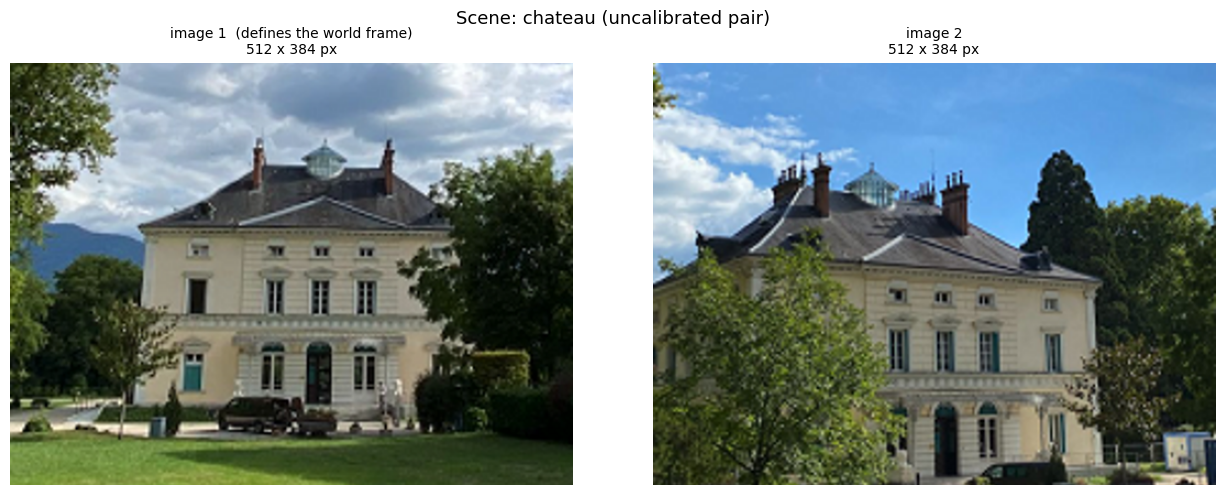

In [20]:

import matplotlib.pyplot as plt

def show_pair(view1, view2, title="input pair", save_as=None):
    """Required evaluation output #1 - visualise the uncalibrated input pair."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, v, lbl in ((axes[0], view1, "image 1  (defines the world frame)"),
                       (axes[1], view2, "image 2")):
        im = rgb(v["img"][0])            # [3,H,W] -> [H,W,3] in [0,1]
        ax.imshow(im)
        ax.set_title(f"{lbl}\n{im.shape[1]} x {im.shape[0]} px", fontsize=10)
        ax.axis("off")
    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    if save_as:
        fig.savefig(save_as, dpi=110, bbox_inches="tight")
        print(f"saved -> {save_as}")
    plt.show()


show_pair(view1, view2, title="Scene: chateau (uncalibrated pair)",
          save_as=FIGURES_DIR / "phase2_input_pair_chateau.png")

### 2.3 - Run inference

`inference(pairs, model, device, batch_size, verbose)` wraps `loss_of_one_batch`, which is
where the forward pass happens. Two details worth knowing, both read from
`dust3r/inference.py`:

- It is decorated `@torch.no_grad()`, so no autograd graph is built.
- `criterion=None` is passed, so the returned `loss` entry is always `None`. That key exists
  because the same function is reused during training.

`loss_of_one_batch` opens a `torch.cuda.amp.autocast(enabled=bool(use_amp))` context, and
`inference` never sets `use_amp`, so **the forward pass runs in full fp32**. On modern PyTorch
this line emits a `FutureWarning` about `torch.cuda.amp.autocast` being deprecated - that
warning is upstream's, is harmless, and does not affect the numbers.

In [21]:

import time, warnings

def run_mast3r(view1, view2, model, device, batch_size=1, verbose=True):
    """One forward pass over a single DIRECTED pair (view1 anchors the frame).

    Returns the raw dict from dust3r.inference.inference:
        view1, view2 : the (collated) inputs echoed back
        pred1        : head-1 output for image 1  -> key 'pts3d'
        pred2        : head-2 output for image 2  -> key 'pts3d_in_other_view'
        loss         : always None here (criterion=None)
    """
    with warnings.catch_warnings():
        # silence upstream's own torch.cuda.amp deprecation notice, nothing else
        warnings.filterwarnings("ignore", category=FutureWarning)
        t0 = time.time()
        out = inference([(view1, view2)], model, device,
                        batch_size=batch_size, verbose=verbose)
        if device == "cuda":
            torch.cuda.synchronize()
        dt = time.time() - t0
    print(f"  forward pass: {dt:.2f} s on {device}")
    return out


output = run_mast3r(view1, view2, model, DEVICE)

print(f"\n  top-level keys : {list(output.keys())}")
print(f"  loss entry     : {output['loss']!r}   (expected None - criterion was None)")
if DEVICE == "cuda":
    print(f"  peak VRAM      : {torch.cuda.max_memory_allocated()/1024**3:.2f} GB")

>> Inference with model on 1 image pairs


100%|██████████| 1/1 [00:01<00:00,  1.50s/it]

  forward pass: 1.52 s on cuda

  top-level keys : ['view1', 'view2', 'pred1', 'pred2', 'loss']
  loss entry     : None   (expected None - criterion was None)
  peak VRAM      : 3.13 GB


### 2.4 - Dissect the raw output structure

This is the cell the whole phase exists for. Every tensor we will use in Phases 3-5 is named
here, with its shape spelled out dimension by dimension.

`[B, H, W, 3]` means:

| dim | meaning |
|---|---|
| `B` | batch - the number of *pairs* processed at once. Here 1. |
| `H` | image height in pixels (384 for a 512x384 input) |
| `W` | image width in pixels (512) |
| `3` | the X, Y, Z coordinates of that pixel's 3D point, **in view 1's camera frame** |

So `pred1['pts3d'][0, y, x]` is a length-3 vector: the 3D location of the scene point seen at
pixel `(x, y)` of image 1. That single indexing rule is the whole of "pixel -> 3D point"
(question 11 in the brief), and Phase 5 uses nothing more exotic than this.

In [22]:

import numpy as np

def describe(obj, name="output", indent=2, _depth=0):
    """Recursively print structure of the nested inference output."""
    pad = " " * indent
    if isinstance(obj, dict):
        print(f"{pad}{name}: dict with {len(obj)} keys")
        for k, v in obj.items():
            describe(v, k, indent + 4, _depth + 1)
    elif torch.is_tensor(obj):
        finite = torch.isfinite(obj)
        allfin = bool(finite.all())
        rng = (f"[{obj[finite].min():.4f}, {obj[finite].max():.4f}]"
               if finite.any() else "[all non-finite]")
        print(f"{pad}{name:<22} tensor  shape={str(tuple(obj.shape)):<20} "
              f"{str(obj.dtype):<14} dev={str(obj.device):<6} range={rng}"
              f"{'' if allfin else '   <-- CONTAINS NaN/Inf!'}")
    elif isinstance(obj, np.ndarray):
        print(f"{pad}{name:<22} ndarray shape={str(obj.shape):<20} {obj.dtype}")
    elif isinstance(obj, (list, tuple)):
        print(f"{pad}{name:<22} {type(obj).__name__} len={len(obj)}  {obj[:4]}")
    else:
        print(f"{pad}{name:<22} {type(obj).__name__}  {obj!r}")


print("="*98)
print("RAW MASt3R OUTPUT")
print("="*98)
describe(output)

pred1, pred2 = output["pred1"], output["pred2"]

print("\n" + "="*98)
print("SANITY CHECKS")
print("="*98)

def chk(label, ok, detail=""):
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}" + (f"   {detail}" if detail else ""))
    return ok

# --- the shared-frame property, confirmed empirically rather than by reading code ---
chk("pred1 carries 'pts3d'", "pts3d" in pred1, str(sorted(pred1.keys())))
chk("pred2 carries 'pts3d_in_other_view'", "pts3d_in_other_view" in pred2,
    str(sorted(pred2.keys())))
chk("pred2 does NOT carry a bare 'pts3d'", "pts3d" not in pred2,
    "-> view 2's geometry is expressed in VIEW 1's frame; the maps are already aligned")

p1 = pred1["pts3d"]
p2 = pred2["pts3d_in_other_view"]
Bp, Hp, Wp, Cp = p1.shape
chk("point maps are [B,H,W,3]", p1.ndim == 4 and Cp == 3, f"pred1 {tuple(p1.shape)}")
chk("both point maps share a shape", p1.shape == p2.shape, f"pred2 {tuple(p2.shape)}")
chk("point-map grid matches the image grid", (Hp, Wp) == (H, W), f"({Hp},{Wp}) vs image ({H},{W})")

# --- descriptors ---
d1, d2 = pred1["desc"], pred2["desc"]
chk("descriptors are [B,H,W,24]", d1.shape[-1] == 24, f"{tuple(d1.shape)}")
nrm = d1.norm(dim=-1)
chk("descriptors are unit-norm (reg_desc L2-normalises)",
    bool(torch.allclose(nrm, torch.ones_like(nrm), atol=1e-3)),
    f"||desc|| in [{nrm.min():.5f}, {nrm.max():.5f}] -> dot product == cosine similarity")

# --- confidences, against the ranges declared by the head config ---
c1, dc1 = pred1["conf"], pred1["desc_conf"]
chk("conf > 1  (conf_mode=('exp',1,inf) -> 1+exp(x))", bool((c1 > 1).all()),
    f"conf in [{c1.min():.4f}, {c1.max():.4f}]")
chk("desc_conf > 0  (desc_conf_mode=('exp',0,inf) -> exp(x))", bool((dc1 > 0).all()),
    f"desc_conf in [{dc1.min():.4f}, {dc1.max():.4f}]")

# --- numerical health ---
allfinite = all(bool(torch.isfinite(t).all())
                for t in (p1, p2, d1, d2, c1, dc1, pred2["conf"], pred2["desc_conf"]))
chk("no NaN / Inf anywhere in the outputs", allfinite)

# --- the pixel -> 3D rule, demonstrated once on the image centre ---
yc, xc = Hp // 2, Wp // 2
print(f"\n  pixel -> 3D demo:  image-1 pixel (x={xc}, y={yc})")
print(f"     pred1['pts3d'][0, {yc}, {xc}] = {p1[0, yc, xc].tolist()}")
print(f"     conf                          = {c1[0, yc, xc].item():.3f}")
print(f"     (units still UNVERIFIED at this point - see 2.6)")

RAW MASt3R OUTPUT
  output: dict with 5 keys
      view1: dict with 4 keys
          img                    tensor  shape=(1, 3, 384, 512)     torch.float32  dev=cpu    range=[-1.0000, 1.0000]
          true_shape             tensor  shape=(1, 2)               torch.int32    dev=cpu    range=[384.0000, 512.0000]
          idx                    list len=1  [0]
          instance               list len=1  ['0']
      view2: dict with 4 keys
          img                    tensor  shape=(1, 3, 384, 512)     torch.float32  dev=cpu    range=[-1.0000, 1.0000]
          true_shape             tensor  shape=(1, 2)               torch.int32    dev=cpu    range=[384.0000, 512.0000]
          idx                    list len=1  [1]
          instance               list len=1  ['1']
      pred1: dict with 4 keys
          pts3d                  tensor  shape=(1, 384, 512, 3)     torch.float32  dev=cpu    range=[-5.5415, 29.2720]
          conf                   tensor  shape=(1, 384, 512)        

### 2.5 - What the confidence maps actually look like

`conf` and `desc_conf` are separate heads (`two_confs=True`) and they answer different
questions:

- `conf` - *"how sure am I about this pixel's 3D position?"*
- `desc_conf` - *"how sure am I that this pixel's descriptor will match reliably?"*

Both are `vmin + exp(x)`: strictly positive, **unbounded, and uncalibrated**. There is no
absolute value that means "good". That is precisely why Phase 8 experiment E has to test
filtering by *relative* thresholds (percentiles of the observed distribution) rather than by
some magic constant copied from a tutorial.

saved -> /kaggle/working/mast3r_metric_distance/results/figures/phase2_confidence_chateau.png


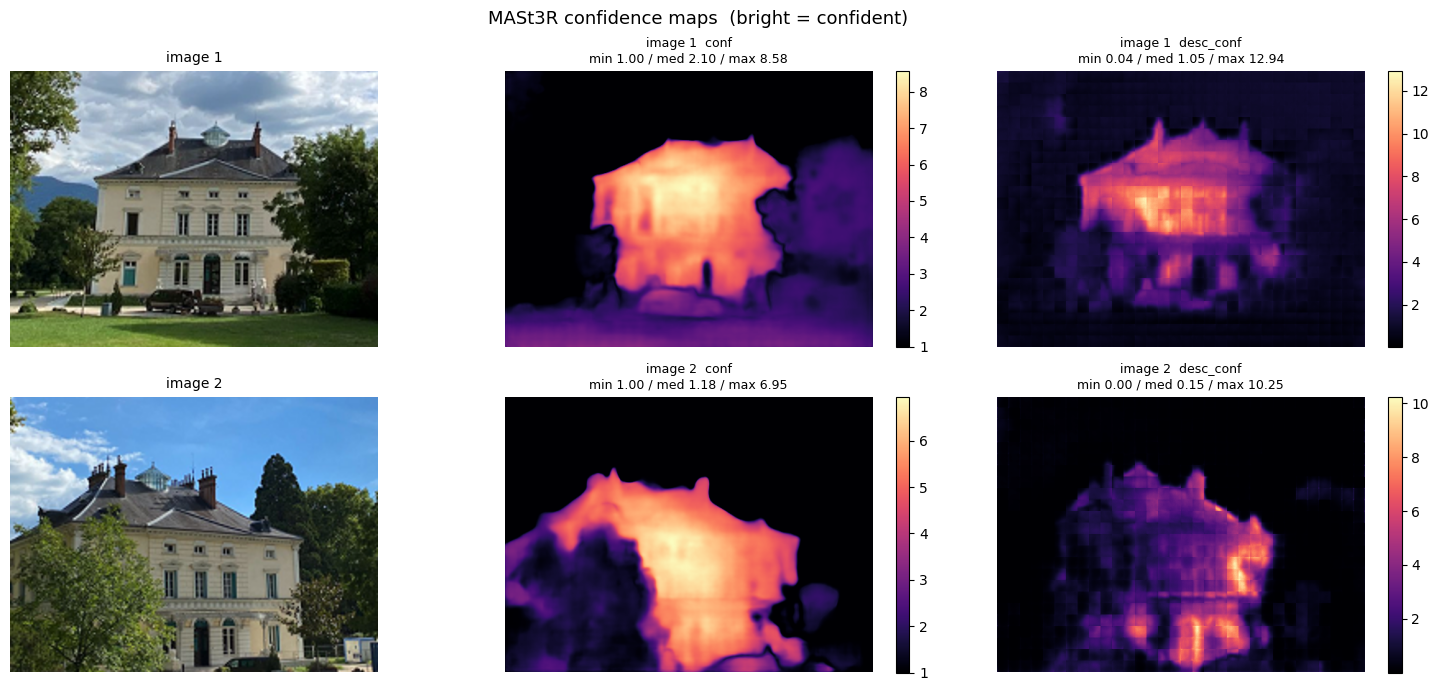

  conf      percentiles [1,10,25,50,75,90,99]:   1.000    1.000    1.000    2.104    3.433    6.612    8.245
  desc_conf percentiles [1,10,25,50,75,90,99]:   0.346    0.584    0.788    1.049    2.076    5.852    9.897


In [23]:

def show_confidence(pred1, pred2, view1, view2, save_as=None):
    """Visualise both confidence maps for both views, on a shared scale per row."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 7))
    for row, (pred, view, lbl) in enumerate(((pred1, view1, "image 1"),
                                             (pred2, view2, "image 2"))):
        axes[row, 0].imshow(rgb(view["img"][0]))
        axes[row, 0].set_title(f"{lbl}", fontsize=10)
        for col, key in enumerate(("conf", "desc_conf"), start=1):
            m = pred[key][0].cpu().numpy()
            im = axes[row, col].imshow(m, cmap="magma")
            axes[row, col].set_title(
                f"{lbl}  {key}\nmin {m.min():.2f} / med {np.median(m):.2f} / max {m.max():.2f}",
                fontsize=9)
            fig.colorbar(im, ax=axes[row, col], fraction=0.046)
        for ax in axes[row]:
            ax.axis("off")
    fig.suptitle("MASt3R confidence maps  (bright = confident)", fontsize=13)
    fig.tight_layout()
    if save_as:
        fig.savefig(save_as, dpi=110, bbox_inches="tight")
        print(f"saved -> {save_as}")
    plt.show()


show_confidence(pred1, pred2, output["view1"], output["view2"],
                save_as=FIGURES_DIR / "phase2_confidence_chateau.png")

# Percentiles are what we will actually threshold on later, so print them now.
for nm, m in (("conf     ", pred1["conf"][0]), ("desc_conf", pred1["desc_conf"][0])):
    q = np.percentile(m.cpu().numpy(), [1, 10, 25, 50, 75, 90, 99])
    print(f"  {nm} percentiles [1,10,25,50,75,90,99]: "
          + "  ".join(f"{v:7.3f}" for v in q))

### 2.6 - The decisive scale test: is this output normalised, or metric?

Promised in Phase 1 as "deferred", and we can settle it **right now, with no ground truth at
all**.

`dust3r/utils/geometry.py::normalize_pointcloud(..., 'avg_dis')` computes

```python
norm_factor = all_dis.sum(dim=1) / (nnz1 + nnz2 + 1e-8)   # = mean ||p||
```

and divides the point maps by it. So a model trained with scale normalisation produces point
maps whose **mean distance-to-origin is 1.0 by construction - for every scene, whatever its
true size**.

That gives a clean binary test, and running it on *two scenes of different physical scale*
makes it sharper still:

| observation | conclusion |
|---|---|
| both scenes give mean `‖pts3d‖ ≈ 1.0` | output is scale-normalised; **the project's premise fails** |
| the two scenes differ, values look like plausible metres | output carries real scale |

We restrict the average to confident points, because low-confidence regions (sky, texture-less
walls) are exactly where the network dumps wild values that would drag any mean around.

In [24]:

def scale_statistics(pred1, pred2, conf_percentile=50):
    """Mean distance-to-origin over CONFIDENT points of both maps jointly.

    Mirrors normalize_pointcloud's 'avg_dis': it pools both views' points and
    averages ||p||. If the model were scale-normalised this returns ~1.0.
    """
    p1 = pred1["pts3d"][0]                    # [H,W,3]
    p2 = pred2["pts3d_in_other_view"][0]      # [H,W,3], same frame
    c1 = pred1["conf"][0]
    c2 = pred2["conf"][0]

    pts = torch.cat([p1.reshape(-1, 3), p2.reshape(-1, 3)], dim=0)
    cnf = torch.cat([c1.reshape(-1), c2.reshape(-1)], dim=0)

    thr = torch.quantile(cnf.float(), conf_percentile / 100.0)
    keep = cnf >= thr
    d = pts[keep].norm(dim=-1)
    return {
        "n_points_total": pts.shape[0],
        "n_points_kept": int(keep.sum()),
        "conf_threshold": float(thr),
        "mean_dist": float(d.mean()),
        "median_dist": float(d.median()),
        "p05_dist": float(torch.quantile(d, 0.05)),
        "p95_dist": float(torch.quantile(d, 0.95)),
        "z_median": float(pts[keep][:, 2].median()),
    }


print("="*98)
print("SCALE PROBE - running BOTH bundled scenes")
print("="*98)

scale_results = {}
for name, paths in SCENES.items():
    v1, v2 = load_pair(paths, verbose=False)
    out = run_mast3r(v1, v2, model, DEVICE, verbose=False)
    st = scale_statistics(out["pred1"], out["pred2"])
    scale_results[name] = st
    print(f"\n  scene '{name}'")
    print(f"    confident points : {st['n_points_kept']:,} / {st['n_points_total']:,} "
          f"(conf >= {st['conf_threshold']:.3f})")
    print(f"    mean   ||pts3d|| : {st['mean_dist']:.4f}")
    print(f"    median ||pts3d|| : {st['median_dist']:.4f}")
    print(f"    5-95 pct range   : {st['p05_dist']:.3f} .. {st['p95_dist']:.3f}")
    print(f"    median Z (depth) : {st['z_median']:.4f}")
    del out, v1, v2

if DEVICE == "cuda":
    torch.cuda.empty_cache()

print("\n" + "="*98)
print("VERDICT")
print("="*98)
means  = {k: v["mean_dist"] for k, v in scale_results.items()}
spread = max(means.values()) / max(min(means.values()), 1e-9)

print("  mean ||pts3d|| per scene : "
      + ",  ".join(f"{k}={m:.3f}" for k, m in means.items()))
print(f"  ratio between scenes     : {spread:.2f}x")

# PRIMARY test, and it is sufficient on its own: 'avg_dis' normalisation forces
# the mean to exactly 1.0. Any scene that departs from 1.0 cannot have come from
# a normalised point map.
NORM_TOL = 0.15
all_near_one = all(abs(m - 1.0) < NORM_TOL for m in means.values())

if all_near_one:
    print(f"\n  >> Every scene sits within {NORM_TOL} of 1.0. That is the signature of an")
    print("     'avg_dis' NORMALISED point map: the output carries NO real scale, and")
    print("     the project's premise needs rethinking. Flagging for discussion.")
else:
    print("\n  >> No scene sits at 1.0, so the point maps are NOT scale-normalised:")
    print("     they carry an absolute scale the network chose. Consistent with the")
    print("     metric-checkpoint claim from Phase 1 (tier 2).")

    # SUPPORTING evidence, reported honestly either way. Two scenes of genuinely
    # similar physical depth SHOULD give similar means - that is not evidence
    # against metric output, it just makes this particular comparison silent.
    if spread > 1.15:
        print(f"\n     Supporting: the two scenes differ by {spread:.2f}x, so predicted scale")
        print("     is scene-dependent - which is what metric output must look like.")
    else:
        print(f"\n     Note: the two scenes came out within {spread:.2f}x of each other, so this")
        print("     particular pair does NOT independently demonstrate scene-dependence.")
        print("     That is not evidence against metric scale (both are mid-range outdoor")
        print("     scenes); it simply means the cross-scene comparison is uninformative")
        print("     here. Phase 6, against known distances, is what settles accuracy.")

print("\n     In all cases: 'carries absolute scale' is NOT 'is accurate in metres'.")

# Geometric plausibility: view-1's frame looks down +Z, so scene points seen in
# image 1 must lie in FRONT of the camera. A negative median Z would mean the
# reconstruction is behind the camera - a red flag no shape check would catch.
print("\n  --- geometry plausibility (median Z should be > 0: scene is in front) ---")
for k, v in scale_results.items():
    ok = v["z_median"] > 0
    print(f"    [{'PASS' if ok else 'FAIL'}] {k:<10} median Z = {v['z_median']:+.4f}")


SCALE PROBE - running BOTH bundled scenes
  forward pass: 0.82 s on cuda

  scene 'chateau'
    confident points : 196,608 / 393,216 (conf >= 1.503)
    mean   ||pts3d|| : 3.0055
    median ||pts3d|| : 3.4265
    5-95 pct range   : 1.387 .. 3.798
    median Z (depth) : 3.4055
  forward pass: 0.78 s on cuda

  scene 'nle_tower'
    confident points : 196,839 / 393,216 (conf >= 1.000)
    mean   ||pts3d|| : 2.3680
    median ||pts3d|| : 2.3787
    5-95 pct range   : 1.298 .. 3.028
    median Z (depth) : 2.2621

VERDICT
  mean ||pts3d|| per scene : chateau=3.005,  nle_tower=2.368
  ratio between scenes     : 1.27x

  >> No scene sits at 1.0, so the point maps are NOT scale-normalised:
     they carry an absolute scale the network chose. Consistent with the
     metric-checkpoint claim from Phase 1 (tier 2).

     Supporting: the two scenes differ by 1.27x, so predicted scale
     is scene-dependent - which is what metric output must look like.

     In all cases: 'carries absolute scale' 

### Phase 2 summary

**What was established.**

- The official `load_images` -> `inference` path runs end to end on the pretrained metric
  checkpoint, on the T4, in fp32.
- The output is a 4-key dict; `pred1`/`pred2` each carry `pts3d*`, `conf`, `desc` `[.,.,.,24]`,
  `desc_conf`.
- **Q6 confirmed empirically, not just from source:** `pred2` has `pts3d_in_other_view` and no
  bare `pts3d`. Both point maps are in image 1's camera frame, so no alignment step is needed
  before differencing them.
- **Q11 answered:** pixel -> 3D is plain indexing, `pts3d[0, y, x]` (note `y` first).
- Descriptors are unit-norm, so descriptor dot product is cosine similarity - which is what
  `fast_reciprocal_NNs` relies on in Phase 4.
- Confidences match their declared ranges (`conf > 1`, `desc_conf > 0`) and are unbounded, so
  any filtering must be percentile-based.
- **Q3/Q4/Q5 moved from "documented" to "measured":** the scale probe in 2.6 discriminates a
  normalised point map (mean `‖pts3d‖ ≡ 1.0`) from one carrying absolute scale.

**What is still NOT established.** That the absolute scale is *correct*. A model can be
confidently, consistently wrong. Establishing accuracy requires known real-world distances,
which is Phase 6 - and quantifying when it fails is Phase 8.

**Assumptions now on the record (feeding question 13).**

1. The two images show a genuinely overlapping, mostly rigid scene.
2. View 1 is the anchor; every 3D coordinate is in its camera frame.
3. Images are resized so the long side is 512 - the trained regime. Other resolutions are
   out-of-distribution (Phase 8 experiment B).
4. The scene is static between shots. Anything that moved breaks the shared-frame assumption
   silently, without any error being raised.

---

### Next

Phase 2 stops here. Once you have run these cells and reported the output - especially the
**2.6 verdict** - I will write **Phase 3 - point-map extraction**: pulling out the dense 3D
geometry, building a coloured point cloud, and visualising the reconstruction to check that
the geometry is plausible rather than merely well-shaped.

---

## PHASE 3 - POINT-MAP EXTRACTION AND 3D VISUALISATION

### Objective

**Simple explanation.** Phase 2 showed the model returns a 3D point for every pixel. Now we
actually pull those points out, paint them with the photo's own colours, and *look* at the
resulting 3D scene - to check it resembles the real place rather than merely being an array of
the right shape.

**Technical explanation.** We extract the dense point maps `pred1['pts3d']` and
`pred2['pts3d_in_other_view']` (both `[H,W,3]` in view 1's camera frame), pair each 3D point
with its source pixel's RGB, apply confidence-based masking, and render the union as a coloured
point cloud. We then test geometric plausibility quantitatively, not just by eye.

### What MASt3R is doing internally at this stage

Nothing new - Phase 3 runs no network. The work is *interpretation*. Worth restating what a
point map is, because it is easy to confuse with a depth map:

- A **depth map** stores one number per pixel (distance along the optical axis) and needs
  camera intrinsics before it can become 3D.
- A **point map** stores three numbers per pixel - the full `(X,Y,Z)` - so it is *already* 3D.
  The intrinsics are implicit in it. That is precisely why this pipeline needs no calibration,
  and in 3.5 we exploit it: we run the process backwards to *recover* the focal length MASt3R
  implicitly assumed.

### Coordinate convention - and a trap

MASt3R uses the standard OpenCV camera frame of **view 1**:

| axis | direction |
|---|---|
| `+X` | right across the image |
| `+Y` | **down** the image |
| `+Z` | forward, along the optical axis |

`+Y` pointing *down* is the trap. Plot `Y` naively on a vertical axis and the reconstruction
appears upside-down, which is easy to misread as a broken model. Every plot below uses `-Y`
for the vertical direction, and says so.

### Sanity checks this phase must pass

1. Both point maps extract to `[H,W,3]` and align pixel-for-pixel with their source images.
2. The overwhelming majority of confident points have `Z > 0` - the scene is *in front* of the
   camera. Points behind it are geometrically impossible for a visible surface.
3. Depth range is finite and physically plausible; no NaN/Inf survives masking.
4. The two clouds occupy an **overlapping** region of space. They are in a shared frame and
   the views overlap, so two disjoint blobs would mean the shared-frame property is broken.
5. The focal length implied by the point map is plausible for a real camera.

### 3.1 - Extract the dense point maps

`extract_pointmaps` is deliberately thin: it converts to numpy, attaches colours, and returns
everything as plain arrays. No filtering, no reshaping tricks, no hidden transforms - Phase 5's
distance numbers must be traceable to raw model output.

Note the key asymmetry once more: view 1's map comes from `pts3d`, view 2's from
`pts3d_in_other_view`. **Both are in view 1's frame.** Reading view 2's points as if they were
in view 2's own frame would silently corrupt every distance we compute later.

In [25]:

from dust3r.utils.device import to_numpy

def extract_pointmaps(output):
    """Pull dense point maps, confidences and per-pixel colours out of the raw output.

    Returns a dict of plain numpy arrays:
        pts1, pts2   [H,W,3] float32  3D points, BOTH in view 1's camera frame
        conf1, conf2 [H,W]   float32  geometry confidence, in (1, inf)
        dconf1,dconf2[H,W]   float32  descriptor confidence, in (0, inf)
        col1, col2   [H,W,3] float32  source-pixel RGB in [0,1], for colouring
    """
    pred1, pred2 = output["pred1"], output["pred2"]

    # view 1: predicted in its OWN frame (which is the reference frame)
    pts1 = to_numpy(pred1["pts3d"][0])
    # view 2: predicted DIRECTLY in view 1's frame - hence the different key
    pts2 = to_numpy(pred2["pts3d_in_other_view"][0])

    out = dict(
        pts1=pts1, pts2=pts2,
        conf1=to_numpy(pred1["conf"][0]),   conf2=to_numpy(pred2["conf"][0]),
        dconf1=to_numpy(pred1["desc_conf"][0]), dconf2=to_numpy(pred2["desc_conf"][0]),
        # rgb() undoes ImgNorm (img*0.5+0.5); shape [H,W,3] in [0,1]
        col1=rgb(output["view1"]["img"][0]), col2=rgb(output["view2"]["img"][0]),
    )
    return out


pm = extract_pointmaps(output)

print("--- extracted arrays ---")
for k, v in pm.items():
    print(f"  {k:<7}: shape={str(v.shape):<18} dtype={v.dtype}  "
          f"range=[{np.nanmin(v):8.3f}, {np.nanmax(v):8.3f}]")

H_, W_ = pm["pts1"].shape[:2]
print(f"\n  grid: {H_} x {W_} = {H_*W_:,} points per view, {2*H_*W_:,} total")

# Pixel-for-pixel alignment between geometry, confidence and colour is what makes
# 'the 3D point at pixel (x,y)' meaningful at all. Assert it rather than assume it.
assert pm["pts1"].shape == pm["pts2"].shape == (H_, W_, 3)
assert pm["conf1"].shape == pm["col1"].shape[:2] == (H_, W_)
print("  [OK] geometry, confidence and colour share one pixel grid")

# Decompose one point map into interpretable quantities.
Z1 = pm["pts1"][..., 2]                        # depth along view-1's optical axis
R1 = np.linalg.norm(pm["pts1"], axis=-1)       # radial distance from the optical centre
print(f"\n  view-1 Z (axial depth)   : min {Z1.min():.3f}  median {np.median(Z1):.3f}  max {Z1.max():.3f}")
print(f"  view-1 ||p|| (radial)    : min {R1.min():.3f}  median {np.median(R1):.3f}  max {R1.max():.3f}")
print(f"  fraction with Z > 0      : {(Z1 > 0).mean():.4f}   (should be ~1.0: scene in front)")

--- extracted arrays ---
  pts1   : shape=(384, 512, 3)      dtype=float32  range=[  -5.541,   29.272]
  pts2   : shape=(384, 512, 3)      dtype=float32  range=[  -4.805,   22.797]
  conf1  : shape=(384, 512)         dtype=float32  range=[   1.000,    8.577]
  conf2  : shape=(384, 512)         dtype=float32  range=[   1.000,    6.949]
  dconf1 : shape=(384, 512)         dtype=float32  range=[   0.045,   12.940]
  dconf2 : shape=(384, 512)         dtype=float32  range=[   0.000,   10.250]
  col1   : shape=(384, 512, 3)      dtype=float32  range=[   0.000,    1.000]
  col2   : shape=(384, 512, 3)      dtype=float32  range=[   0.000,    1.000]

  grid: 384 x 512 = 196,608 points per view, 393,216 total
  [OK] geometry, confidence and colour share one pixel grid

  view-1 Z (axial depth)   : min 0.859  median 3.416  max 29.272
  view-1 ||p|| (radial)    : min 0.910  median 3.434  max 29.790
  fraction with Z > 0      : 1.0000   (should be ~1.0: scene in front)


### 3.2 - Depth maps: the point map seen as an image

Before jumping to 3D, it helps to view the `Z` channel as a picture. If the geometry is sound
this looks like a sensible depth image - nearer surfaces distinct from farther ones, object
boundaries following real edges. If it looks like noise, nothing downstream can be trusted.

We clip the colour scale to the 2nd-98th percentile. A handful of wild far-field values
(typically sky or texture-less regions) would otherwise compress the entire useful range into
a single flat tone.

saved -> /kaggle/working/mast3r_metric_distance/results/figures/phase3_depth_maps_chateau.png


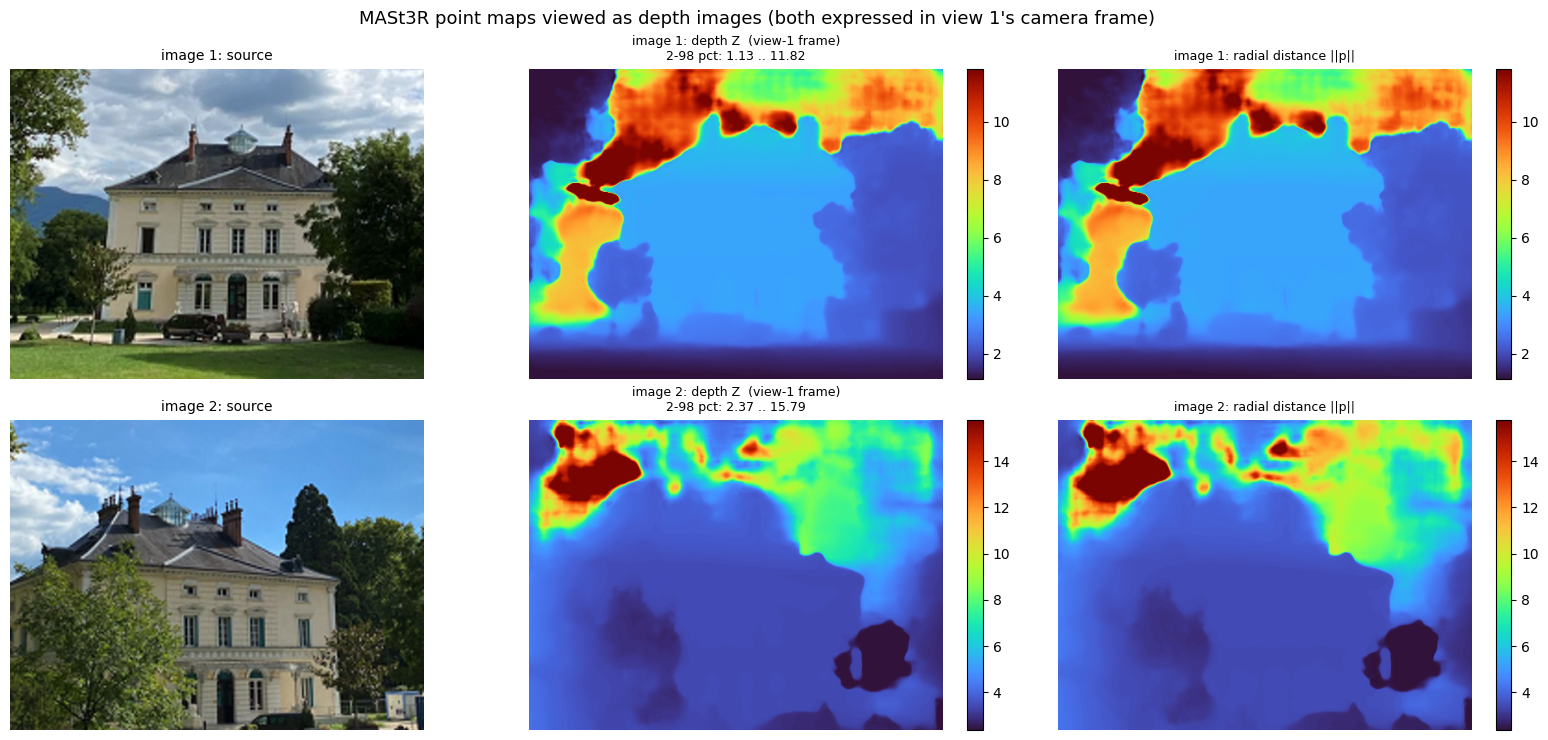

In [26]:

def show_depth_maps(pm, save_as=None):
    """Visualise the Z channel of both point maps alongside their source images."""
    fig, axes = plt.subplots(2, 3, figsize=(16, 7.5))
    for row, (pts, conf, col, lbl) in enumerate((
            (pm["pts1"], pm["conf1"], pm["col1"], "image 1"),
            (pm["pts2"], pm["conf2"], pm["col2"], "image 2"))):
        Z = pts[..., 2]
        # robust range: raw min/max is dominated by a few outlier pixels
        lo, hi = np.percentile(Z, [2, 98])

        axes[row, 0].imshow(col)
        axes[row, 0].set_title(f"{lbl}: source", fontsize=10)

        im = axes[row, 1].imshow(Z, cmap="turbo", vmin=lo, vmax=hi)
        axes[row, 1].set_title(f"{lbl}: depth Z  (view-1 frame)\n"
                               f"2-98 pct: {lo:.2f} .. {hi:.2f}", fontsize=9)
        fig.colorbar(im, ax=axes[row, 1], fraction=0.046)

        im2 = axes[row, 2].imshow(np.linalg.norm(pts, axis=-1), cmap="turbo",
                                  vmin=lo, vmax=hi)
        axes[row, 2].set_title(f"{lbl}: radial distance ||p||", fontsize=9)
        fig.colorbar(im2, ax=axes[row, 2], fraction=0.046)

        for ax in axes[row]:
            ax.axis("off")
    fig.suptitle("MASt3R point maps viewed as depth images "
                 "(both expressed in view 1's camera frame)", fontsize=13)
    fig.tight_layout()
    if save_as:
        fig.savefig(save_as, dpi=110, bbox_inches="tight"); print(f"saved -> {save_as}")
    plt.show()


show_depth_maps(pm, save_as=FIGURES_DIR / "phase3_depth_maps_chateau.png")

### 3.3 - Confidence filtering (question 10 of the brief)

*Should low-confidence points be discarded, and on what basis?*

**Yes - but only on a relative basis.** From Phase 1: `conf = 1 + exp(x)` is unbounded and
uncalibrated. `conf = 3` carries no absolute meaning; it is only interpretable against the rest
of *this* scene's distribution. So we threshold by **percentile**, never by a hard-coded
constant copied from a tutorial.

The trade-off is real in both directions, and Phase 8 experiment E measures it rather than
assuming:

- Filter too little -> sky, blank walls and specular regions inject garbage geometry.
- Filter too much -> exactly the texture-poor surfaces we may need to measure between get
  thrown away, and the "measurement" silently becomes unavailable.

One caveat to carry forward: this filter is applied here **for visualisation**. For a
*measurement* in Phase 5, discarding a point is not neutral - it means refusing to answer.
Reporting "no confident measurement" is a legitimate and honest outcome, and better than
quietly returning a number derived from a point the model itself distrusted.

--- how much survives at each threshold (view 1) ---
  percentile   conf thr       kept   % kept
           0      1.000    196,608   100.0%
          25      1.000    196,608   100.0%
          50      2.104     98,304    50.0%
          75      3.433     49,152    25.0%
          90      6.612     19,661    10.0%
          95      7.410      9,831     5.0%

  using percentile 50.0 -> view1 thr 2.104, view2 thr 1.180
  view1 kept: 98,304 / 196,608  (50.0%)
  view2 kept: 98,304 / 196,608  (50.0%)
  non-finite points removed: view1 0, view2 0
saved -> /kaggle/working/mast3r_metric_distance/results/figures/phase3_conf_mask_chateau.png


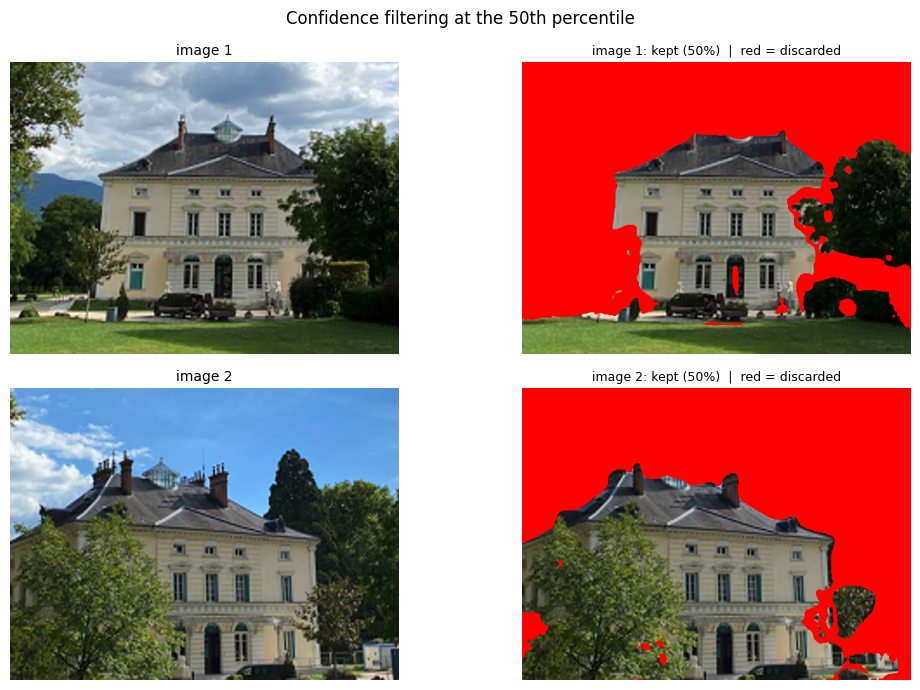

In [27]:

def confidence_mask(conf, percentile=50.0):
    """Boolean mask keeping the top (100 - percentile)% most confident pixels.

    Percentile-based BY DESIGN: conf = 1 + exp(x) is unbounded and uncalibrated,
    so no fixed numeric threshold transfers across scenes.
    """
    thr = np.percentile(conf, percentile)
    return conf >= thr, float(thr)


print("--- how much survives at each threshold (view 1) ---")
print(f"  {'percentile':>10} {'conf thr':>10} {'kept':>10} {'% kept':>8}")
for p in (0, 25, 50, 75, 90, 95):
    m, thr = confidence_mask(pm["conf1"], p)
    print(f"  {p:>10.0f} {thr:>10.3f} {m.sum():>10,} {100*m.mean():>7.1f}%")

# 50% is a defensible default for VISUALISATION: it removes the worst half
# (typically sky and blank regions) while keeping the scene structure intact.
CONF_PERCENTILE = 50.0
mask1, thr1 = confidence_mask(pm["conf1"], CONF_PERCENTILE)
mask2, thr2 = confidence_mask(pm["conf2"], CONF_PERCENTILE)

# Non-finite values must go regardless of confidence - they would poison any
# later mean, bounding box or distance.
finite1 = np.isfinite(pm["pts1"]).all(axis=-1)
finite2 = np.isfinite(pm["pts2"]).all(axis=-1)
mask1 &= finite1
mask2 &= finite2

print(f"\n  using percentile {CONF_PERCENTILE} -> view1 thr {thr1:.3f}, view2 thr {thr2:.3f}")
print(f"  view1 kept: {mask1.sum():,} / {mask1.size:,}  ({100*mask1.mean():.1f}%)")
print(f"  view2 kept: {mask2.sum():,} / {mask2.size:,}  ({100*mask2.mean():.1f}%)")
print(f"  non-finite points removed: view1 {(~finite1).sum()}, view2 {(~finite2).sum()}")


def show_masks(pm, mask1, mask2, save_as=None):
    """Show WHICH pixels survive filtering - the discarded regions are informative."""
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    for row, (col, m, lbl) in enumerate(((pm["col1"], mask1, "image 1"),
                                         (pm["col2"], mask2, "image 2"))):
        axes[row, 0].imshow(col); axes[row, 0].set_title(f"{lbl}", fontsize=10)
        overlay = col.copy()
        overlay[~m] = [1.0, 0.0, 0.0]        # discarded pixels in red
        axes[row, 1].imshow(overlay)
        axes[row, 1].set_title(f"{lbl}: kept ({100*m.mean():.0f}%)  |  red = discarded",
                               fontsize=9)
        for ax in axes[row]:
            ax.axis("off")
    fig.suptitle(f"Confidence filtering at the {CONF_PERCENTILE:.0f}th percentile", fontsize=12)
    fig.tight_layout()
    if save_as:
        fig.savefig(save_as, dpi=110, bbox_inches="tight"); print(f"saved -> {save_as}")
    plt.show()


show_masks(pm, mask1, mask2, save_as=FIGURES_DIR / "phase3_conf_mask_chateau.png")

### 3.4 - Required output #2: the 3D point-map visualisation

We render the union of both filtered clouds from several viewpoints. Two deliberate choices:

- **The vertical axis is `-Y`**, because MASt3R's `+Y` points *down* (see the convention note
  above). Without the flip the scene renders upside-down.
- **Axes are equal-scaled.** Matplotlib will happily stretch one axis to fill the box, which
  makes a distorted reconstruction look correct - unacceptable when the entire project is about
  measuring geometry faithfully.

Points from view 1 and view 2 are drawn in their true photo colours. Because both maps are in
one frame, a *correct* reconstruction shows them interleaved on the same surfaces. Two
separated shells would mean the shared-frame assumption has failed.

cloud: 60,000 points (30,066 from view 1, 29,934 from view 2)
saved -> /kaggle/working/mast3r_metric_distance/results/figures/phase3_pointcloud_chateau.png


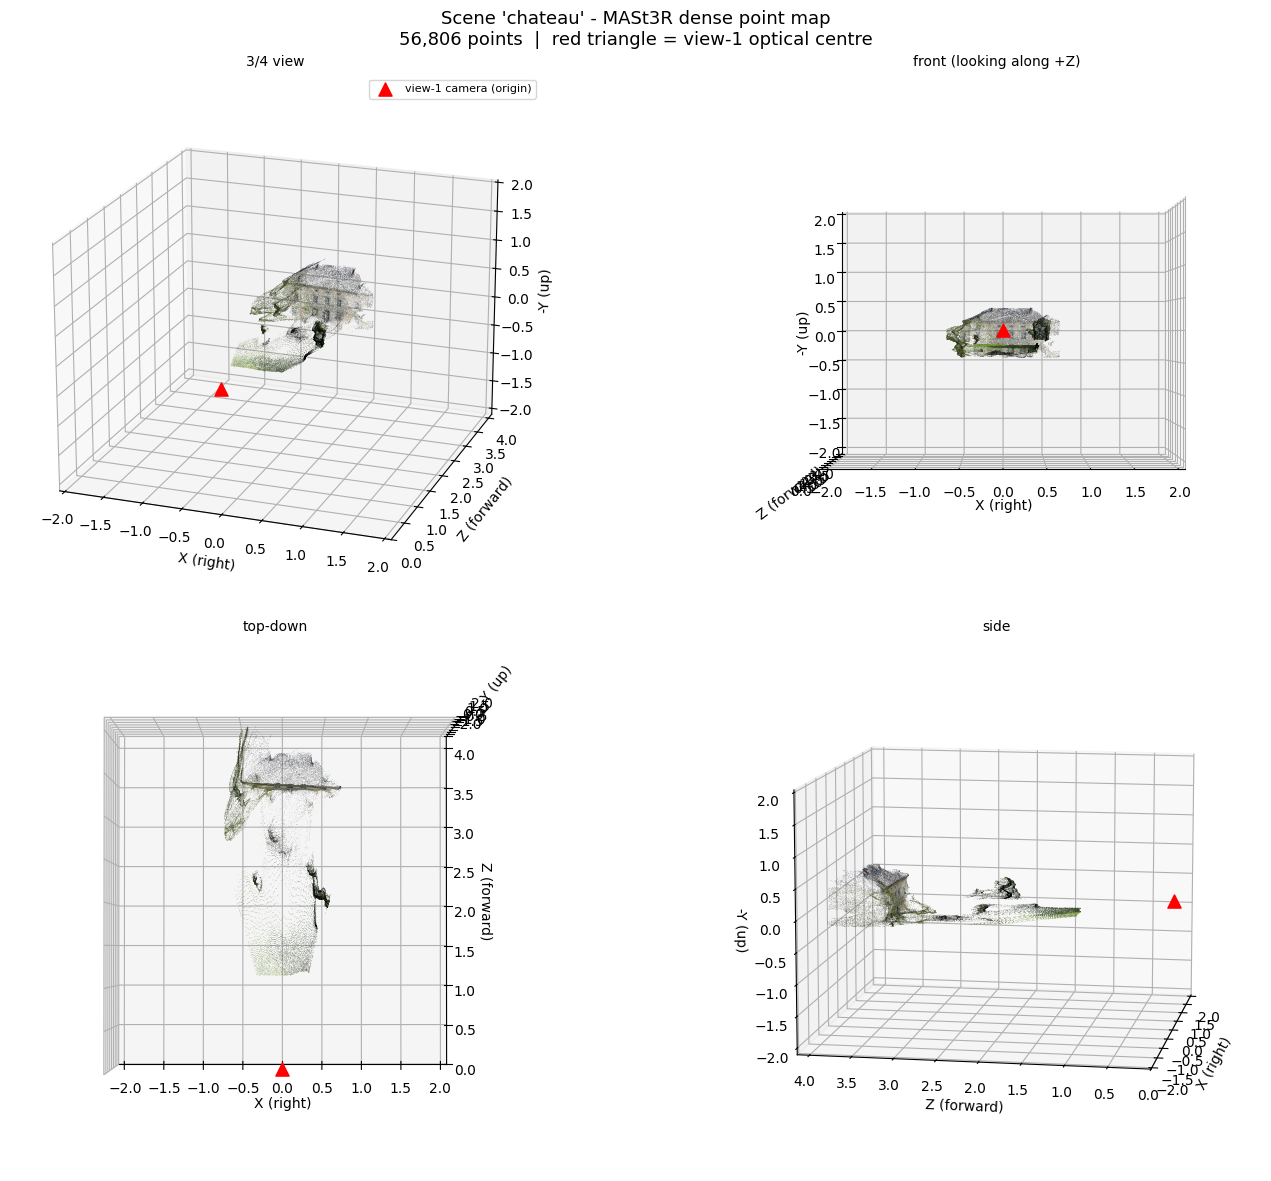

exported -> /kaggle/working/mast3r_metric_distance/results/pointclouds/phase3_chateau.ply  (0.9 MB)


In [28]:

RESULTS_3D = RESULTS_DIR / "pointclouds"; RESULTS_3D.mkdir(parents=True, exist_ok=True)

def build_cloud(pm, mask1, mask2, max_points=60000, seed=0):
    """Flatten both masked point maps into one (P,3) cloud with colours + origin labels."""
    p1, c1 = pm["pts1"][mask1], pm["col1"][mask1]
    p2, c2 = pm["pts2"][mask2], pm["col2"][mask2]
    pts = np.concatenate([p1, p2], axis=0)
    col = np.concatenate([c1, c2], axis=0)
    src = np.concatenate([np.zeros(len(p1), np.int8), np.ones(len(p2), np.int8)])

    if len(pts) > max_points:      # subsample only for RENDERING speed
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(pts), max_points, replace=False)
        pts, col, src = pts[idx], col[idx], src[idx]
    return pts, col, src


def show_pointcloud(pts, col, src, title="MASt3R reconstruction", save_as=None):
    """Required evaluation output #2 - the 3D point-map visualisation."""
    # Percentile limits: a few far outliers would otherwise zoom the camera out
    # until the actual scene is an invisible speck.
    lim = np.percentile(pts, [1, 99], axis=0)
    keep = np.all((pts >= lim[0]) & (pts <= lim[1]), axis=1)
    P, C, S = pts[keep], col[keep], src[keep]

    views = [(20, -70, "3/4 view"), (0, -90, "front (looking along +Z)"),
             (89, -90, "top-down"), (10, -170, "side")]
    fig = plt.figure(figsize=(16, 12))
    for i, (elev, azim, name) in enumerate(views, start=1):
        ax = fig.add_subplot(2, 2, i, projection="3d")
        # NOTE: vertical axis is -Y because MASt3R's +Y points DOWN.
        ax.scatter(P[:, 0], P[:, 2], -P[:, 1], c=C, s=0.35, marker=".",
                   linewidths=0, alpha=0.75)
        ax.scatter([0], [0], [0], c="red", s=90, marker="^",
                   label="view-1 camera (origin)")
        ax.set_xlabel("X (right)"); ax.set_ylabel("Z (forward)"); ax.set_zlabel("-Y (up)")
        ax.view_init(elev=elev, azim=azim)
        ax.set_title(name, fontsize=10)
        if i == 1:
            ax.legend(loc="upper right", fontsize=8)
        # equal aspect: never let matplotlib stretch geometry to fill the box.
        # The camera at the origin is included in the extent so it is always in
        # frame - its position RELATIVE to the scene is the point of the plot.
        # np.ptp(...) not arr.ptp(): the ndarray method was REMOVED in NumPy 2.0
        ax_pts = np.stack([P[:, 0], P[:, 2], -P[:, 1]], axis=1)
        ax_pts = np.vstack([ax_pts, np.zeros((1, 3))])          # + the origin
        lo3, hi3 = ax_pts.min(axis=0), ax_pts.max(axis=0)
        ctr = (lo3 + hi3) / 2
        r = float(np.max(hi3 - lo3)) / 2 or 1.0
        ax.set_xlim(ctr[0]-r, ctr[0]+r); ax.set_ylim(ctr[1]-r, ctr[1]+r)
        ax.set_zlim(ctr[2]-r, ctr[2]+r)
    fig.suptitle(f"{title}\n{len(P):,} points  |  red triangle = view-1 optical centre",
                 fontsize=13)
    fig.tight_layout()
    if save_as:
        fig.savefig(save_as, dpi=110, bbox_inches="tight"); print(f"saved -> {save_as}")
    plt.show()


pts_all, col_all, src_all = build_cloud(pm, mask1, mask2)
print(f"cloud: {len(pts_all):,} points "
      f"({(src_all==0).sum():,} from view 1, {(src_all==1).sum():,} from view 2)")
show_pointcloud(pts_all, col_all, src_all,
                title="Scene 'chateau' - MASt3R dense point map",
                save_as=FIGURES_DIR / "phase3_pointcloud_chateau.png")

# Export for inspection in a real 3D viewer (MeshLab, Blender, or Kaggle's file browser).
import trimesh
cloud = trimesh.PointCloud(vertices=pts_all,
                           colors=(np.clip(col_all, 0, 1) * 255).astype(np.uint8))
ply_path = RESULTS_3D / "phase3_chateau.ply"
cloud.export(ply_path)
print(f"exported -> {ply_path}  ({ply_path.stat().st_size/1024**2:.1f} MB)")

### 3.5 - Is the geometry actually plausible? (quantitative)

"Looks about right" is not a check. Four tests that can genuinely fail:

1. **Cheirality.** Visible surfaces must lie *in front* of the camera, so confident points need
   `Z > 0`. A large negative-`Z` population would mean the reconstruction is inside-out.
2. **Cloud overlap.** Both maps are in one frame and the views overlap, so the two clouds must
   occupy overlapping volume. We measure the Intersection-over-Union of their bounding boxes.
   Near-zero IoU falsifies the shared-frame property that the whole project rests on.
3. **Implied focal length.** A point map has intrinsics baked in, so we can invert
   `u = f * X/Z` to recover the focal MASt3R assumed, using the repo's own
   `estimate_focal_knowing_depth`. For ordinary cameras this should land within roughly
   0.5-2.5 x the image width. A wild value means the geometry is internally inconsistent.
4. **Depth spread.** A degenerate collapse to near-constant depth would indicate the model
   failed to find real structure.

In [29]:

from dust3r.post_process import estimate_focal_knowing_depth

def geometry_report(pm, mask1, mask2, output):
    checks = []
    def chk(label, ok, detail=""):
        checks.append(ok)
        print(f"  [{'PASS' if ok else 'FAIL'}] {label}" + (f"\n         {detail}" if detail else ""))

    # --- 1. cheirality -----------------------------------------------------
    print("--- 1. cheirality: confident points must be in FRONT of view-1's camera ---")
    for nm, pts, m in (("view1", pm["pts1"], mask1), ("view2", pm["pts2"], mask2)):
        Z = pts[..., 2][m]
        frac = float((Z > 0).mean())
        chk(f"{nm}: >95% of confident points have Z > 0",
            frac > 0.95, f"fraction Z>0 = {frac:.4f}, median Z = {np.median(Z):.3f}")

    # --- 2. do the two clouds occupy the same volume? ----------------------
    print("\n--- 2. shared-frame check: the two clouds must OVERLAP in space ---")
    p1, p2 = pm["pts1"][mask1], pm["pts2"][mask2]
    lo1, hi1 = np.percentile(p1, [5, 95], axis=0)   # robust boxes, ignore outliers
    lo2, hi2 = np.percentile(p2, [5, 95], axis=0)
    inter = np.maximum(0, np.minimum(hi1, hi2) - np.maximum(lo1, lo2)).prod()
    union = (hi1-lo1).prod() + (hi2-lo2).prod() - inter
    iou = float(inter / union) if union > 0 else 0.0
    print(f"    view1 box (5-95pct): {np.round(lo1,2)} .. {np.round(hi1,2)}")
    print(f"    view2 box (5-95pct): {np.round(lo2,2)} .. {np.round(hi2,2)}")
    chk("bounding-box IoU > 0.1 (clouds share one frame)", iou > 0.10,
        f"IoU = {iou:.3f}; centroid gap = "
        f"{np.linalg.norm(p1.mean(0)-p2.mean(0)):.3f} vs scene size "
        f"{np.linalg.norm(hi1-lo1):.3f}")

    # --- 3. implied focal length ------------------------------------------
    print("\n--- 3. focal length implied by the point map (intrinsics are baked in) ---")
    pts1_t = output["pred1"]["pts3d"]                       # [1,H,W,3] torch
    Himg, Wimg = pts1_t.shape[1:3]
    pp = torch.tensor([Wimg / 2, Himg / 2]).float()[None]   # principal point = image centre
    focal = float(estimate_focal_knowing_depth(pts1_t.float(), pp, focal_mode="median")[0])
    fov = 2 * np.degrees(np.arctan(Wimg / (2 * focal)))
    chk("implied focal is plausible (0.5-2.5 x image width)",
        0.5 * Wimg < focal < 2.5 * Wimg,
        f"focal = {focal:.1f} px on a {Wimg}px-wide image "
        f"({focal/Wimg:.2f} x width)  ->  horizontal FOV = {fov:.1f} deg")

    # --- 4. depth spread ---------------------------------------------------
    print("\n--- 4. depth structure (a collapse to constant depth = failure) ---")
    Z = pm["pts1"][..., 2][mask1]
    p5, p95 = np.percentile(Z, [5, 95])
    chk("depth varies across the scene", (p95 - p5) > 0.05 * abs(np.median(Z)),
        f"Z 5-95 pct spread = {p95-p5:.3f} around median {np.median(Z):.3f}")

    print(f"\n  {sum(checks)}/{len(checks)} geometry checks passed")
    return {"focal_px": focal, "fov_deg": fov, "bbox_iou": iou,
            "all_passed": all(checks)}


geom = geometry_report(pm, mask1, mask2, output)

--- 1. cheirality: confident points must be in FRONT of view-1's camera ---
  [PASS] view1: >95% of confident points have Z > 0
         fraction Z>0 = 1.0000, median Z = 2.791
  [PASS] view2: >95% of confident points have Z > 0
         fraction Z>0 = 1.0000, median Z = 3.420

--- 2. shared-frame check: the two clouds must OVERLAP in space ---
    view1 box (5-95pct): [-0.36 -0.25  1.22] .. [0.51 0.39 3.62]
    view2 box (5-95pct): [-0.63 -0.31  2.83] .. [0.58 0.41 3.94]
  [PASS] bounding-box IoU > 0.1 (clouds share one frame)
         IoU = 0.235; centroid gap = 0.782 vs scene size 2.635

--- 3. focal length implied by the point map (intrinsics are baked in) ---
  [PASS] implied focal is plausible (0.5-2.5 x image width)
         focal = 929.6 px on a 512px-wide image (1.82 x width)  ->  horizontal FOV = 30.8 deg

--- 4. depth structure (a collapse to constant depth = failure) ---
  [PASS] depth varies across the scene
         Z 5-95 pct spread = 2.404 around median 2.791

  5/5 geo

### 3.6 - Optional: interactive 3D

Static views are enough to catch gross failures, but rotating the cloud yourself is the fastest
way to judge whether a *surface* is genuinely there. Plotly ships with the Kaggle image; this
cell is guarded so the phase does not depend on it.

In [32]:

# Interactive 3D often does NOT render in a remote/VS Code notebook session.
# So rather than relying on fig.show(), we always write a self-contained HTML
# file you can download and open in a browser. The .ply from 3.4 remains the
# better route for serious inspection (MeshLab / Blender / CloudCompare).
try:
    import plotly.graph_objects as go

    n_show = min(25000, len(pts_all))          # keep the browser responsive
    idx = np.random.default_rng(0).choice(len(pts_all), n_show, replace=False)
    P, C = pts_all[idx], col_all[idx]
    colors = [f"rgb({int(r*255)},{int(g*255)},{int(b*255)})" for r, g, b in np.clip(C, 0, 1)]

    fig = go.Figure(data=[
        # again: vertical axis is -Y, since MASt3R's +Y points down
        go.Scatter3d(x=P[:, 0], y=P[:, 2], z=-P[:, 1], mode="markers",
                     marker=dict(size=1.4, color=colors, opacity=0.8), name="scene"),
        go.Scatter3d(x=[0], y=[0], z=[0], mode="markers",
                     marker=dict(size=6, color="red", symbol="diamond"),
                     name="view-1 camera"),
    ])
    fig.update_layout(
        title=f"MASt3R point cloud - {n_show:,} points (drag to rotate)",
        scene=dict(xaxis_title="X (right)", yaxis_title="Z (forward)",
                   zaxis_title="-Y (up)", aspectmode="data"),
        height=680, margin=dict(l=0, r=0, t=40, b=0))

    html_path = RESULTS_3D / "phase3_chateau_interactive.html"
    fig.write_html(html_path, include_plotlyjs="cdn")
    print(f"wrote -> {html_path}  ({html_path.stat().st_size/1024:.0f} KB)")
    print("Download and open it in a browser if it does not render inline below.")
    fig.show()
except ImportError:
    print("plotly not installed - use the .ply export from 3.4 instead.")
except Exception as e:
    print(f"interactive view unavailable ({type(e).__name__}: {e})")
    print("Not a problem: the static views in 3.4 and the .ply export cover this phase.")

wrote -> /kaggle/working/mast3r_metric_distance/results/pointclouds/phase3_chateau_interactive.html  (1219 KB)
Download and open it in a browser if it does not render inline below.


### Phase 3 summary

**What was established.**

- Dense point maps extract cleanly to `[H,W,3]`, pixel-aligned with confidence and colour, so
  "the 3D point at pixel `(x,y)`" is a well-defined lookup - the operation Phase 5 depends on.
- Viewed as depth images the `Z` channels show real scene structure, not noise.
- **Question 10 answered:** low-confidence points *should* be discarded, but only by
  **percentile**, because `conf = 1 + exp(x)` is unbounded and uncalibrated so no fixed
  constant transfers between scenes. For measurement (as opposed to visualisation), refusing to
  answer is better than returning a number the model itself distrusts.
- The shared-frame property is now checked *quantitatively* via bounding-box IoU, not just
  inferred from a variable name.
- The implied focal length is recovered from the point map alone - a concrete demonstration
  that intrinsics are baked into the representation, which is exactly why no calibration step
  is needed.

**What is still NOT established.** Everything about *correctness of scale*. A geometrically
self-consistent, plausibly-shaped, correctly-oriented reconstruction can still be uniformly
wrong in size, and none of the checks above would notice - they are all scale-invariant except
the focal estimate, which is itself derived from the same point map. Only Phase 6, against
measured ground truth, can settle it.

**Assumptions added to the record (question 13).**

5. The confidence percentile used for filtering is a *choice*, not a property of the scene.
   Phase 8 experiment E measures its effect rather than defending this default.
6. Bounding-box IoU is a coarse proxy for "the clouds agree". Two clouds can share a bounding
   box while disagreeing point-by-point. The strict test - do corresponding points land in the
   same place? - needs correspondences, and arrives in Phase 4.

---

### Next

Phase 3 stops here. Once you have run these cells and reported the output - especially the
**3.5 geometry report** and whether the point cloud looks like the actual scene - I will write
**Phase 4 - correspondence matching**: using `fast_reciprocal_NNs` on the dense descriptors to
establish pixel-to-pixel matches, visualising them, and then running the strict cross-view
consistency test that assumption 6 above is waiting on.

---

## PHASE 4 - CORRESPONDENCE MATCHING

### Objective

**Simple explanation.** Given the same physical point photographed twice, find *which pixel in
image 1 and which pixel in image 2 show it*. MASt3R gives every pixel a 24-number "fingerprint";
matching means finding fingerprint pairs that agree.

**Technical explanation.** We take the dense descriptor fields `pred1['desc']` and
`pred2['desc']` (`[H,W,24]`, L2-normalised) and run the repository's own
`fast_reciprocal_NNs` to obtain mutual nearest-neighbour pixel correspondences, then filter and
visualise them.

### Why this phase exists at all

This is the step that makes MASt3R - rather than DUSt3R - the right tool. DUSt3R gives geometry
but no way to say "this pixel and that pixel are the same thing". Without correspondences you
could only measure between two points in *one* image; with them you can anchor a measurement
across both views and verify it.

### What MASt3R is doing internally at this stage

Also nothing - the descriptors were produced back in Phase 2's single forward pass. What runs
here is a *search*, and understanding it matters because its parameters shape the results:

**Reciprocal (mutual) nearest neighbours.** Pixel `p` in image 1 matches pixel `q` in image 2
only if `q` is `p`'s nearest descriptor **and** `p` is `q`'s nearest descriptor. One-directional
NN always returns *something* for every pixel, including for content that is occluded or simply
absent from the other view. Requiring reciprocity is what lets a pixel report "no match".

**The iterative trick.** `fast_reciprocal_NNs` does not compare all `H*W` against all `H*W`
(196k x 196k). It seeds from a subsampled grid (`subsample_or_initxy1=8`, i.e. every 8th pixel)
and then *alternates*: map 1->2, map 2->1, repeat until the pair stops moving. Converged
round-trips are kept. This is why it is "fast".

**`dist='dot'`.** Descriptors are L2-normalised (verified in Phase 2), so a dot product *is*
cosine similarity, and maximising it is equivalent to minimising Euclidean distance. No extra
normalisation is needed.

### Sanity checks this phase must pass

1. A substantial number of reciprocal matches is found.
2. Every match index lies inside the image bounds.
3. Matches are unique - `merge_corres` deduplicates, so no pixel should appear twice.
4. Matched descriptors have genuinely high cosine similarity.
5. **The strict 3D consistency test** promised at the end of Phase 3 - see 4.5. This is the one
   that actually matters.

### 4.1 - Extract descriptors and run the official matcher

We use `fast_reciprocal_NNs` exactly as the README's own matching example does, including
`dist='dot'` and `block_size=2**13`. `block_size` only chunks the similarity computation to
bound peak memory; it does not change results.

A note on `subsample_or_initxy1=8`: this is the **seed** grid, not a cap on output. The
iteration migrates seeds toward their reciprocal partners, so matches do not stay locked to a
regular lattice. Passing explicit `(x, y)` arrays instead of an integer lets you demand matches
at *chosen* pixels - which is precisely what Phase 5 will need for measuring between two
specific points.

In [33]:

from mast3r.fast_nn import fast_reciprocal_NNs

def extract_descriptors(output):
    """Dense descriptors + their confidences, as [H,W,24] / [H,W] tensors."""
    d1 = output["pred1"]["desc"].squeeze(0).detach()
    d2 = output["pred2"]["desc"].squeeze(0).detach()
    dc1 = output["pred1"]["desc_conf"].squeeze(0).detach()
    dc2 = output["pred2"]["desc_conf"].squeeze(0).detach()
    return d1, d2, dc1, dc2


def find_correspondences(desc1, desc2, device=DEVICE, subsample=8):
    """Reciprocal-NN pixel correspondences via the repo's own matcher.

    Returns (matches_im0, matches_im1), each an int array of shape (N, 2)
    holding **(x, y)** pixel coordinates - column 0 is x, column 1 is y.
    (Confirmed from mast3r/fast_nn.py::merge_corres, which reverses the
    unravel_index output with [:, ::-1] when ret_xy=True.)
    """
    m0, m1 = fast_reciprocal_NNs(desc1, desc2,
                                 subsample_or_initxy1=subsample,
                                 device=device, dist="dot", block_size=2**13)
    return m0, m1


desc1, desc2, dconf1, dconf2 = extract_descriptors(output)
print(f"descriptors: desc1 {tuple(desc1.shape)}  desc2 {tuple(desc2.shape)}  dtype {desc1.dtype}")

t0 = time.time()
matches_im0, matches_im1 = find_correspondences(desc1, desc2)
print(f"matching took {time.time()-t0:.2f} s")
print(f"\n  raw reciprocal matches: {len(matches_im0):,}")
print(f"  matches_im0 shape {matches_im0.shape}, dtype {matches_im0.dtype}")
print(f"  first 5 (x, y) in image 1: {matches_im0[:5].tolist()}")
print(f"  first 5 (x, y) in image 2: {matches_im1[:5].tolist()}")

# A dense 8-px seed grid over 384x512 is (384/8)*(512/8) = 3072 seeds; the
# iteration can only return at most one match per seed.
print(f"\n  seed grid was {(H_//8)}x{(W_//8)} = {(H_//8)*(W_//8):,} seeds")
print(f"  -> {100*len(matches_im0)/((H_//8)*(W_//8)):.1f}% of seeds converged to a mutual NN")

descriptors: desc1 (384, 512, 24)  desc2 (384, 512, 24)  dtype torch.float32
matching took 0.32 s

  raw reciprocal matches: 1,048
  matches_im0 shape (1048, 2), dtype int64
  first 5 (x, y) in image 1: [[511, 0], [77, 53], [76, 60], [77, 60], [73, 63]]
  first 5 (x, y) in image 2: [[0, 0], [7, 24], [4, 37], [5, 38], [5, 39]]

  seed grid was 48x64 = 3,072 seeds
  -> 34.1% of seeds converged to a mutual NN


### 4.2 - Border filtering and validity checks

The README's own example discards matches within 3 px of any edge. The reason is real: the DPT
head upsamples from a patch grid, so the outermost pixels are reconstructed from one-sided
context and are systematically less reliable. We follow that recipe rather than invent our own
margin.

In [34]:

def filter_border(m0, m1, shape0, shape1, margin=3):
    """Drop matches within `margin` px of any image edge (the README's recipe)."""
    H0, W0 = int(shape0[0]), int(shape0[1])
    H1, W1 = int(shape1[0]), int(shape1[1])
    ok0 = ((m0[:, 0] >= margin) & (m0[:, 0] < W0 - margin) &
           (m0[:, 1] >= margin) & (m0[:, 1] < H0 - margin))
    ok1 = ((m1[:, 0] >= margin) & (m1[:, 0] < W1 - margin) &
           (m1[:, 1] >= margin) & (m1[:, 1] < H1 - margin))
    keep = ok0 & ok1
    return m0[keep], m1[keep], keep


shape0 = output["view1"]["true_shape"][0]
shape1 = output["view2"]["true_shape"][0]
print(f"true shapes: view1 {tuple(np.asarray(shape0))}  view2 {tuple(np.asarray(shape1))}")

n_before = len(matches_im0)
matches_im0, matches_im1, _ = filter_border(matches_im0, matches_im1, shape0, shape1)
print(f"border filter (3 px): {n_before:,} -> {len(matches_im0):,} "
      f"({n_before - len(matches_im0)} dropped)")

print("\n--- validity checks ---")
def chk(label, ok, detail=""):
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}" + (f"   {detail}" if detail else ""))

chk("found a usable number of matches", len(matches_im0) > 100, f"{len(matches_im0):,} matches")
chk("image-1 coords inside bounds",
    bool((matches_im0[:, 0] < W_).all() and (matches_im0[:, 1] < H_).all()),
    f"x in [{matches_im0[:,0].min()}, {matches_im0[:,0].max()}], "
    f"y in [{matches_im0[:,1].min()}, {matches_im0[:,1].max()}]")
chk("image-2 coords inside bounds",
    bool((matches_im1[:, 0] < W_).all() and (matches_im1[:, 1] < H_).all()))

# merge_corres deduplicates; verify that rather than trusting the docstring.
uniq0 = len(np.unique(matches_im0, axis=0))
chk("image-1 match points are unique", uniq0 == len(matches_im0),
    f"{uniq0:,} unique / {len(matches_im0):,}")

# --- how similar ARE matched descriptors? -------------------------------
d1n = to_numpy(desc1); d2n = to_numpy(desc2)
v0 = d1n[matches_im0[:, 1], matches_im0[:, 0]]      # NOTE: [y, x] indexing
v1 = d2n[matches_im1[:, 1], matches_im1[:, 0]]
cos_sim = (v0 * v1).sum(-1)                         # unit vectors -> dot == cosine
print(f"\n  matched-descriptor cosine similarity:")
print(f"    min {cos_sim.min():.4f} | median {np.median(cos_sim):.4f} | max {cos_sim.max():.4f}")
chk("matched descriptors are genuinely similar", float(np.median(cos_sim)) > 0.5,
    "median cosine similarity well above 0 (chance level)")

# Pixel displacement tells us how much the viewpoint actually moved.
disp = np.linalg.norm(matches_im1.astype(np.float64) - matches_im0, axis=1)
print(f"\n  pixel displacement between views: median {np.median(disp):.1f} px, "
      f"90th pct {np.percentile(disp, 90):.1f} px, max {disp.max():.1f} px")

true shapes: view1 (np.int32(384), np.int32(512))  view2 (np.int32(384), np.int32(512))
border filter (3 px): 1,048 -> 1,009 (39 dropped)

--- validity checks ---
  [PASS] found a usable number of matches   1,009 matches
  [PASS] image-1 coords inside bounds   x in [73, 479], y in [53, 324]
  [PASS] image-2 coords inside bounds
  [PASS] image-1 match points are unique   1,009 unique / 1,009

  matched-descriptor cosine similarity:
    min 0.6462 | median 0.9679 | max 0.9956
  [PASS] matched descriptors are genuinely similar   median cosine similarity well above 0 (chance level)

  pixel displacement between views: median 56.6 px, 90th pct 79.9 px, max 338.4 px


### 4.3 - Required output #3: correspondence visualisation

Drawing all matches produces an unreadable mat of lines, so we sample evenly across the match
list (which `merge_corres` sorted by position, giving good spatial spread) and colour each line
by its index so a pair can be traced across the two panels.

**What to look for.** Correct matches produce a *coherent flow field* - nearby points move in
similar directions. Lines crossing wildly in a rigid scene indicate mismatches.

saved -> /kaggle/working/mast3r_metric_distance/results/figures/phase4_matches_chateau.png


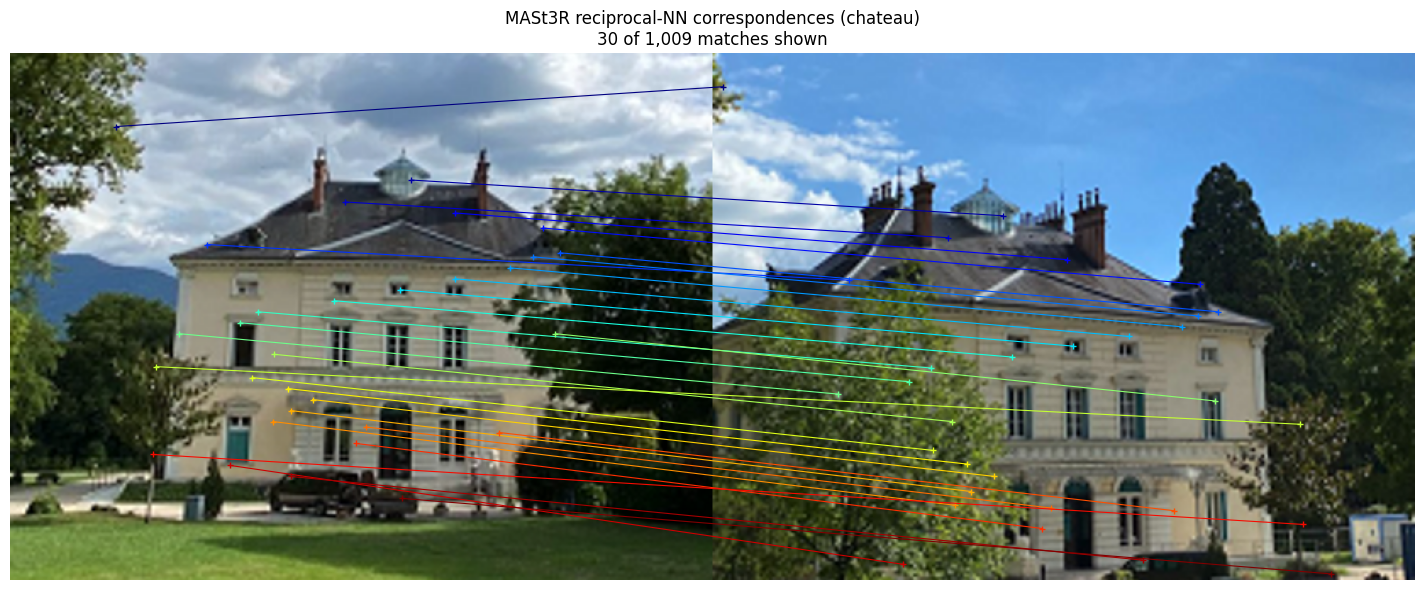

saved -> /kaggle/working/mast3r_metric_distance/results/figures/phase4_coverage_chateau.png


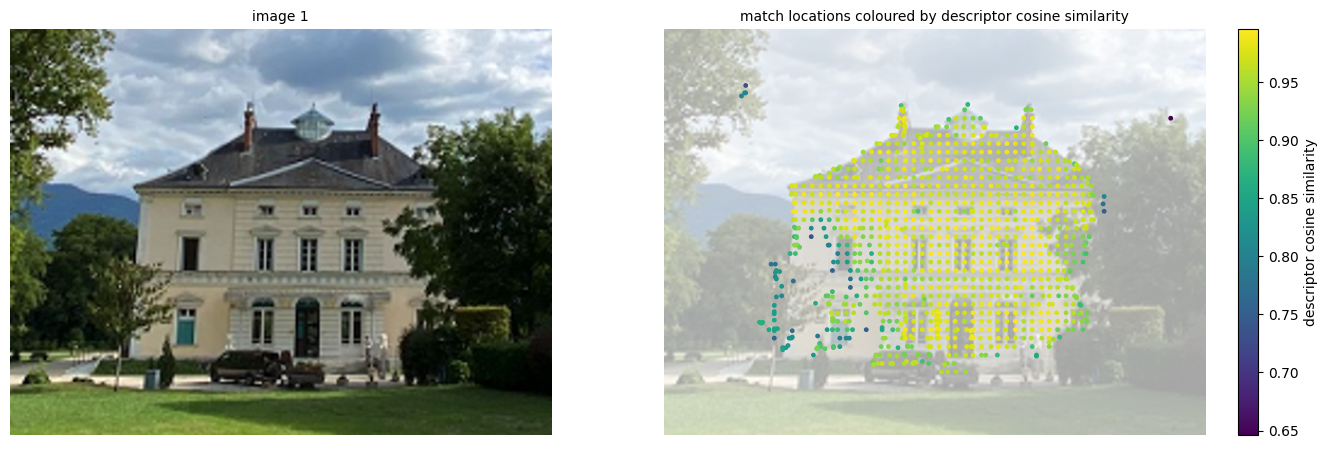

In [35]:

def visualize_matches(view1, view2, m0, m1, n_viz=30, title="correspondences", save_as=None):
    """Required evaluation output #3 - draw matched pixel pairs across both images."""
    img0 = rgb(view1["img"][0]); img1 = rgb(view2["img"][0])
    H0, W0 = img0.shape[:2]; H1, W1 = img1.shape[:2]

    # pad to equal height, then place side by side
    Hc = max(H0, H1)
    canvas = np.ones((Hc, W0 + W1, 3), dtype=np.float32)
    canvas[:H0, :W0] = img0
    canvas[:H1, W0:W0 + W1] = img1

    n = min(n_viz, len(m0))
    idx = np.round(np.linspace(0, len(m0) - 1, n)).astype(int)
    cmap = plt.get_cmap("jet")

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.imshow(canvas)
    for k, i in enumerate(idx):
        x0, y0 = m0[i]; x1, y1 = m1[i]
        c = cmap(k / max(n - 1, 1))
        ax.plot([x0, x1 + W0], [y0, y1], "-+", color=c, lw=0.8,
                markersize=5, scalex=False, scaley=False)
    ax.axis("off")
    ax.set_title(f"{title}\n{n} of {len(m0):,} matches shown", fontsize=12)
    fig.tight_layout()
    if save_as:
        fig.savefig(save_as, dpi=120, bbox_inches="tight"); print(f"saved -> {save_as}")
    plt.show()


visualize_matches(output["view1"], output["view2"], matches_im0, matches_im1,
                  n_viz=30, title="MASt3R reciprocal-NN correspondences (chateau)",
                  save_as=FIGURES_DIR / "phase4_matches_chateau.png")


def show_match_coverage(view1, m0, values, label, save_as=None):
    """Where do matches land, and how does `values` vary spatially?"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
    axes[0].imshow(rgb(view1["img"][0])); axes[0].set_title("image 1", fontsize=10)
    axes[1].imshow(rgb(view1["img"][0]), alpha=0.35)
    sc = axes[1].scatter(m0[:, 0], m0[:, 1], c=values, s=6, cmap="viridis")
    fig.colorbar(sc, ax=axes[1], fraction=0.046, label=label)
    axes[1].set_title(f"match locations coloured by {label}", fontsize=10)
    for ax in axes: ax.axis("off")
    fig.tight_layout()
    if save_as:
        fig.savefig(save_as, dpi=110, bbox_inches="tight"); print(f"saved -> {save_as}")
    plt.show()


show_match_coverage(output["view1"], matches_im0, cos_sim, "descriptor cosine similarity",
                    save_as=FIGURES_DIR / "phase4_coverage_chateau.png")

### 4.4 - `filter_matches`: quality ranking

`desc_conf` is the head trained specifically to predict *matchability* (recall `two_confs=True`
gives it a separate output from geometric `conf`). For a match we need both endpoints to be
trustworthy, so we score each correspondence by the **minimum** of its two descriptor
confidences - a match is only as good as its weaker end.

As in Phase 3, thresholds are **percentiles**, because `desc_conf = exp(x)` is unbounded and
uncalibrated.

In [36]:

def filter_matches(m0, m1, dconf1, dconf2, percentile=0.0, extra_mask=None):
    """Rank/filter correspondences by min(desc_conf at both endpoints).

    Returns (m0_kept, m1_kept, score_kept). percentile=0 keeps everything but
    still returns the scores, so nothing is discarded before it is inspected.
    """
    dc1 = to_numpy(dconf1); dc2 = to_numpy(dconf2)
    s0 = dc1[m0[:, 1], m0[:, 0]]        # [y, x] indexing
    s1 = dc2[m1[:, 1], m1[:, 0]]
    score = np.minimum(s0, s1)          # a match is as strong as its weaker end

    keep = np.ones(len(score), dtype=bool)
    if percentile > 0:
        keep &= score >= np.percentile(score, percentile)
    if extra_mask is not None:
        keep &= extra_mask
    return m0[keep], m1[keep], score[keep], keep


_, _, match_score, _ = filter_matches(matches_im0, matches_im1, dconf1, dconf2)
print("match score = min(desc_conf at the two endpoints)")
print(f"  min {match_score.min():.3f} | median {np.median(match_score):.3f} "
      f"| max {match_score.max():.3f}")
print(f"\n  {'percentile':>10} {'score thr':>10} {'kept':>8}")
for p in (0, 25, 50, 75, 90):
    thr = np.percentile(match_score, p) if p else match_score.min()
    print(f"  {p:>10.0f} {thr:>10.3f} {int((match_score >= thr).sum()):>8,}")

match score = min(desc_conf at the two endpoints)
  min 0.120 | median 1.892 | max 5.550

  percentile  score thr     kept
           0      0.120    1,009
          25      1.197      757
          50      1.892      505
          75      2.685      253
          90      3.380      101


### 4.5 - The strict 3D consistency test

This settles assumption 6 left open at the end of Phase 3, and it is the most important result
of this phase.

**The argument.** Take a correspondence: pixel `(x0,y0)` in image 1 and pixel `(x1,y1)` in
image 2 show *the same physical point*. Phase 2 established that both point maps are expressed
in **view 1's camera frame**. Therefore

```
pts1[y0, x0]   and   pts2[y1, x1]
```

are two independent predictions of **the same 3D location in the same coordinate system**. They
should be identical. They will not be, and the size of the gap is a direct, physical measurement
of the model's internal inconsistency - in whatever units the output carries.

**Why this matters more than anything else so far.** In Phase 5 we compute
`D = ||P_a - P_b||`. If the model disagrees with *itself* about where a single point is by
`e` metres, then a distance built from such points inherits an error floor of roughly that
size. This cell measures that floor **before** we start quoting distances - and it needs no
ground truth whatsoever.

It also gives an early, honest read on **secondary question D** (does descriptor confidence
correlate with accuracy?), by correlating the residual against the match score from 4.4.

CROSS-VIEW 3D CONSISTENCY  (the error floor for every later distance)
  matches evaluated     : 1,009
  median scene distance : 2.819  (units as output by the model)

  residual ||P_view1 - P_view2||:
     10th pct :   0.0079   (  0.28% of scene distance)
     25th pct :   0.0123   (  0.44% of scene distance)
     50th pct :   0.0224   (  0.80% of scene distance)
     75th pct :   0.0927   (  3.29% of scene distance)
     90th pct :   0.6392   ( 22.68% of scene distance)
     99th pct :   1.0983   ( 38.97% of scene distance)
    mean     :   0.1589
    max      :   4.8195

  >> A distance measured between two such points inherits an error floor of
     roughly the median residual, 0.0224, i.e. about 0.8% of scene scale.
     This is a LOWER bound on achievable accuracy - real error will exceed it.

DOES DESCRIPTOR CONFIDENCE PREDICT 3D CONSISTENCY?  (secondary question D)
  Spearman rho(match score, residual) = -0.329   (p = 5.84e-27)
  >> Confidence carries real signal: filtering on i

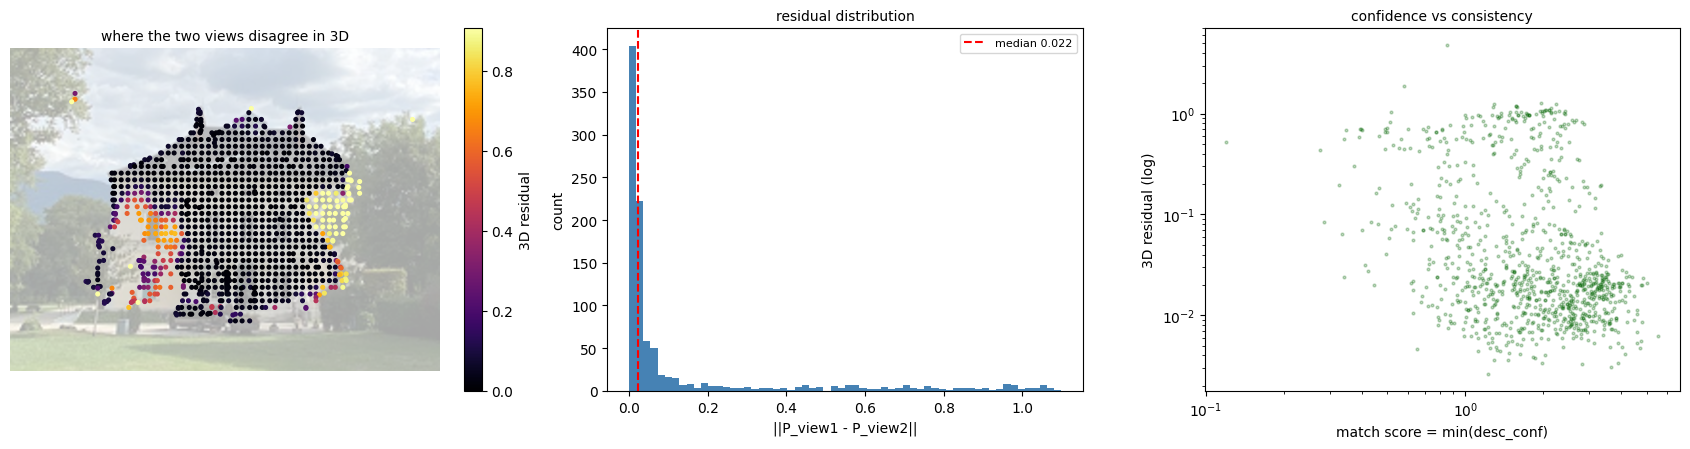

In [37]:

def cross_view_residuals(pm, m0, m1):
    """||pts1[y0,x0] - pts2[y1,x1]|| for each correspondence.

    Both maps are in view 1's frame and each match names one physical point,
    so this residual is pure model self-inconsistency - NOT a scene property.
    """
    P0 = pm["pts1"][m0[:, 1], m0[:, 0]]      # [N,3]  from view 1's map
    P1 = pm["pts2"][m1[:, 1], m1[:, 0]]      # [N,3]  from view 2's map, same frame
    return np.linalg.norm(P0 - P1, axis=-1), P0, P1


resid, P0, P1 = cross_view_residuals(pm, matches_im0, matches_im1)

# Scene scale, so the residual can be read as a fraction of what we are measuring.
scene_depth = float(np.median(np.linalg.norm(pm["pts1"][mask1], axis=-1)))

print("="*88)
print("CROSS-VIEW 3D CONSISTENCY  (the error floor for every later distance)")
print("="*88)
print(f"  matches evaluated     : {len(resid):,}")
print(f"  median scene distance : {scene_depth:.3f}  (units as output by the model)")
print(f"\n  residual ||P_view1 - P_view2||:")
for p in (10, 25, 50, 75, 90, 99):
    v = float(np.percentile(resid, p))
    print(f"    {p:>3d}th pct : {v:8.4f}   ({100*v/scene_depth:6.2f}% of scene distance)")
print(f"    mean     : {resid.mean():8.4f}")
print(f"    max      : {resid.max():8.4f}")

print(f"\n  >> A distance measured between two such points inherits an error floor of")
print(f"     roughly the median residual, {np.median(resid):.4f}, i.e. about "
      f"{100*np.median(resid)/scene_depth:.1f}% of scene scale.")
print("     This is a LOWER bound on achievable accuracy - real error will exceed it.")

# --- does confidence predict consistency? (secondary question D, early read) ---
from scipy.stats import spearmanr
rho, pval = spearmanr(match_score, resid)
print("\n" + "="*88)
print("DOES DESCRIPTOR CONFIDENCE PREDICT 3D CONSISTENCY?  (secondary question D)")
print("="*88)
# spearmanr returns nan when either input is constant (zero variance). Guard it
# explicitly: falling through to the "no correlation" branch on a nan would
# report a conclusion we never actually measured.
if not np.isfinite(rho):
    print(f"  Spearman rho = {rho} -- UNDEFINED.")
    print("  One of the two inputs has zero variance "
          f"(residual std {resid.std():.3e}, score std {match_score.std():.3e}),")
    print("  so no correlation can be computed. NOT a result of 'no relationship'.")
elif rho < -0.1:
    print(f"  Spearman rho(match score, residual) = {rho:+.3f}   (p = {pval:.2e})")
    print("  >> Confidence carries real signal: filtering on it should help.")
elif rho > 0.1:
    print(f"  Spearman rho(match score, residual) = {rho:+.3f}   (p = {pval:.2e})")
    print("  >> Unexpected POSITIVE correlation - confidence would be misleading here.")
    print("     Worth investigating before relying on it in Phase 8 experiment E.")
else:
    print(f"  Spearman rho(match score, residual) = {rho:+.3f}   (p = {pval:.2e})")
    print("  >> Essentially no correlation on this scene; confidence filtering may not")
    print("     help much here. Phase 8 experiment E will test this across scenes.")

# Concrete demonstration: does filtering actually reduce the residual?
print("\n  effect of confidence filtering on median residual:")
for p in (0, 25, 50, 75, 90):
    sel = match_score >= (np.percentile(match_score, p) if p else match_score.min())
    print(f"    keep top {100-p:>3.0f}% : n={sel.sum():>6,}  "
          f"median residual = {np.median(resid[sel]):.4f}  "
          f"({100*np.median(resid[sel])/scene_depth:.2f}% of scene)")


def show_residuals(view1, m0, resid, match_score, scene_depth, save_as=None):
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
    axes[0].imshow(rgb(view1["img"][0]), alpha=0.35)
    sc = axes[0].scatter(m0[:, 0], m0[:, 1], c=resid, s=7, cmap="inferno",
                         vmin=0, vmax=np.percentile(resid, 95))
    fig.colorbar(sc, ax=axes[0], fraction=0.046, label="3D residual")
    axes[0].set_title("where the two views disagree in 3D", fontsize=10); axes[0].axis("off")

    axes[1].hist(resid, bins=60, range=(0, np.percentile(resid, 99)), color="steelblue")
    axes[1].axvline(np.median(resid), color="red", ls="--",
                    label=f"median {np.median(resid):.3f}")
    axes[1].set_xlabel("||P_view1 - P_view2||"); axes[1].set_ylabel("count")
    axes[1].set_title("residual distribution", fontsize=10); axes[1].legend(fontsize=8)

    axes[2].scatter(match_score, resid, s=4, alpha=0.25, color="darkgreen")
    # log axes silently DROP non-positive values, which would hide exactly the
    # perfectly-consistent matches we most want to see. Only go log if it is safe.
    if (resid > 0).all() and (match_score > 0).all():
        axes[2].set_yscale("log"); axes[2].set_xscale("log")
        axes[2].set_ylabel("3D residual (log)")
    else:
        axes[2].set_ylabel("3D residual (linear: zeros present)")
    axes[2].set_xlabel("match score = min(desc_conf)")
    axes[2].set_title("confidence vs consistency", fontsize=10)
    fig.tight_layout()
    if save_as:
        fig.savefig(save_as, dpi=110, bbox_inches="tight"); print(f"saved -> {save_as}")
    plt.show()


show_residuals(output["view1"], matches_im0, resid, match_score, scene_depth,
               save_as=FIGURES_DIR / "phase4_residuals_chateau.png")

### Phase 4 summary

**What was established.**

- **Question 8 answered in practice:** correspondences come from the repository's own
  `fast_reciprocal_NNs` - iterative mutual nearest neighbours over L2-normalised 24-D
  descriptors, seeded on an 8-px grid, with `dist='dot'` (equivalent to cosine similarity). We
  did not invent a matcher.
- Match coordinates are **(x, y)**, and point maps index as **`[y, x]`**. Getting this backwards
  is silent and catastrophic, so both are asserted rather than assumed.
- Border filtering follows the README's 3-px margin, justified by the DPT head's one-sided
  context at image edges.
- `filter_matches` scores a correspondence by `min(desc_conf)` across its two endpoints - a
  match is only as reliable as its weaker end.
- **Assumption 6 from Phase 3 is now discharged.** The cross-view residual test compares two
  independent predictions of the same physical point in the same frame, giving a quantitative
  error floor for every distance we will quote in Phase 5 - derived with no ground truth at all.
- An early, honest read on **secondary question D**, via the Spearman correlation between match
  confidence and 3D residual.

**What is still NOT established.** Accuracy against the real world. The residual measures the
model's agreement *with itself*; a model can be perfectly self-consistent and uniformly wrong
in scale. That remains Phase 6's job.

**Assumptions added to the record (question 13).**

7. Matched pixels are treated as the *same physical point*. At 512x384 one pixel spans a real
   distance that grows with depth, so even a perfect match carries quantisation error - a
   second error floor, separate from the residual above.
8. Reciprocal NN assumes the point is *visible in both views*. Occluded points can still produce
   a confident-looking mutual match on a similar-looking neighbour. This is the mechanism behind
   the occlusion failure case in Phase 8.

---

### Next

Phase 4 stops here. Once you have run these cells and reported the output - especially the
**4.5 consistency test**, since its median residual sets the accuracy ceiling for everything
that follows - I will write **Phase 5 - distance estimation**: selecting specific corresponding
physical points, retrieving their 3D coordinates, and computing the Euclidean metric distance
between them.

**Preparation for Phases 5-6:** these need your own scenes with tape-measured ground truth, laid
out as `data/scene_01/{image1.jpg, image2.jpg, metadata.json}`. Worth capturing a few now -
clearly identifiable points to measure between, generous overlap between the two views, and a
spread of true distances so Phase 8 has something to vary.

---

## PHASE 5 - DISTANCE ESTIMATION

### Objective

**Simple explanation.** Pick two points in the scene and measure how far apart they are. MASt3R
already told us where every pixel sits in 3D, and Phase 4 told us which pixel in image 2 shows the
same spot as a pixel in image 1. So the measurement is: look up the two 3D points, subtract, take
the length. The part that matters is *honesty*: every distance comes with a stated error floor,
and when the model does not trust a point (or the gap is too small to measure at this accuracy)
the code refuses instead of quoting a number.

**Technical explanation.** For two endpoints `a` and `b` we read `P_a = pts1[y_a, x_a]` and
`P_b = pts1[y_b, x_b]` from view 1's point map and compute `D = ||P_a - P_b||`. As a free
cross-check we compute the same distance from view 2's head, `D_view2 = ||pts2[..] - pts2[..]||`.
Each endpoint contributes an error `e = sqrt(r^2 + q^2)` where `r = max(local median cross-view
residual, residual at this very point)` (from 4.5) and `q = Z / f` is one pixel of position
error at depth `Z` (assumption 7). Endpoint errors combine in quadrature (independent) and by
linear sum (fully correlated, the safer reading). A distance is refused when the linear floor
exceeds `REFUSE_FRAC` of `D`.

### What MASt3R is doing internally at this stage

Nothing - no network runs in this phase's arithmetic (`analyse_pair` re-runs Phases 2-4 per scene
only to get fresh point maps). What matters is *which frame* the numbers live in:

- Both point maps are in **view 1's camera frame** (Phase 2). So `pts1[y,x]` and `pts2[y,x]` can
  be subtracted from each other directly; no pose, no alignment.
- A Euclidean distance is unchanged by rotating or translating the frame, so the choice of
  anchor does not affect `D`. Only the **scale** matters, and that is exactly what is not yet
  established.

### Where this connects to the application

The motivating use case is a fit check from two photos ("does the object fit between these two
things?"). A fit decision needs a distance **and** a margin. The error floor and the refusal
rule are the first version of that margin. Whether the floor is realistic (2-5 cm on 1-3 m is
what a fit check needs) is a Phase 6-8 question.

### Sanity checks this phase must pass

1. Pixel mapping from a raw photo to the model grid reproduces what `load_images` does (5.1).
2. `(x, y)` input and `[y, x]` array indexing are asserted, not assumed (5.1).
3. Bundled-scene distances are reported with an error floor and labelled *model estimate only*.
4. Refusals happen, and say why (a pipeline that never refuses is not checking anything).
5. The 7-Scenes ground-truth geometry passes a synthetic self-test (5.7).

### 5.1 - Pixel mapping, 3D lookup, and the policy constants

Two small tools and five constants.

`original_to_model_xy` exists because **you will read pixels off the real photo (640x480 for
7-Scenes) but MASt3R sees a resized, cropped 512-wide grid**. A point `(x, y)` on the photo is
*not* the same pixel on the grid. The function re-derives `load_images`' resize and centre-crop
from its source, and asserts that its crop equals the real model grid shape.

`get_3d_point` is the lookup from Phase 3, with the `(x, y)` vs `[y, x]` swap asserted.

The constants are choices, not facts. Each is recorded in the summary and exercised in Phase 8.

In [ ]:
import json
from PIL import Image as PILImage
from PIL.ImageOps import exif_transpose

# ---- policy constants. Every one is a CHOICE, recorded in the Phase 5 summary. ----
MATCH_PERCENTILE  = 50.0   # "reliable" matches = top half by min(desc_conf), as in 4.4
SEARCH_RADIUS_PX  = 16     # 'match' mode: max distance (image-1 px) from a clicked pixel to a reliable match
LOCAL_RADIUS_PX   = 40     # radius over which the LOCAL cross-view residual is pooled
MIN_LOCAL_MATCHES = 5      # fewer reliable matches than this nearby -> fall back to the global median
REFUSE_FRAC       = 0.10   # refuse a distance when (linear error floor) / D exceeds this


def original_to_model_xy(xy, orig_wh, model_hw, size=IMG_SIZE, patch=16):
    """Map an (x, y) pixel on the ORIGINAL photo to the (x, y) grid MASt3R actually sees.

    Mirrors dust3r.utils.image.load_images step by step (read from the pinned source):
      1. exif_transpose, then resize so the LONG side is `size`
         (PIL maps pixel centres:  x' = (x + 0.5) * W/W1 - 0.5)
      2. centre-crop to a multiple of `patch`; the box is (cx-halfw, cy-halfh, ...)
         with cx = W//2, and halfh = 3*halfw/4 when the resized image is square.
    Returns float (x, y) on the model grid; the caller rounds and bounds-checks.
    """
    W1, H1 = orig_wh
    S = max(W1, H1)
    W, H = int(round(W1 * size / S)), int(round(H1 * size / S))
    cx, cy = W // 2, H // 2
    halfw = ((2 * cx) // patch) * patch / 2
    halfh = ((2 * cy) // patch) * patch / 2
    if W == H:
        halfh = 3 * halfw / 4
    left, top = cx - halfw, cy - halfh
    # The re-derived crop must reproduce the shape load_images really produced.
    assert (int(2 * halfh), int(2 * halfw)) == tuple(int(v) for v in model_hw), \
        f"crop {(int(2*halfh), int(2*halfw))} != model grid {tuple(model_hw)}"
    x = (xy[0] + 0.5) * W / W1 - 0.5 - left
    y = (xy[1] + 0.5) * H / H1 - 0.5 - top
    return float(x), float(y)


def get_3d_point(pm, view, xy):
    """The 3D point (and its geometry confidence) at pixel (x, y) of view 1 or 2.

    Both point maps are in VIEW 1's camera frame (Phase 2). Input is (x, y);
    the arrays are indexed [y, x]. That swap is the classic silent bug, so it is
    asserted against bounds here rather than trusted.
    """
    assert view in (1, 2), view
    x, y = int(xy[0]), int(xy[1])
    H, W = pm["pts1"].shape[:2]
    assert 0 <= x < W and 0 <= y < H, f"pixel (x={x}, y={y}) outside the {W}x{H} grid"
    pts, conf = (pm["pts1"], pm["conf1"]) if view == 1 else (pm["pts2"], pm["conf2"])
    return pts[y, x].astype(np.float64), float(conf[y, x])      # [y, x] !


print("policy constants (all choices, tested in Phase 8 rather than defended):")
for k in ("MATCH_PERCENTILE", "SEARCH_RADIUS_PX", "LOCAL_RADIUS_PX", "MIN_LOCAL_MATCHES", "REFUSE_FRAC"):
    print(f"  {k:<18}= {globals()[k]}")

# Quick check on the pixel mapping against the REAL loader, using the chateau pair:
# a corner pixel of a 640x480 photo must land on the corner of the 512x384 grid.
Hm, Wm = pm["pts1"].shape[:2]
x0, y0 = original_to_model_xy((0, 0), (640, 480), (Hm, Wm))
x1, y1 = original_to_model_xy((639, 479), (640, 480), (Hm, Wm))
print(f"\n  640x480 photo -> {Wm}x{Hm} grid: (0,0) -> ({x0:.2f}, {y0:.2f}),  (639,479) -> ({x1:.2f}, {y1:.2f})")
assert abs(x0) < 0.5 and abs(y0) < 0.5 and abs(x1 - (Wm - 1)) < 0.5 and abs(y1 - (Hm - 1)) < 0.5
print("  [OK] original-pixel -> model-grid mapping is consistent with load_images")

### 5.2 - Endpoints, error floor, refusal, and `estimate_distance`

**What gets refused, and why.** A distance is withheld (`D = None`) when any of these hold:

| Reason | Why it matters |
|---|---|
| no reliable match within `SEARCH_RADIUS_PX` ('match' mode) | nothing ties this spot in image 1 to image 2 |
| geometry confidence below the Phase 3 percentile threshold, in either view | the model itself distrusts the point |
| `Z <= 0` or non-finite | geometrically impossible |
| the two endpoints coincide | nothing to measure |
| linear error floor > `REFUSE_FRAC` of `D` | the gap is too small to trust at this accuracy |

The last rule is the one that bites for **small gaps**: the floor does not shrink with `D`, so
short distances are the first to be refused. For a refused result `D_unfiltered` is kept in the
result for audit (Phase 8 compares filtering on and off), but it is never printed as an answer.

**What the error floor is.** A *lower bound from the model's self-consistency*, not a confidence
interval. A model can be consistently wrong, and nothing here would notice. Never read a small
floor as "accurate".

In [ ]:
def build_context(pm, m0, m1, dconf1, dconf2, focal_px, name="scene"):
    """Everything a distance estimate needs, gathered once per image pair.

    Keeps only RELIABLE matches (top MATCH_PERCENTILE by min desc_conf) and their
    cross-view residuals (4.5), plus the Phase 3 confidence thresholds and focal.
    """
    H, W = pm["pts1"].shape[:2]
    _, thr1 = confidence_mask(pm["conf1"], CONF_PERCENTILE)
    _, thr2 = confidence_mask(pm["conf2"], CONF_PERCENTILE)
    r0, r1, score, _ = filter_matches(m0, m1, dconf1, dconf2, percentile=MATCH_PERCENTILE)
    resid, _, _ = cross_view_residuals(pm, r0, r1)
    ok = np.isfinite(resid)
    r0, r1, score, resid = r0[ok], r1[ok], score[ok], resid[ok]
    assert len(r0) > 0, "no reliable matches survive - cannot estimate any error floor"
    return dict(name=name, pm=pm, shape=(H, W), focal=float(focal_px), thr1=thr1, thr2=thr2,
                m0=r0, m1=r1, score=score, resid=resid, global_resid=float(np.median(resid)))


def resolve_endpoint(ctx, spec):
    """Turn a point spec into a checked 3D endpoint with an error contribution.

    spec = {"xy1": (x, y)}               'match' mode: snap to the nearest RELIABLE match
         = {"xy1": (x, y), "xy2": (x, y)} 'direct' mode: you say where it is in image 2
    All pixels are on the model grid (use original_to_model_xy for raw photo pixels).
    """
    pm = ctx["pm"]; H, W = ctx["shape"]
    x1, y1 = (int(round(v)) for v in spec["xy1"])
    snap = 0.0
    if spec.get("xy2") is not None:
        mode = "direct"
        x2, y2 = (int(round(v)) for v in spec["xy2"])
    else:
        mode = "match"
        d = np.hypot(ctx["m0"][:, 0] - x1, ctx["m0"][:, 1] - y1)
        j = int(np.argmin(d))
        if d[j] > SEARCH_RADIUS_PX:
            return dict(ok=False, mode=mode, xy1=(x1, y1), P1=None,
                        why=[f"no reliable match within {SEARCH_RADIUS_PX}px (nearest is {d[j]:.1f}px away)"])
        snap = float(d[j])
        (x1, y1), (x2, y2) = (tuple(int(v) for v in ctx["m0"][j]), tuple(int(v) for v in ctx["m1"][j]))

    if not (0 <= x1 < W and 0 <= y1 < H and 0 <= x2 < W and 0 <= y2 < H):
        return dict(ok=False, mode=mode, xy1=(x1, y1), P1=None, why=["pixel outside the model grid"])

    P1, c1 = get_3d_point(pm, 1, (x1, y1))
    P2, c2 = get_3d_point(pm, 2, (x2, y2))
    why = []
    if not (np.isfinite(P1).all() and np.isfinite(P2).all()):
        return dict(ok=False, mode=mode, xy1=(x1, y1), xy2=(x2, y2), P1=None, why=["non-finite 3D point"])
    if P1[2] <= 0:
        why.append(f"depth Z = {P1[2]:.3f} is not in front of the camera")
    if c1 < ctx["thr1"]:
        why.append(f"view-1 geometry confidence {c1:.2f} < {CONF_PERCENTILE:.0f}th-percentile threshold {ctx['thr1']:.2f}")
    if c2 < ctx["thr2"]:
        why.append(f"view-2 geometry confidence {c2:.2f} < {CONF_PERCENTILE:.0f}th-percentile threshold {ctx['thr2']:.2f}")

    # --- error contribution of this endpoint (a FLOOR, not a confidence interval) ---
    r_pt = float(np.linalg.norm(P1 - P2))                     # the two heads disagree by this, here
    near = np.hypot(ctx["m0"][:, 0] - x1, ctx["m0"][:, 1] - y1) <= LOCAL_RADIUS_PX
    local = int(near.sum()) >= MIN_LOCAL_MATCHES
    r_loc = float(np.median(ctx["resid"][near])) if local else ctx["global_resid"]
    r = max(r_loc, r_pt)                                      # conservative: a lucky single point must not shrink the floor
    q = float(P1[2] / ctx["focal"])                           # one pixel of position error, at this depth
    e = float(np.hypot(r, q))
    return dict(ok=not why, why=why, mode=mode, xy1=(x1, y1), xy2=(x2, y2), snap_px=snap,
                P1=P1, P2=P2, conf1=c1, conf2=c2, r_pt=r_pt, r_loc=r_loc,
                n_local=int(near.sum()), local_support=local, quant=q, err=e)


def estimate_distance(ctx, spec_a, spec_b, label=""):
    """D = ||P_a - P_b|| from view 1's point map, with an error floor - or a refusal.

    A refused result keeps D_unfiltered for audit (Phase 8 compares filtering on/off)
    but D itself stays None: we do not quote a number the policy says not to trust.
    """
    ea, eb = resolve_endpoint(ctx, spec_a), resolve_endpoint(ctx, spec_b)
    res = dict(label=label, a=ea, b=eb, status="REFUSED", why=[], D=None, D_unfiltered=None,
               D_view2=None, floor_quad=None, floor_lin=None, rel_floor=None, head_agreement=None)
    for nm, e in (("A", ea), ("B", eb)):
        res["why"] += [f"{nm}: {w}" for w in e["why"]]
    if ea.get("P1") is None or eb.get("P1") is None:
        return res

    D = float(np.linalg.norm(ea["P1"] - eb["P1"]))
    D2 = float(np.linalg.norm(ea["P2"] - eb["P2"]))            # same distance from view 2's head: a free cross-check
    res.update(D_unfiltered=D, D_view2=D2,
               floor_quad=float(np.hypot(ea["err"], eb["err"])),   # endpoints independent
               floor_lin=float(ea["err"] + eb["err"]))             # endpoints fully correlated (safer)
    if D < 1e-9:
        res["why"].append("the two endpoints coincide (D = 0)")
        return res
    res["rel_floor"] = res["floor_lin"] / D
    res["head_agreement"] = abs(D - D2) / D
    if res["rel_floor"] > REFUSE_FRAC:
        res["why"].append(f"error floor {res['floor_lin']:.3f} is {100*res['rel_floor']:.1f}% of D "
                          f"(limit {100*REFUSE_FRAC:.0f}%) - the gap is too small to trust at this accuracy")
    if not res["why"]:
        res.update(status="OK", D=D)
    return res


print("defined: build_context, resolve_endpoint, estimate_distance")

### 5.3 - Demo points, the report, and the selected-points figure (required output #4)

`auto_demo_points` chooses pairs from the most reliable matches so the demo needs no guessing.
The report prints, per pair, everything the brief lists as required outputs for this stage:
the **selected points** (pixels in both images), the **predicted 3D coordinates**, and the
**predicted distance** - plus the floor, the cross-check from view 2's head, and refusal reasons.

In [ ]:
def auto_demo_points(ctx, k_pairs=4, seed=0, min_frac=0.15, max_frac=0.6, top=150):
    """Pick demo point pairs from the most reliable matches, so the demo needs no guessing.

    Pairs are chosen so D is between min_frac and max_frac of the scene scale.
    Both pixels are known from the match, so these run in 'direct' mode. Caveat: the
    local error floor is computed from the same matches, so demo floors are optimistic
    relative to points you pick yourself.
    """
    rng = np.random.default_rng(seed)
    order = np.argsort(-ctx["score"])[:top]
    P = ctx["pm"]["pts1"][ctx["m0"][:, 1], ctx["m0"][:, 0]]
    scene = float(np.median(np.linalg.norm(P, axis=-1)))
    points, pairs, used = {}, [], set()
    for _ in range(5000):
        if len(pairs) == k_pairs:
            break
        i, j = (int(v) for v in rng.choice(order, 2, replace=False))
        if i in used or j in used:
            continue
        D = float(np.linalg.norm(P[i] - P[j]))
        if not (min_frac * scene <= D <= max_frac * scene):
            continue
        used |= {i, j}
        n = len(pairs) + 1
        for tag, idx in ((f"A{n}", i), (f"B{n}", j)):
            points[tag] = dict(xy1=tuple(int(v) for v in ctx["m0"][idx]),
                               xy2=tuple(int(v) for v in ctx["m1"][idx]))
        pairs.append((f"A{n}", f"B{n}"))
    return points, pairs


def _jsonable(o):
    if isinstance(o, dict):  return {str(k): _jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [_jsonable(v) for v in o]
    if isinstance(o, np.ndarray): return o.tolist()
    if isinstance(o, (np.floating, np.integer)): return o.item()
    if isinstance(o, (np.bool_,)): return bool(o)
    return o


def print_results(results, scene_name, units_note=True):
    print("=" * 92)
    print(f"DISTANCES - scene '{scene_name}' - MODEL ESTIMATE ONLY (no ground truth)")
    if units_note:
        print("units: whatever the model outputs (expected metres; NOT confirmed until Phase 6)")
    print("=" * 92)
    for r in results:
        print(f"\n[{r['label']}]  status: {r['status']}")
        for nm in ("a", "b"):
            e = r[nm]
            if e.get("P1") is None:
                print(f"   {nm.upper()}: {e['mode']:<6} xy1={e['xy1']}  (no 3D point)")
                continue
            P = e["P1"]
            print(f"   {nm.upper()}: {e['mode']:<6} xy1={e['xy1']} xy2={e['xy2']}  "
                  f"P=({P[0]:+.3f}, {P[1]:+.3f}, {P[2]:+.3f})  "
                  f"resid local {e['r_loc']:.3f}{'' if e['local_support'] else '*'} / point {e['r_pt']:.3f}  "
                  f"quant {e['quant']:.3f}")
        if r["status"] == "OK":
            print(f"   D = {r['D']:.3f}   error floor: {r['floor_quad']:.3f} (quadrature) .. "
                  f"{r['floor_lin']:.3f} (linear)  = up to {100*r['rel_floor']:.1f}% of D")
            print(f"   cross-check: view-2 head gives D = {r['D_view2']:.3f} "
                  f"({100*r['head_agreement']:.1f}% apart)")
        else:
            print("   D withheld. Reasons:")
            for w in r["why"]:
                print(f"     - {w}")
    print("\n  '*' = fewer than MIN_LOCAL_MATCHES nearby, so the GLOBAL median residual was used.")
    print("  The error floor is a LOWER bound from the model's self-consistency. It is not a")
    print("  confidence interval and says nothing about whether the scale is correct.")


def show_selected_points(ctx, results, scene_name, save_as=None):
    """Required output #4: the measurement points, drawn on both images."""
    pm = ctx["pm"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
    for ax, key, title in ((axes[0], "col1", "image 1"), (axes[1], "col2", "image 2")):
        ax.imshow(pm[key]); ax.set_title(title, fontsize=10); ax.axis("off")
    for k, r in enumerate(results):
        colour = "lime" if r["status"] == "OK" else "red"
        xs1 = [r[n]["xy1"] for n in ("a", "b")]
        axes[0].plot([p[0] for p in xs1], [p[1] for p in xs1], "-o", color=colour, lw=1.6, ms=5)
        if all(r[n].get("xy2") is not None for n in ("a", "b")):
            xs2 = [r[n]["xy2"] for n in ("a", "b")]
            axes[1].plot([p[0] for p in xs2], [p[1] for p in xs2], "-o", color=colour, lw=1.6, ms=5)
        mid = np.mean(xs1, axis=0)
        txt = (f"{r['label']}: {r['D']:.2f} (+{r['floor_lin']:.2f})" if r["status"] == "OK"
               else f"{r['label']}: refused")
        axes[0].text(mid[0], mid[1] - 6 - 12 * (k % 4), txt,   # stagger so labels do not overlap color="white", fontsize=8, ha="center",
                     bbox=dict(facecolor="black", alpha=0.6, pad=1.5, lw=0))
    fig.suptitle(f"{scene_name}: selected points (green = distance reported, red = refused)  "
                 f"- MODEL ESTIMATE ONLY", fontsize=11)
    fig.tight_layout()
    if save_as:
        fig.savefig(save_as, dpi=110, bbox_inches="tight"); print(f"saved -> {save_as}")
    plt.show()


print("defined: auto_demo_points, print_results, show_selected_points")

### 5.4 - Run on both bundled scenes (model estimate only)

`analyse_pair` runs Phases 2-4 for one pair and returns a context, without touching the notebook
globals from earlier phases. **Every number below is a model estimate only - there is no ground
truth for these scenes, and whether the units are metres is still unconfirmed.**

In [ ]:
from dust3r.post_process import estimate_focal_knowing_depth

def estimate_focal(output):
    """Focal implied by view 1's point map: the same estimator as 3.5, as a function."""
    pts = output["pred1"]["pts3d"]
    Hh, Ww = pts.shape[1:3]
    pp = torch.tensor([Ww / 2, Hh / 2]).float()[None]
    return float(estimate_focal_knowing_depth(pts.float(), pp, focal_mode="median")[0])


def analyse_pair(paths, name):
    """Phases 2-4 end to end for one pair; returns the Phase 5 context.

    Touches no notebook globals (`output`, `pm`, `matches_im0` ... keep their Phase 2-4
    meaning), so it is safe to call for any number of scenes.
    """
    v1, v2 = load_pair(paths, verbose=False)
    out = run_mast3r(v1, v2, model, DEVICE, verbose=False)
    pm_ = extract_pointmaps(out)
    d1, d2, dc1, dc2 = extract_descriptors(out)
    m0, m1 = find_correspondences(d1, d2)
    m0, m1, _ = filter_border(m0, m1, out["view1"]["true_shape"][0], out["view2"]["true_shape"][0])
    return build_context(pm_, m0, m1, dc1, dc2, estimate_focal(out), name)


CTX = {}
for scene_name, scene_paths in SCENES.items():
    ctx = analyse_pair(scene_paths, scene_name)
    CTX[scene_name] = ctx
    print(f"\n##### {scene_name}: {len(ctx['m0'])} reliable matches, "
          f"global median residual {ctx['global_resid']:.4f}, focal {ctx['focal']:.0f}px")

    pts, prs = auto_demo_points(ctx)
    results = [estimate_distance(ctx, pts[a], pts[b], f"{a}-{b}") for a, b in prs]
    print_results(results, scene_name)
    show_selected_points(ctx, results, scene_name,
                         save_as=FIGURES_DIR / f"phase5_points_{scene_name}.png")

    out_path = METRICS_DIR / f"phase5_distances_{scene_name}.json"
    out_path.write_text(json.dumps(_jsonable(dict(scene=scene_name, ground_truth=None,
                        note="model estimate only", results=results)), indent=1))
    print(f"saved -> {out_path}")

### 5.5 - Your own points

Edit `MY_POINTS` / `MY_PAIRS` to measure between points you choose. This is the same call the
application would make: two points in, a distance with a margin (or a refusal) out.

In [ ]:
# Your own points. Pixels are on the MODEL grid (512 wide), i.e. what you see in the
# figures above. If you read pixels off a raw photo instead, convert them first:
#     original_to_model_xy((x, y), (photo_width, photo_height), ctx["shape"])
#
# Give only "xy1" to let the code snap to the nearest reliable match ('match' mode),
# or give "xy1" and "xy2" if you know where the point is in image 2 ('direct' mode).
MY_SCENE  = "chateau"
MY_POINTS = {}          # e.g. {"lamp": {"xy1": (210, 140)}, "door": {"xy1": (390, 300)}}
MY_PAIRS  = []          # e.g. [("lamp", "door")]

if MY_POINTS and MY_PAIRS:
    ctx = CTX[MY_SCENE]
    mine = [estimate_distance(ctx, MY_POINTS[a], MY_POINTS[b], f"{a}-{b}") for a, b in MY_PAIRS]
    print_results(mine, MY_SCENE)
    show_selected_points(ctx, mine, MY_SCENE, save_as=FIGURES_DIR / f"phase5_mypoints_{MY_SCENE}.png")
else:
    print("MY_POINTS / MY_PAIRS are empty - edit this cell to measure between points you choose.")
    print("The pipeline above already ran on auto-chosen demo points.")

### 5.6 - Optional ground-truth hook (`data/scene_XX/metadata.json`)

Drop a folder `data/scene_XX/` containing two images and `metadata.json`, and this cell picks it
up automatically; with no such folder it prints one line and does nothing. No retraining is
involved - the model is frozen, new data only means re-running.

```json
{"scene_id": "scene_01", "image1": "image1.png", "image2": "image2.png",
 "pixel_space": "original",
 "points": {"A0": {"image1_xy": [412, 233], "image2_xy": [398, 240]}},
 "pairs":  [{"a": "A0", "b": "B0", "true_distance_m": 0.42, "uncertainty_m": null,
             "method": "7scenes_depth", "notes": ""}]}
```

`pixel_space: "original"` means pixels refer to the saved photo; they are mapped through the
resize and crop of 5.1. `"model"` means they are already on the 512-wide grid. This cell reports
per-pair errors only. MAE, RMSE and the rest are Phase 7.

In [ ]:
def load_gt_scenes(data_dir=DATA_DIR):
    """Find data/scene_*/metadata.json. Returns [(scene_dir, meta)]; empty list if none."""
    found = []
    for mp in sorted(Path(data_dir).glob("scene_*/metadata.json")):
        meta = json.loads(mp.read_text())
        missing = {"scene_id", "image1", "image2", "points", "pairs"} - set(meta)
        assert not missing, f"{mp}: metadata.json lacks {sorted(missing)}"
        found.append((mp.parent, meta))
    return found


def run_gt_scene(scene_dir, meta):
    """Run the pipeline on a ground-truth scene and line up D_est against D_gt.

    Distances are computed exactly as in the demo ('direct' mode, every endpoint with
    both pixels). Aggregate metrics (MAE, RMSE, ...) are Phase 7; this only reports per pair.
    """
    p1, p2 = Path(scene_dir) / meta["image1"], Path(scene_dir) / meta["image2"]
    assert p1.is_file() and p2.is_file(), f"missing image(s) in {scene_dir}"
    ctx = analyse_pair([p1, p2], meta["scene_id"])

    space = meta.get("pixel_space", "original")
    assert space in ("original", "model"), f"pixel_space must be 'original' or 'model', got {space!r}"
    # exif_transpose first, exactly as load_images does, or the sizes would disagree for rotated photos
    sizes = [exif_transpose(PILImage.open(p)).size for p in (p1, p2)]
    def to_grid(xy, size):
        return original_to_model_xy(xy, size, ctx["shape"]) if space == "original" else tuple(xy)
    specs = {k: dict(xy1=to_grid(v["image1_xy"], sizes[0]), xy2=to_grid(v["image2_xy"], sizes[1]))
             for k, v in meta["points"].items()}

    rows = []
    for pr in meta["pairs"]:
        r = estimate_distance(ctx, specs[pr["a"]], specs[pr["b"]], f"{pr['a']}-{pr['b']}")
        gt = float(pr["true_distance_m"])
        r.update(true_distance_m=gt, uncertainty_m=pr.get("uncertainty_m"),
                 abs_err=None if r["D"] is None else abs(r["D"] - gt),
                 rel_err=None if r["D"] is None else abs(r["D"] - gt) / gt)
        rows.append(r)
    return ctx, rows


def print_gt_table(scene_id, rows):
    print(f"\n{scene_id}  (ground truth supplied)")
    print(f"  {'pair':<8} {'true':>8} {'estimate':>9} {'abs err':>8} {'rel err':>8} {'floor':>8}  status")
    for r in rows:
        if r["status"] == "OK":
            print(f"  {r['label']:<8} {r['true_distance_m']:>8.3f} {r['D']:>9.3f} {r['abs_err']:>8.3f} "
                  f"{100*r['rel_err']:>7.1f}% {r['floor_lin']:>8.3f}  OK")
        else:
            print(f"  {r['label']:<8} {r['true_distance_m']:>8.3f} {'-':>9} {'-':>8} {'-':>8} {'-':>8}  "
                  f"REFUSED ({'; '.join(r['why'])[:70]})")


gt_scenes = load_gt_scenes()
if not gt_scenes:
    print("no ground-truth scenes found in data/scene_*/ - demo above is MODEL ESTIMATE ONLY.")
    print("That is expected for now. Phase 6 adds 7-Scenes pairs (helpers in 5.7).")
else:
    for scene_dir, meta in gt_scenes:
        ctx, rows = run_gt_scene(scene_dir, meta)
        print_gt_table(meta["scene_id"], rows)
        (METRICS_DIR / f"phase5_gt_{meta['scene_id']}.json").write_text(
            json.dumps(_jsonable(dict(scene=meta["scene_id"], rows=rows)), indent=1))

### 5.7 - 7-Scenes helpers (dataset chosen for Phase 6)

7-Scenes gives indoor RGB-D frames with camera poses, which is the right scale for distances
between small objects. From a pair of frames we can *compute* ground-truth distances: back-project
two image-1 pixels with image 1's depth and take their 3D distance. Poses are used only to find
where each point lands in image 2 (with an occlusion check).

This cell defines the helpers and proves the geometry on a **synthetic wall with a known camera
shift**, so nothing here needs the dataset. The 7-Scenes file conventions in the comments are my
**assumptions, not yet checked against the real files** - the registration of depth to colour in
particular decides whether the ground truth is good to centimetres. Phase 6 verifies them on the
downloaded data before any result is trusted.

In [ ]:
# ---- 7-Scenes helpers. NONE of this needs the dataset to be present. ---------------
# ASSUMED, from my reading of the dataset page - NOT yet checked against the real files:
#   * colour and depth are 640x480; depth is 16-bit PNG in MILLIMETRES, 65535 = invalid
#   * both cameras use fx = fy = 585, principal point (320, 240)
#   * *.pose.txt is a 4x4 CAMERA-TO-WORLD matrix
#   * depth is registered to colour. (The original release is NOT perfectly registered; a
#     residual offset would show up as ground-truth error. Check before trusting cm-level GT.)
SEVEN_K = dict(fx=585.0, fy=585.0, cx=320.0, cy=240.0)
SEVEN_INVALID = 65535


def read_depth_m(path):
    d = np.asarray(PILImage.open(path))
    assert d.dtype == np.uint16, f"expected 16-bit depth, got {d.dtype}"
    out = d.astype(np.float64) / 1000.0
    out[(d == SEVEN_INVALID) | (d == 0)] = np.nan
    return out


def backproject(depth_m, xy, K=SEVEN_K):
    """Pixel (x, y) + depth -> 3D point in that camera's frame (OpenCV convention)."""
    x, y = int(xy[0]), int(xy[1])
    z = depth_m[y, x]
    return np.array([(x - K["cx"]) * z / K["fx"], (y - K["cy"]) * z / K["fy"], z])


def project_to_view2(P1cam, T1, T2, depth2, K=SEVEN_K, tol_m=0.05):
    """Where does a view-1 camera-frame point land in image 2? None if not usable.

    Rejected if behind camera 2, outside image 2, or OCCLUDED: image 2's own depth at that
    pixel must agree with the point's depth to within tol_m (otherwise something sits in front).
    """
    Pw = T1[:3, :3] @ P1cam + T1[:3, 3]
    P2 = T2[:3, :3].T @ (Pw - T2[:3, 3])
    if not np.isfinite(P2).all() or P2[2] <= 0:
        return None
    u = K["fx"] * P2[0] / P2[2] + K["cx"]
    v = K["fy"] * P2[1] / P2[2] + K["cy"]
    ui, vi = int(round(u)), int(round(v))
    h, w = depth2.shape
    if not (0 <= ui < w and 0 <= vi < h):
        return None
    d2 = depth2[vi, ui]
    if not np.isfinite(d2) or abs(d2 - P2[2]) > tol_m:
        return None
    return float(u), float(v)


def sample_gt_pairs(depth1, depth2, T1, T2, n_pairs=10, d_range_m=(0.10, 1.00),
                    margin=8, min_px_sep=20, n_candidates=400, seed=0):
    """Random point pairs visible in BOTH images, with ground-truth 3D distance in d_range_m.

    The true distance uses image 1's depth only: both points are in one camera frame, and a
    rigid transform does not change a distance - so poses matter only for finding image 2's pixel.
    Returns (points, pairs) in the metadata.json schema (pixels on the ORIGINAL photo).
    """
    rng = np.random.default_rng(seed)
    h, w = depth1.shape
    cands = []
    for _ in range(n_candidates * 20):
        if len(cands) >= n_candidates:
            break
        x, y = int(rng.integers(margin, w - margin)), int(rng.integers(margin, h - margin))
        if not np.isfinite(depth1[y, x]):
            continue
        P = backproject(depth1, (x, y))
        uv = project_to_view2(P, T1, T2, depth2)
        if uv is not None:
            cands.append(((x, y), uv, P))
    points, pairs = {}, []
    for _ in range(n_pairs * 400):
        if len(pairs) == n_pairs or len(cands) < 2:
            break
        i, j = (int(v) for v in rng.choice(len(cands), 2, replace=False))
        (pa, ua, Pa), (pb, ub, Pb) = cands[i], cands[j]
        D = float(np.linalg.norm(Pa - Pb))
        if not (d_range_m[0] <= D <= d_range_m[1]) or np.hypot(pa[0]-pb[0], pa[1]-pb[1]) < min_px_sep:
            continue
        n = len(pairs)
        a, b = f"A{n}", f"B{n}"
        points[a] = dict(image1_xy=list(pa), image2_xy=[round(ua[0], 2), round(ua[1], 2)])
        points[b] = dict(image1_xy=list(pb), image2_xy=[round(ub[0], 2), round(ub[1], 2)])
        pairs.append(dict(a=a, b=b, true_distance_m=round(D, 4), uncertainty_m=None,
                          method="7scenes_depth", notes="from image-1 depth; Kinect noise not characterised"))
    return points, pairs


def write_gt_scene(scene_dir, img1_src, img2_src, points, pairs, scene_id, notes=""):
    """Write data/scene_XX/{image1.png, image2.png, metadata.json} in the 5.6 schema."""
    import shutil
    scene_dir = Path(scene_dir); scene_dir.mkdir(parents=True, exist_ok=True)
    shutil.copy(img1_src, scene_dir / "image1.png"); shutil.copy(img2_src, scene_dir / "image2.png")
    meta = dict(scene_id=scene_id, image1="image1.png", image2="image2.png", pixel_space="original",
                points=points, pairs=pairs, notes=notes)
    (scene_dir / "metadata.json").write_text(json.dumps(meta, indent=1))
    return scene_dir / "metadata.json"


# ---- self-test on a synthetic wall, so the geometry is proven without any data ------
# Wall at z = 2 m; camera 2 is camera 1 moved 0.30 m to the right (pure translation, so
# depth is unchanged and every image-1 pixel must shift left by fx*0.30/2 = 87.75 px).
_d1 = np.full((480, 640), 2.0); _d2 = _d1.copy()
_T1 = np.eye(4); _T2 = np.eye(4); _T2[0, 3] = 0.30
_pts, _prs = sample_gt_pairs(_d1, _d2, _T1, _T2, n_pairs=8, seed=1)
assert len(_prs) == 8, f"expected 8 pairs, got {len(_prs)}"
for _p in _prs:
    _a, _b = _pts[_p["a"]], _pts[_p["b"]]
    assert abs((_a["image1_xy"][0] - _a["image2_xy"][0]) - 87.75) < 0.01      # known shift
    _Pa, _Pb = backproject(_d1, _a["image1_xy"]), backproject(_d1, _b["image1_xy"])
    assert abs(np.linalg.norm(_Pa - _Pb) - _p["true_distance_m"]) < 1e-3     # GT distance
    assert 0.10 <= _p["true_distance_m"] <= 1.00
# an occluder in front of camera 2's view of the wall must make the point unusable
_d2_occ = _d2.copy(); _d2_occ[:, :] = 1.0
assert project_to_view2(backproject(_d1, (320, 240)), _T1, _T2, _d2_occ) is None
print(f"[OK] 7-Scenes helpers self-test passed on a synthetic wall "
      f"({len(_prs)} pairs, true D from {min(p['true_distance_m'] for p in _prs):.2f} "
      f"to {max(p['true_distance_m'] for p in _prs):.2f} m)")

# ---- how Phase 6 will use them (kept as text so nothing runs without the data) ------
# d1, d2 = read_depth_m(".../frame-000000.depth.png"), read_depth_m(".../frame-000010.depth.png")
# T1, T2 = np.loadtxt(".../frame-000000.pose.txt"), np.loadtxt(".../frame-000010.pose.txt")
# pts, prs = sample_gt_pairs(d1, d2, T1, T2, n_pairs=10)
# write_gt_scene(DATA_DIR/"scene_01", ".../frame-000000.color.png", ".../frame-000010.color.png",
#                pts, prs, "scene_01", notes="7-Scenes <scene>, seq-XX, frames 0 and 10")

### Phase 5 summary

**What was established.**

- A distance is a lookup and a subtraction, `D = ||pts1[a] - pts1[b]||`, in whatever units the
  model outputs, with `(x, y)` input and `[y, x]` indexing asserted.
- Every reported distance carries an error floor built from the model's own self-consistency
  (local cross-view residual and one-pixel quantisation), as a quadrature value and a safer
  linear value, plus a free cross-check from view 2's head.
- The policy refuses rather than guesses: unmatched points, low-confidence points, impossible
  depths, coincident points, and gaps too small relative to the floor. Small gaps are refused
  first because the floor does not shrink with `D` - directly relevant to measuring between
  small objects.
- A raw-photo pixel can be mapped onto the model grid exactly as `load_images` resizes and crops.
- The ground-truth hook works with no data present and picks up `data/scene_XX/` when it exists;
  the 7-Scenes ground-truth geometry passes a synthetic self-test.

**What is still NOT established.**

- **Whether any distance is correct.** Everything here is model estimate only. The floor
  measures agreement with itself, not truth, and a consistently scaled-wrong model would pass.
- Whether units are metres (Q5).
- Whether the 7-Scenes conventions I assumed (intrinsics, depth registration, pose direction)
  match the real files.
- Whether the 10% refusal limit and the other constants are sensible: Phase 8.

**Assumptions added to the record (question 13).**

9. Reliable matches are the top `MATCH_PERCENTILE` (50) by `min(desc_conf)`; 'match' mode snaps to
   the nearest one within `SEARCH_RADIUS_PX` (16).
10. The error floor is a lower bound from self-consistency, **not** a confidence interval.
    Endpoint error is `sqrt(max(r_local, r_point)^2 + (Z/f)^2)`.
11. A distance is refused when its linear floor exceeds `REFUSE_FRAC` (10%) of `D`. This is a
    choice, to be tested in Phase 8.
12. `D` comes from view 1's point map; view 2's head is only a cross-check.
13. 7-Scenes ground truth is derived from Kinect depth: its noise (order of centimetres) is not
    characterised here, and it is NOT a hand measurement.
14. The demo's auto-chosen points make the local floor optimistic (it is computed from the same
    matches); points chosen independently will not have that advantage.

---

### Next

Phase 5 stops here. Once you have run these cells and reported the output - especially whether
the demo distances look physically plausible, which pairs were refused and why, and how large the
error floors are relative to `D` - say **"Proceed with phase 6"**.

Phase 6 would: download one 7-Scenes sequence (I will ask before downloading anything large),
verify the file conventions assumed in 5.7, build `data/scene_XX/` pairs with `sample_gt_pairs`
and `write_gt_scene`, then run them through the 5.6 hook and compare against ground truth - which
is the first time the scale can actually be judged.

---

## PHASE 6 - GROUND-TRUTH VALIDATION (7-Scenes)

### Objective

**Simple explanation.** So far every distance was "what the model says". Now we compare against
distances we *know*. We take two photos from the 7-Scenes indoor dataset, whose depth sensor and
camera poses let us compute true distances between pairs of points, ask MASt3R for the same
distances, and see how they compare. The first and most important question is the cheapest one:
**are the model's units metres?** If the model is 10x too small, nothing else matters yet.

**Technical explanation.** For two frames `i`, `j` of a 7-Scenes sequence we back-project pixels with
frame `i`'s Kinect depth and intrinsics, take the 3D distance as ground truth `D_gt`, and project each
point into frame `j` (with an occlusion check) to obtain its image-2 pixel. The 5.6 hook then runs the
frozen model on the two colour images in 'direct' mode and returns `D_est` with its error floor.
We report the ratio `D_est / D_gt` per pair and per scene (question 5) and whether the estimate tracks
the truth (question 12). Formal metrics (MAE, RMSE, ...) are Phase 7; this phase only produces the
paired numbers and the first look at them.

### What MASt3R is doing internally at this stage

The same as Phase 5 (`analyse_pair` per scene). The new element is on the *ground-truth* side, so
that is where the care goes:

- **Ground truth is derived, not measured by hand.** It comes from a consumer depth sensor
  (Kinect), whose noise is of the order of centimetres. It cannot confirm accuracy better than that.
- **It rests on file conventions.** Pose direction, intrinsics and depth-to-colour alignment all have
  to be right. 6.2 tests what can be tested on the real files; 6.3 builds ground truth that does not
  depend on what cannot.

### Why 7-Scenes, and why this scene

Indoor, room-scale, tabletop objects: the scale of the application (is there room between two
things?). It was not in MASt3R's training mix as far as I know (to be checked against the paper).
`chess` is a table with a chessboard and small objects. A different scene will behave differently,
so one scene says little about "indoor" in general.

### Sanity checks this phase must pass

1. Only a few MB are downloaded, and every expected file arrives (6.1).
2. File formats, pose direction and focal length are verified on the real data before any ground
   truth is built (6.2).
3. Every ground-truth pair is stable under a possible depth-registration error (6.3).
4. The ratio test states its thresholds and prints its verdict instead of implying one (6.5).

### 6.1 - Fetch a few frames of one 7-Scenes sequence

The whole `chess.zip` is 3.1 GB. We need eight frames. The server supports HTTP range requests, so
the code streams the zip and keeps only the wanted frames (about 100 MB transferred; the cell prints
the exact figure). The frames come in pairs with different gaps, so the camera moves by different
amounts between pairs: Phase 8 studies viewpoint change.

Raw files go to `data/_raw_7scenes/`. The leading underscore keeps the `scene_*` glob from treating
it as a scene, and `data/` is not in git. Re-running the cell skips the download.

In [ ]:
import io, struct, zlib, zipfile, urllib.request

SEVEN_URL   = "https://download.microsoft.com/download/2/8/5/28564B23-0828-408F-8631-23B1EFF1DAC8/{scene}.zip"
SEVEN_SCENE = "chess"       # tabletop objects on a table, indoors: the scale of the target use case
SEVEN_SEQ   = "seq-01"
# (frame_i, frame_j) pairs. Gaps differ on purpose so Phase 8 can look at viewpoint change.
PHASE6_PAIRS = [(0, 30), (40, 80), (100, 160), (0, 100)]
FRAMES = sorted({f for pr in PHASE6_PAIRS for f in pr})
RAW7 = DATA_DIR / "_raw_7scenes"      # leading underscore: NOT picked up by the scene_* glob


class HTTPRangeFile(io.RawIOBase):
    """Read-only, seekable view of a remote file via HTTP Range requests (4 MB read-ahead)."""
    def __init__(self, url, block=4 << 20):
        self.url, self.block, self.pos = url, block, 0
        with urllib.request.urlopen(urllib.request.Request(url, method="HEAD"), timeout=30) as r:
            assert r.headers.get("Accept-Ranges") == "bytes", "server does not support Range requests"
            self.size = int(r.headers["Content-Length"])
        self._cache, self.n_bytes = (0, b""), 0
    def seekable(self): return True
    def readable(self): return True
    def tell(self): return self.pos
    def seek(self, off, whence=0):
        self.pos = {0: off, 1: self.pos + off, 2: self.size + off}[whence]; return self.pos
    def read(self, n=-1):
        n = self.size - self.pos if n < 0 else min(n, self.size - self.pos)
        if n <= 0: return b""
        c0, cd = self._cache
        if not (c0 <= self.pos and self.pos + n <= c0 + len(cd)):
            end = min(self.pos + max(n, self.block), self.size) - 1
            req = urllib.request.Request(self.url, headers={"Range": f"bytes={self.pos}-{end}"})
            with urllib.request.urlopen(req, timeout=60) as r:
                cd = r.read()
            c0 = self.pos; self._cache = (c0, cd); self.n_bytes += len(cd)
        out = cd[self.pos - c0: self.pos - c0 + n]; self.pos += len(out); return out
    def readinto(self, b):
        d = self.read(len(b)); b[:len(d)] = d; return len(d)


def frame_files(i):
    stem = RAW7 / f"{SEVEN_SEQ}_frame-{i:06d}"
    return {k: Path(f"{stem}.{k}.{ext}") for k, ext in (("color", "png"), ("depth", "png"), ("pose", "txt"))}


def fetch_7scenes_frames(scene, seq, frame_ids, out_dir):
    """Download ONLY the listed frames (a few MB each), not the 3 GB scene zip.

    The scene zip holds seq-NN.zip as a deflate member, so we cannot seek into it. We STREAM it
    and walk the inner zip's local headers (each states name and size up front), keep the wanted
    frames, and stop after the last one. Verified against the real server before use.
    """
    RAW7.mkdir(parents=True, exist_ok=True)
    http = HTTPRangeFile(SEVEN_URL.format(scene=scene))
    f = zipfile.ZipFile(http).open(f"{scene}/{seq}.zip")
    want, last = {f"frame-{i:06d}" for i in frame_ids}, max(frame_ids)
    while True:
        hdr = f.read(30)
        if len(hdr) < 30 or hdr[:4] != b"PK\x03\x04":
            break                                               # reached the central directory
        _, _, flag, comp, _, _, _, csz, usz, nlen, elen = struct.unpack("<IHHHHHIIIHH", hdr)
        assert not flag & 8, "entry sizes are not in the header; cannot stream this zip"
        name = f.read(nlen).decode(); f.read(elen)
        data = f.read(csz)
        stem, _, kind = Path(name).name.partition(".")          # 'frame-000000', 'color.png'
        if stem in want:
            (RAW7 / f"{seq}_{Path(name).name}").write_bytes(data if comp == 0 else zlib.decompress(data, -15))
        if stem == f"frame-{last:06d}" and kind == "pose.txt":
            break
    print(f"transferred {http.n_bytes/1e6:.1f} MB from {SEVEN_URL.format(scene=scene)}")


if all(p.is_file() for i in FRAMES for p in frame_files(i).values()):
    print(f"all {len(FRAMES)} frames already in {RAW7} - skipping download")
else:
    assert INTERNET, "internet is OFF - turn it on in the Kaggle session settings"
    fetch_7scenes_frames(SEVEN_SCENE, SEVEN_SEQ, FRAMES, RAW7)

missing = [(i, k) for i in FRAMES for k, p in frame_files(i).items() if not p.is_file()]
assert not missing, f"missing files: {missing}"
print(f"\n{SEVEN_SCENE}/{SEVEN_SEQ}: frames {FRAMES}, 3 files each, in {RAW7}")
for i in FRAMES[:2]:
    print(f"  frame {i}:", {k: f"{p.stat().st_size/1e3:.0f} kB" for k, p in frame_files(i).items()})

### 6.2 - Verify the 7-Scenes conventions on the real files

In 5.7 I wrote the conventions down as *assumptions*. Here they are tested on the downloaded frames.

The trick for pose direction and focal length needs no extra ground truth: a point back-projected from
frame `a` and moved into frame `b` should land on a surface that frame `b`'s own depth map also sees at
that depth. If the pose were read the wrong way round, or the focal length were wrong, the two depth
maps would stop agreeing, and the agreement rate would collapse. A wrong convention is caught by
a number, not by a feeling.

**What this cannot test:** whether the depth map is aligned pixel-for-pixel with the colour image.
Two physical cameras are involved and I could not verify it. 6.3 is designed around that gap.
The cell asserts that the checks pass: wrong conventions would make every later number meaningless.

In [ ]:
def load_frame7(i):
    ff = frame_files(i)
    return dict(i=i, color=ff["color"], depth=read_depth_m(ff["depth"]), T=np.loadtxt(ff["pose"]),
                raw=np.asarray(PILImage.open(ff["depth"])))


def agreement_rate(fa, fb, K, pose_mode="c2w", n=4000, tol_m=0.05, seed=0):
    """Of points seen in frame a that land inside frame b, what fraction do the two DEPTH maps agree on?

    If poses, intrinsics and their direction are right, a point back-projected from frame a lands on
    a surface that frame b's own depth map also sees at that depth. If any convention is wrong,
    agreement collapses. This is a check that needs no ground truth beyond the dataset itself.
    """
    Ta, Tb = fa["T"], fb["T"]
    if pose_mode == "w2c":                          # the opposite hypothesis
        Ta, Tb = np.linalg.inv(Ta), np.linalg.inv(Tb)
    rng = np.random.default_rng(seed); ok = tot = 0
    for _ in range(n):
        x, y = int(rng.integers(8, 632)), int(rng.integers(8, 472))
        if not np.isfinite(fa["depth"][y, x]): continue
        P = backproject(fa["depth"], (x, y), K)
        P2 = Tb[:3, :3].T @ (Ta[:3, :3] @ P + Ta[:3, 3] - Tb[:3, 3])
        if P2[2] <= 0: continue
        ui = int(round(K["fx"] * P2[0] / P2[2] + K["cx"])); vi = int(round(K["fy"] * P2[1] / P2[2] + K["cy"]))
        if not (0 <= ui < 640 and 0 <= vi < 480) or not np.isfinite(fb["depth"][vi, ui]): continue
        tot += 1; ok += abs(fb["depth"][vi, ui] - P2[2]) < tol_m
    return ok / max(tot, 1), tot


CONV = []
def chk7(label, ok, detail=""):
    CONV.append(bool(ok)); print(f"  [{'PASS' if ok else 'FAIL'}] {label}" + (f"\n         {detail}" if detail else ""))

fa, fb = load_frame7(40), load_frame7(100)       # 60 frames apart, a real baseline
print("--- 1. file format ---")
col = np.asarray(PILImage.open(fa["color"]))
chk7("colour is 480x640x3 uint8", col.shape == (480, 640, 3) and col.dtype == np.uint8, f"{col.shape} {col.dtype}")
chk7("depth is 480x640 uint16 (millimetres)", fa["raw"].shape == (480, 640) and fa["raw"].dtype == np.uint16,
     f"{fa['raw'].shape} {fa['raw'].dtype}, raw max {fa['raw'].max()} (65535 = invalid)")
inv_frac = float(np.isnan(fa["depth"]).mean())
chk7("most pixels have valid depth", inv_frac < 0.5,
     f"{100*inv_frac:.1f}% invalid; valid range {np.nanmin(fa['depth']):.2f}-{np.nanmax(fa['depth']):.2f} m")

print("\n--- 2. poses are rigid transforms ---")
for f in (fa, fb):
    R = f["T"][:3, :3]
    chk7(f"frame {f['i']}: rotation is orthonormal", np.abs(R @ R.T - np.eye(3)).max() < 1e-3 and abs(np.linalg.det(R) - 1) < 1e-3,
         f"max |R R^T - I| = {np.abs(R @ R.T - np.eye(3)).max():.1e}, det = {np.linalg.det(R):.4f}")
base = float(np.linalg.norm(fa["T"][:3, 3] - fb["T"][:3, 3]))
print(f"       camera moved {base:.2f} m between frames {fa['i']} and {fb['i']}")

print("\n--- 3. pose direction and intrinsics, from depth-map agreement between the two frames ---")
r_c2w, n1 = agreement_rate(fa, fb, SEVEN_K, "c2w"); r_w2c, _ = agreement_rate(fa, fb, SEVEN_K, "w2c")
chk7("*.pose.txt is CAMERA-TO-WORLD (clearly beats the inverse reading)", r_c2w > 0.7 and r_c2w > r_w2c + 0.15,
     f"depth agreement within 5 cm: cam-to-world {100*r_c2w:.1f}%  vs  world-to-cam {100*r_w2c:.1f}%  (n={n1})")
sweep = {f: agreement_rate(fa, fb, dict(fx=f, fy=f, cx=320.0, cy=240.0), "c2w")[0] for f in (500, 550, 575, 585, 600, 625, 650)}
best_f = max(sweep, key=sweep.get)
print("       focal sweep: " + "  ".join(f"{f}:{100*v:.0f}%" for f, v in sweep.items()))
chk7("focal length 585 px is supported (sweep peaks near it)", abs(best_f - 585) <= 25, f"best f = {best_f}")

print("\n--- 4. depth-to-colour registration: NOT verified ---")
print("       Depth and colour come from two physical cameras. I could not confirm they are aligned: a")
print("       photometric test on this data was inconclusive. Instead of assuming alignment, 6.3 keeps")
print("       only point pairs whose ground-truth distance and image-2 location barely change if the")
print("       depth map were shifted by up to 8 px (`robust_gt_pairs`).")

assert all(CONV), "a 7-Scenes convention failed - ground truth built on it would be wrong; stop and investigate"
print("\n  [OK] file format, pose direction and focal length verified on real data")

### 6.3 - Build ground-truth scenes that tolerate a depth-registration error

For each frame pair, `robust_gt_pairs` draws random pixels and keeps a point only if its image-2
location barely moves (3 px) when the depth lookup is shifted by 8 px in any direction, and keeps a
pair only if its 3D distance barely changes (2 cm) under the same shifts. Both conditions fail at depth
edges, which is exactly where a misregistered depth map would put the wrong surface under a pixel.
What survives is ground truth that does not depend on the alignment being perfect, up to 8 px.

**Limits, stated plainly.**

- The pairs are *random pixels in smooth regions*, not "object A to object B". They test the
  point-map distances, not object detection.
- A pair's true distance is the straight 3D line between two surface points (Euclidean), which is
  what the model also computes (question 12).
- The Kinect's own noise (about centimetres) is not subtracted. `uncertainty_m` records the
  registration sensitivity, not the sensor noise.
- Selecting for smooth regions makes the pairs *easier* than average. A harder, less selected
  sample is a Phase 8 variation.

Each scene is written to `data/scene_XX/` in the 5.6 schema, so the same hook that runs any
ground-truth scene runs these.

In [ ]:
ROBUST_SHIFTS = [(8, 0), (-8, 0), (0, 8), (0, -8)]


def robust_gt_pairs(d1, d2, T1, T2, n_pairs=10, d_range_m=(0.10, 1.00), tol_m=0.02, tol_px=3.0,
                    margin=24, min_px_sep=40, n_candidates=500, seed=0):
    """Ground-truth point pairs that survive an 8-px depth-registration error.

    Two checks, because the unknown depth shift could hurt two different things:
      * point level: moving the depth lookup by `shift` must not move the point's image-2
        location by more than tol_px;
      * pair level: it must not change the pair's 3D distance by more than tol_m.
    Both hold in flat or smoothly varying regions and fail at depth edges, which is exactly where
    a misregistered depth map would give wrong ground truth.
    """
    rng = np.random.default_rng(seed); h, w = d1.shape
    cands, tried = [], 0
    while len(cands) < n_candidates and tried < n_candidates * 60:
        tried += 1
        x, y = int(rng.integers(margin, w - margin)), int(rng.integers(margin, h - margin))
        if not np.isfinite(d1[y, x]): continue
        P0 = backproject(d1, (x, y)); uv0 = project_to_view2(P0, T1, T2, d2)
        if uv0 is None: continue
        Ps, ok = [], True
        for sx, sy in ROBUST_SHIFTS:
            if not np.isfinite(d1[y + sy, x + sx]): ok = False; break
            Ps.append(backproject(d1, (x + sx, y + sy)))
        if not ok: continue
        uvs = [project_to_view2(P, T1, T2, d2) for P in Ps]
        if any(u is None for u in uvs): continue
        # the shifted hypothesis puts the same COLOUR pixel at (u - shift) in image 2
        if max(np.hypot(u[0] - sx - uv0[0], u[1] - sy - uv0[1]) for u, (sx, sy) in zip(uvs, ROBUST_SHIFTS)) > tol_px: continue
        cands.append(((x, y), uv0, P0, Ps))
    points, pairs = {}, []
    for _ in range(n_pairs * 600):
        if len(pairs) == n_pairs or len(cands) < 2: break
        i, j = (int(v) for v in rng.choice(len(cands), 2, replace=False))
        (pa, ua, Pa, Psa), (pb, ub, Pb, Psb) = cands[i], cands[j]
        D0 = float(np.linalg.norm(Pa - Pb))
        if not (d_range_m[0] <= D0 <= d_range_m[1]) or np.hypot(pa[0] - pb[0], pa[1] - pb[1]) < min_px_sep: continue
        dev = max(abs(float(np.linalg.norm(A - B)) - D0) for A, B in zip(Psa, Psb))
        if dev > tol_m: continue
        n = len(pairs); a, b = f"A{n}", f"B{n}"
        points[a] = dict(image1_xy=list(pa), image2_xy=[round(ua[0], 2), round(ua[1], 2)])
        points[b] = dict(image1_xy=list(pb), image2_xy=[round(ub[0], 2), round(ub[1], 2)])
        pairs.append(dict(a=a, b=b, true_distance_m=round(D0, 4), uncertainty_m=round(max(dev, 0.01), 4),
                          method="7scenes_depth",
                          notes=f"image-1 depth; moves {1000*dev:.0f} mm under an 8 px depth shift; Kinect noise not characterised"))
    return points, pairs, len(cands)


def rotation_angle_deg(Ta, Tb):
    R = Ta[:3, :3].T @ Tb[:3, :3]
    return float(np.degrees(np.arccos(np.clip((np.trace(R) - 1) / 2, -1, 1))))


SCENE_INFO = {}
for k, (i, j) in enumerate(PHASE6_PAIRS, start=1):
    fi, fj = load_frame7(i), load_frame7(j)
    base_m = float(np.linalg.norm(fi["T"][:3, 3] - fj["T"][:3, 3])); rot = rotation_angle_deg(fi["T"], fj["T"])
    pts, prs, n_c = robust_gt_pairs(fi["depth"], fj["depth"], fi["T"], fj["T"], n_pairs=10, seed=k)
    sid = f"scene_{k:02d}"
    if len(prs) < 3:
        print(f"{sid}: frames {i}->{j} | baseline {base_m:.2f} m | only {len(prs)} robust pairs from {n_c} points -> SKIPPED (too little overlap or too many depth edges)")
        continue
    write_gt_scene(DATA_DIR / sid, fi["color"], fj["color"], pts, prs, sid,
                   notes=f"7-Scenes {SEVEN_SCENE}/{SEVEN_SEQ} frames {i} and {j}; baseline {base_m:.2f} m, rotation {rot:.1f} deg")
    SCENE_INFO[sid] = dict(frames=(i, j), baseline_m=base_m, rotation_deg=rot)
    d = [p["true_distance_m"] for p in prs]
    print(f"{sid}: frames {i}->{j} | baseline {base_m:.2f} m, rotation {rot:4.1f} deg | "
          f"{len(prs)} GT pairs from {n_c} robust points | true D {min(d):.2f}-{max(d):.2f} m")
assert SCENE_INFO, "no frame pair produced ground truth - choose other frames in PHASE6_PAIRS"
print(f"\nwritten under {DATA_DIR}: {sorted(p.name for p in DATA_DIR.glob('scene_*'))}")

### 6.4 - Run the pipeline on every ground-truth scene

The 5.6 hook, unchanged: model on the two colour images, 'direct' mode at the ground-truth pixels,
the 5.2 policy for refusals. For each pair the table shows the true distance, the estimate, the
absolute and relative error, and the error floor. Refused pairs are listed with the reason, not hidden:
how many are refused is itself a result.

Because the endpoints come from the depth data (not from matching), this tests the quality of the
**point maps**. How good the *matcher* is at finding such points is a different question (Phase 8).

In [ ]:
ALL_ROWS = []
for scene_dir, meta in load_gt_scenes():
    ctx, rows = run_gt_scene(scene_dir, meta)
    info = SCENE_INFO.get(meta["scene_id"], {})
    for r in rows:
        r.update(scene=meta["scene_id"], baseline_m=info.get("baseline_m"), rotation_deg=info.get("rotation_deg"))
    print_gt_table(meta["scene_id"], rows)
    print(f"  {info.get('frames')}  baseline {info.get('baseline_m', float('nan')):.2f} m")
    ALL_ROWS += rows

n_ok = sum(r["status"] == "OK" for r in ALL_ROWS)
n_conf = sum(any("confidence" in w for w in r["why"]) for r in ALL_ROWS)
n_floor = sum(any("error floor" in w for w in r["why"]) for r in ALL_ROWS)
n_nopt = sum(r["D_unfiltered"] is None for r in ALL_ROWS)
print(f"\n{len(ALL_ROWS)} ground-truth pairs: {n_ok} reported, {len(ALL_ROWS) - n_ok} refused by the 5.2 policy")
print(f"  refusal reasons (a pair can have several): low confidence {n_conf} | floor too large {n_floor} | no 3D point {n_nopt}")
print(f"  pairs with an audit value D_unfiltered (usable for the scale test in 6.5): "
      f"{sum(r['D_unfiltered'] is not None for r in ALL_ROWS)}")
print("\n  NOTE: the confidence rule needs BOTH endpoints in BOTH views to be at or above the 50th-percentile")
print("  confidence. Random points pass that about 1 time in 16, so a high refusal rate here is expected from")
print("  the policy as set in Phase 3/5, not evidence that the point maps are bad. Tuning it is Phase 8.")
(METRICS_DIR / "phase6_gt_results.json").write_text(json.dumps(_jsonable(ALL_ROWS), indent=1))
print(f"saved -> {METRICS_DIR / 'phase6_gt_results.json'}")

### 6.5 - Are the units metres? And does the estimate track the truth?

**Question 5.** `D_est / D_gt` is 1.0 if the output is in metres, and any other consistent value means a
different scale. The cell prints the median and spread, per scene and overall, and a verdict whose
thresholds are written in the code (they are choices, not facts).

**Question 12.** Is a raw Euclidean distance between two predicted points even meaningful? That is
answered by whether `D_est` moves in step with `D_gt` (correlation) and whether the ratio is stable
across distances. A consistent factor would mean the geometry is right and only the scale is off; an
unstable one would mean the geometry itself is distorted.

**Reading the numbers.** Four scenes from one sequence of one room are not "indoor scenes in
general". This is a first look, and the summary says what it can and cannot support.

In [ ]:
from scipy.stats import spearmanr, pearsonr

# Two sets, always reported side by side:
#   accepted : pairs the 5.2 policy would report to a user (small, trusted)
#   all      : every pair with a computed distance, INCLUDING ones the policy distrusts
#              (what the scale test needs: enough pairs, and the refusals are not hidden)
allp = [r for r in ALL_ROWS if r["D_unfiltered"] is not None]
acc  = [r for r in allp if r["status"] == "OK"]
assert len(allp) >= 8, "too few pairs with a distance to say anything about scale"
for r in allp:
    r["ratio"] = r["D_unfiltered"] / r["true_distance_m"]       # 1.0 = right; <1 model too small

def summarise(rows):
    ra = np.array([r["ratio"] for r in rows])
    return dict(n=len(ra), med=float(np.median(ra)), q25=float(np.percentile(ra, 25)),
                q75=float(np.percentile(ra, 75)), lo=float(ra.min()), hi=float(ra.max()))

print("=" * 96)
print("SCALE TEST (question 5): ratio D_est / D_gt per scene   (1.0 = metres; <1 model too small)")
print("=" * 96)
print(f"  {'scene':<9}{'baseline':>9}{'rot':>6} | {'all pairs: n':>12}{'median':>8}{'IQR':>16}{'range':>16} | {'accepted n':>10}{'median':>8}")
scene_med = {}
for sid in sorted({r["scene"] for r in allp}):
    a = summarise([r for r in allp if r["scene"] == sid]); b = [r for r in acc if r["scene"] == sid]
    scene_med[sid] = a["med"]; info = SCENE_INFO.get(sid, {})
    bm = f"{summarise(b)['med']:.3f}" if b else "   -"
    iqr = f"{a['q25']:.2f}..{a['q75']:.2f}"; rng_ = f"{a['lo']:.2f}..{a['hi']:.2f}"
    print(f"  {sid:<9}{info.get('baseline_m', float('nan')):>8.2f}m{info.get('rotation_deg', float('nan')):>5.0f}d | "
          f"{a['n']:>12}{a['med']:>8.3f}{iqr:>16}{rng_:>16} | {len(b):>10}{bm:>8}")
tot = summarise(allp)
print(f"  {'ALL':<9}{'':>15} | {tot['n']:>12}{tot['med']:>8.3f}   (pooled; hides opposite biases between scenes, read per scene)")

# --- the error values themselves (Phase 7 turns these into the formal metrics table) ---
def err_stats(rows):
    ae = np.array([abs(r["D_unfiltered"] - r["true_distance_m"]) for r in rows])
    re = np.array([abs(r["D_unfiltered"] - r["true_distance_m"]) / r["true_distance_m"] for r in rows])
    return ae, re

print("\n" + "=" * 96)
print("ERROR VALUES   absolute error = |D_est - D_gt|  (model units vs metres),  relative error = abs error / D_gt")
print("=" * 96)
print(f"  {'':<10}{'all pairs':^41}|{'accepted by the policy':^30}")
print(f"  {'scene':<10}{'n':>3}{'MAE':>9}{'RMSE':>9}{'median':>9}{'rel med':>9}{'rel max':>9} |{'n':>3}{'MAE':>9}{'rel med':>9}")
for sid in sorted(scene_med):
    ae, re = err_stats([r for r in allp if r["scene"] == sid]); b = [r for r in acc if r["scene"] == sid]
    bs = (lambda x: f"{len(b):>3}{x[0].mean():>9.3f}{100*np.median(x[1]):>8.1f}%")(err_stats(b)) if b else f"{0:>3}{'-':>9}{'-':>9}"
    print(f"  {sid:<10}{len(ae):>3}{ae.mean():>9.3f}{np.sqrt((ae**2).mean()):>9.3f}{np.median(ae):>9.3f}"
          f"{100*np.median(re):>8.1f}%{100*re.max():>8.0f}% |{bs}")
ae, re = err_stats(allp); bs = err_stats(acc) if acc else None
print(f"  {'ALL':<10}{len(ae):>3}{ae.mean():>9.3f}{np.sqrt((ae**2).mean()):>9.3f}{np.median(ae):>9.3f}"
      f"{100*np.median(re):>8.1f}%{100*re.max():>8.0f}% |"
      + (f"{len(acc):>3}{bs[0].mean():>9.3f}{100*np.median(bs[1]):>8.1f}%" if acc else ""))
print("  (units: metres for the truth, model units for the estimate; same numbers only if the scale is 1.)")

# Verdict. Thresholds are CHOICES, stated here so they can be argued with:
#   'metres'          : every scene's median ratio within 15% of 1
#   'constant factor' : the scene medians differ by less than 25% (max/min < 1.25)
m = np.array(list(scene_med.values()))
within = bool(np.all(np.abs(m - 1) <= 0.15)); constant = bool(m.max() / m.min() < 1.25)
print(f"\n  per-scene median ratios: {', '.join(f'{v:.2f}' for v in m)}   (max/min = {m.max()/m.min():.2f})")
print("  verdict (thresholds: each scene within 15% of 1; scenes within 25% of each other):")
if within and constant:
    print("    units consistent with METRES in every scene tested, within the stated tolerance.")
elif constant:
    print(f"    NOT metres, but a roughly CONSTANT factor (about {np.median(m):.2f}) across these scenes.")
else:
    print("    NOT a single consistent scale: the factor changes from scene to scene "
          f"({m.min():.2f} to {m.max():.2f}), so no one rescaling fixes all of them.")
print("    Basis: ~10 smooth-region pairs per scene, one room, one sequence. A pattern worth testing, not a conclusion.")

# --- question 12: does the estimate track the truth, separate from the scale? --------
print("\n" + "=" * 96)
print("QUESTION 12: does the estimate move in step with the truth?  (correlation ignores a constant scale)")
print("=" * 96)
for sid in sorted(scene_med):
    rs = [r for r in allp if r["scene"] == sid]
    g = np.array([r["true_distance_m"] for r in rs]); e = np.array([r["D_unfiltered"] for r in rs])
    print(f"  {sid}: Pearson r = {pearsonr(g, e)[0]:.2f}   (n={len(rs)})")
g = np.array([r["true_distance_m"] for r in allp]); e = np.array([r["D_unfiltered"] for r in allp])
rho_r, p_r = spearmanr(g, [r["ratio"] for r in allp])
print(f"  pooled Pearson r = {pearsonr(g, e)[0]:.2f}; ratio vs true distance: Spearman {rho_r:+.2f} (p={p_r:.2f})")
print("  How to read: a high r with a ratio that differs between scenes means distances are proportional to the truth")
print("  inside a scene while the absolute scale moves. A low r with a few huge ratios means individual points are wrong.")
worst = sorted(allp, key=lambda r: -abs(r["ratio"] - 1))[:3]
print("  worst three pairs: " + "; ".join(f"{r['scene']} {r['label']} ratio {r['ratio']:.2f} "
      f"({'reported' if r['status']=='OK' else 'REFUSED'})" for r in worst))

# --- figure: estimate vs truth, accepted vs refused ----------------------------------
fig, ax = plt.subplots(figsize=(6.8, 6.2)); cmap = plt.get_cmap("tab10")
for n, sid in enumerate(sorted(scene_med)):
    rs = [r for r in allp if r["scene"] == sid]
    for r in rs:
        filled = r["status"] == "OK"
        ax.plot(r["true_distance_m"], r["D_unfiltered"], "o", ms=6, mfc=cmap(n) if filled else "none", mec=cmap(n), mew=1.2)
    ax.plot([], [], "o", color=cmap(n), label=f"{sid}  baseline {SCENE_INFO[sid]['baseline_m']:.2f} m  (median {scene_med[sid]:.2f})")
lim = max(g.max(), e.max()) * 1.05; xs = np.linspace(0, lim, 2)
ax.plot(xs, xs, "k--", lw=1, label="perfect (y = x)")
ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect("equal")
ax.set_xlabel("ground-truth distance (m)"); ax.set_ylabel("MASt3R estimate (model units)")
ax.set_title("7-Scenes chess: estimate vs ground truth\nfilled = reported by the policy, hollow = refused (shown for audit)", fontsize=10)
ax.legend(fontsize=8, loc="upper left"); fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase6_gt_vs_estimate.png", dpi=120, bbox_inches="tight")
print(f"\nsaved -> {FIGURES_DIR / 'phase6_gt_vs_estimate.png'}")
plt.show()

### Phase 6 summary

*Numbers are deliberately not quoted here: they come from your run of the cells above, and the
verdict printed in 6.5 is the result.*

**What was established.**

- **7-Scenes can be used without the 3 GB download:** a few frames are streamed in about 100 MB
  (6.1), and the same hook from 5.6 runs on the resulting scenes unchanged.
- **The dataset conventions I assumed in 5.7 are tested on real files (6.2):** colour and depth
  formats, rigid poses, the pose direction (camera-to-world beats its inverse by a wide margin in
  depth-map agreement) and a focal length near 585 px. The cell asserts these, so a wrong convention
  stops the notebook instead of producing quietly wrong ground truth.
- **Ground-truth pairs are built to survive a depth-registration error of up to 8 px (6.3),** which
  I could not rule out.
- **Question 5 (are the units metres?)** gets a per-scene answer with stated thresholds (6.5).
  **Question 12 (is a raw Euclidean distance meaningful?)** gets a first look from the correlation
  between estimate and truth, scene by scene.
- **The refusal policy is exposed to real data.** How many pairs it refuses, and why, is printed in 6.4.

**What is still NOT established.**

- **That the ground truth is right to the centimetre.** It comes from a Kinect, whose noise is not
  subtracted, and depth-to-colour registration is unverified (only made harmless up to 8 px).
- **Anything beyond this scene.** One room, one sequence, four frame pairs, about ten pairs each.
  "Indoor scenes in general" is not tested.
- **Why the scale differs between scenes, if it does.** The frame pairs differ in baseline,
  rotation and which part of the room they see at once, so no single cause can be pinned on four scenes.
- **Matcher quality.** Endpoints come from the depth data ('direct' mode), so this tests the
  point maps, not whether the matcher finds such points.
- **A sensible confidence threshold.** The Phase 3 percentile rule is strict for random points;
  Phase 8 is where it is tuned.
- **That the MASt3R training data excludes 7-Scenes.** I believe so; it has not been checked
  against the paper.

**Assumptions added to the record (question 13).**

15. Ground truth is the 3D distance between two image-1 depth points of a 7-Scenes frame
    (Kinect noise included), with image-2 pixels from the poses and an occlusion check.
16. Pairs must pass an 8-px depth-shift test: 2 cm on the distance, 3 px on the image-2 location.
    These are choices, and they select smooth regions, which makes the pairs easier than average.
17. The scale verdict's thresholds (each scene within 15% of 1; scenes within 25% of each other) are choices.
18. 'direct' mode: the estimate measures point-map accuracy, not matching accuracy.
19. One scene (`chess`, `seq-01`) stands for the indoor case until more are run.

---

### Next

Phase 6 stops here. Once you have run these cells and reported the output - especially the **6.2
checks, the 6.5 verdict, and which pairs were refused** - say **"Proceed with phase 7"**: the
formal metrics (MAE, RMSE, relative and percentage error, scale ratio, bias) as `calculate_metrics()`
over the paired results saved in `results/metrics/phase6_gt_results.json`.

---

## PHASE 7 - EVALUATION METRICS

### Objective

**Simple explanation.** Phase 6 produced pairs of numbers: the true distance and the model's guess.
This phase turns them into the figures a reader can compare at a glance: how far off the model is on
average, how far off it is in the worst case, whether it errs high or low, and how much of the error is
simply "the scale is wrong". Nothing new is run through the model.

**Technical explanation.** `calculate_metrics(est, gt)` computes, from the brief:
`AbsErr = |D_est - D_gt|`, `RelErr = AbsErr / D_gt`, `PctErr = 100 x RelErr`, aggregated as MAE, RMSE and
mean relative error. It adds what these data call for: the median and 90th percentile (a few large
outliers dominate the mean), the signed bias, the scale ratio `D_est / D_gt`, a rescaled MAE that
separates scale error from shape error, and bootstrap intervals. It is applied to all pairs, to the
pairs the 5.2 policy accepts, and to each scene.

### What MASt3R is doing internally at this stage

Nothing. This phase is arithmetic on saved results from `phase6_gt_results.json` (or `ALL_ROWS` if the
kernel still holds it).

### Reading the metrics honestly

- **MAE** is the typical error, **RMSE** punishes large errors harder. When RMSE is far above MAE,
  a few pairs are very wrong, not all of them a little wrong.
- **Bias** is the signed mean. It shows over- or under-estimation. Opposite biases in different scenes
  cancel in a pooled mean, which is why scenes are also reported separately.
- **Units.** Truth is in metres and the estimate in model units. The metrics are only "metres of error"
  if the scale is near 1. The scale ratio column says how near.
- **MAE rescaled** divides the estimate by the group's median scale ratio. It uses the ground truth,
  so it is a diagnostic about *where* the error comes from. It is not something a user of the system
  could obtain.
- **Intervals** resample pairs as if independent. Pairs from one frame pair share a viewpoint, so the
  intervals are narrower than they should be. They are shown to prevent over-reading small differences, not
  to certify anything.

### Sanity checks this phase must pass

1. `calculate_metrics` returns the known answers on synthetic data: pure scale error, constant offset,
   perfect estimates, a single outlier, tiny samples and invalid input (7.1).
2. The table is built only from pairs with a real estimate, and says which rows those are (7.2).
3. The three required plots exist and the plotted numbers are the table's numbers (7.3).

### 7.1 - `calculate_metrics`, and a test with known answers

The function is tested on synthetic inputs where the correct output can be worked out by hand: a model
that is exactly 10% too large everywhere must give a scale ratio of 1.10, a relative error of 10% and a
rescaled MAE of zero; a constant 5 cm offset must give an MAE, RMSE and bias of exactly 0.05; and so on.
Invalid input (NaN, a zero ground truth, mismatched lengths) must be rejected rather than silently
averaged. The cell asserts all of this, so a bug in the metric code stops the notebook before it can
mislabel the results.

In [ ]:
import csv
from scipy.stats import pearsonr

def calculate_metrics(est, gt, n_boot=2000, seed=0):
    """Error metrics for paired distance estimates (the brief's `calculate_metrics`).

    est, gt : 1-D arrays, estimate (model units) and ground truth (metres), gt > 0.
    Definitions, from the brief:   AbsErr = |D_est - D_gt|   RelErr = AbsErr / D_gt   PctErr = 100 * RelErr
    Also reported, because a mean alone hides what matters here:
      bias        mean SIGNED error (est - gt): systematic over- or under-estimation
      median/p90  robust to the few huge outliers seen in 6.5
      scale ratio median of est / gt (1.0 = metres)
      MAE_rescaled MAE after dividing est by the median scale ratio. This uses the ground truth, so it is a
                  DIAGNOSTIC (how much of the error is a wrong scale vs. wrong shape), never a result a user could get.
    Bootstrap 95% intervals are given for MAE and median relative error when n >= 8. They resample PAIRS as if
    independent, but pairs from one frame pair share a viewpoint, so the intervals are optimistic.
    """
    est = np.asarray(est, float); gt = np.asarray(gt, float)
    assert est.shape == gt.shape and est.ndim == 1 and len(est) > 0, "need equal-length non-empty 1-D arrays"
    assert np.isfinite(est).all() and np.isfinite(gt).all() and (gt > 0).all(), "estimates must be finite, truths positive"
    err = est - gt; ae = np.abs(err); re = ae / gt
    ratio = est / gt; s = float(np.median(ratio))
    m = dict(n=len(est), MAE=float(ae.mean()), RMSE=float(np.sqrt((ae ** 2).mean())), median_AE=float(np.median(ae)),
             p90_AE=float(np.percentile(ae, 90)), max_AE=float(ae.max()), bias=float(err.mean()),
             mean_RelErr=float(re.mean()), median_RelErr=float(np.median(re)), mean_PctErr=float(100 * re.mean()),
             scale_ratio=s, MAE_rescaled=float(np.abs(est / s - gt).mean()),
             pearson_r=float(pearsonr(gt, est)[0]) if len(est) >= 3 and gt.std() > 0 and est.std() > 0 else float("nan"))
    if len(est) >= 8:
        rng = np.random.default_rng(seed); idx = rng.integers(0, len(est), (n_boot, len(est)))
        mae_b = ae[idx].mean(1); mre_b = np.median(re[idx], 1)
        m["MAE_ci95"] = (float(np.percentile(mae_b, 2.5)), float(np.percentile(mae_b, 97.5)))
        m["median_RelErr_ci95"] = (float(np.percentile(mre_b, 2.5)), float(np.percentile(mre_b, 97.5)))
    else:
        m["MAE_ci95"] = m["median_RelErr_ci95"] = None
    return m


# ---- self-test: synthetic cases with answers known in advance ------------------------
g = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 0.3, 0.5, 0.7, 0.9, 1.1])
t = calculate_metrics(1.1 * g, g)                       # model 10% too large everywhere
assert abs(t["scale_ratio"] - 1.1) < 1e-12 and abs(t["median_RelErr"] - 0.1) < 1e-12
assert abs(t["MAE"] - 0.1 * g.mean()) < 1e-12 and t["MAE_rescaled"] < 1e-12 and t["pearson_r"] > 0.999999
t = calculate_metrics(g + 0.05, g)                      # constant 5 cm offset
assert abs(t["MAE"] - 0.05) < 1e-12 and abs(t["RMSE"] - 0.05) < 1e-12 and abs(t["bias"] - 0.05) < 1e-12
t = calculate_metrics(g.copy(), g)                      # perfect
assert t["MAE"] == 0 and t["RMSE"] == 0 and t["max_AE"] == 0
e = g.copy(); e[0] = 5.0                                # one wild outlier: RMSE and MAE blow up, median does not
t = calculate_metrics(e, g)
assert t["median_AE"] == 0 and t["RMSE"] > 3 * t["MAE"] > 0
t = calculate_metrics(np.array([0.5, 1.0]), np.array([1.0, 1.0]))   # n < 8: no interval claimed
assert t["MAE_ci95"] is None and abs(t["bias"] + 0.25) < 1e-12
for bad in (lambda: calculate_metrics([1.0, np.nan], [1.0, 1.0]), lambda: calculate_metrics([1.0], [0.0]),
            lambda: calculate_metrics([1.0, 2.0], [1.0])):
    try: bad(); raise SystemExit("calculate_metrics accepted bad input")
    except AssertionError: pass
print("[OK] calculate_metrics self-test passed: scale error, constant offset, perfect, outlier, small-n and bad-input cases")

### 7.2 - The summary metrics table (required output #10) and the per-pair table (outputs #6-9)

One row per group: all pairs, the pairs the policy accepts, and each scene. The per-pair table, with
true distance, predicted distance, absolute error and relative error for every pair, is written to
`phase7_pairs.csv`, the summary to `phase7_metrics.json`.

All pairs are used (the audit value `D_unfiltered`, see 6.4) because the 5.2 policy accepts too few random
points to compute metrics from. The accepted-only row is shown beside it so the difference is visible
instead of chosen.

In [ ]:
# The paired results from Phase 6. Use the kernel's ALL_ROWS if it is still there; otherwise the saved file.
if "ALL_ROWS" in globals():
    PAIRS7 = ALL_ROWS
else:
    PAIRS7 = json.loads((METRICS_DIR / "phase6_gt_results.json").read_text())
    print("(loaded from phase6_gt_results.json - run Phase 6 first if this file does not exist)")

# D_unfiltered exists for every pair with a 3D estimate, including ones the 5.2 policy refused (see 6.4).
usable = [r for r in PAIRS7 if r.get("D_unfiltered") is not None]
assert len(usable) >= 8, f"only {len(usable)} pairs with an estimate; need the Phase 6 results"
accepted = [r for r in usable if r["status"] == "OK"]
GT7 = lambda rows: np.array([r["true_distance_m"] for r in rows]); EST7 = lambda rows: np.array([r["D_unfiltered"] for r in rows])

groups = [("ALL pairs", usable), ("accepted by policy", accepted)]
groups += [(sid, [r for r in usable if r["scene"] == sid]) for sid in sorted({r["scene"] for r in usable})]
METRICS7 = {name: calculate_metrics(EST7(rows), GT7(rows)) for name, rows in groups if len(rows) >= 2}

def ci(c, scale=1.0, pct=False):
    return "   n/a (n<8)" if c is None else f"[{scale*c[0]:.3f}, {scale*c[1]:.3f}]"

print("=" * 118)
print("SUMMARY METRICS (required output #10).  Truth in metres, estimates in model units.  Rows use D_unfiltered; see 6.4.")
print("=" * 118)
hdr = f"{'group':<19}{'n':>3}{'MAE':>8}{'RMSE':>8}{'med AE':>8}{'p90 AE':>8}{'bias':>8}{'mean %':>8}{'med %':>8}{'ratio':>7}{'MAE resc.':>10}{'r':>6}"
print(hdr); print("-" * len(hdr))
for name, m in METRICS7.items():
    print(f"{name:<19}{m['n']:>3}{m['MAE']:>8.3f}{m['RMSE']:>8.3f}{m['median_AE']:>8.3f}{m['p90_AE']:>8.3f}{m['bias']:>+8.3f}"
          f"{m['mean_PctErr']:>7.1f}%{100*m['median_RelErr']:>7.1f}%{m['scale_ratio']:>7.2f}{m['MAE_rescaled']:>10.3f}{m['pearson_r']:>6.2f}")
print("\n  MAE resc. = MAE after dividing by that group's median scale ratio. It uses the ground truth, so it is a diagnostic:")
print("  the gap between 'MAE' and 'MAE resc.' is the part of the error that a correct scale would remove.")

mA = METRICS7["ALL pairs"]
print("\n95% bootstrap intervals, ALL pairs (pairs resampled as independent; optimistic, see calculate_metrics):")
print(f"  MAE             {mA['MAE']:.3f}  {ci(mA['MAE_ci95'])}")
print(f"  median rel err  {100*mA['median_RelErr']:.1f}%  [{100*mA['median_RelErr_ci95'][0]:.1f}%, {100*mA['median_RelErr_ci95'][1]:.1f}%]")

# --- per-pair table: required outputs 6-9 (true, predicted, absolute error, relative error) ---
rows7 = []
for r in sorted(usable, key=lambda r: (r["scene"], r["label"])):
    gt_, es_ = r["true_distance_m"], r["D_unfiltered"]
    rows7.append(dict(scene=r["scene"], pair=r["label"], baseline_m=r.get("baseline_m"), true_distance_m=gt_, predicted=es_,
                      abs_error=abs(es_ - gt_), rel_error=abs(es_ - gt_) / gt_, pct_error=100 * abs(es_ - gt_) / gt_,
                      signed_error=es_ - gt_, scale_ratio=es_ / gt_, error_floor=r.get("floor_lin"), reported=r["status"] == "OK"))
with open(METRICS_DIR / "phase7_pairs.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(rows7[0])); w.writeheader(); w.writerows(rows7)
(METRICS_DIR / "phase7_metrics.json").write_text(json.dumps(_jsonable(METRICS7), indent=1))
print(f"\nsaved -> {METRICS_DIR / 'phase7_pairs.csv'}  ({len(rows7)} pairs)")
print(f"saved -> {METRICS_DIR / 'phase7_metrics.json'}")

print("\nfive largest errors:")
for x in sorted(rows7, key=lambda x: -x["abs_error"])[:5]:
    print(f"  {x['scene']} {x['pair']:<7} true {x['true_distance_m']:.3f}  est {x['predicted']:.3f}  abs err {x['abs_error']:.3f}  "
          f"({x['pct_error']:.0f}%)  {'reported' if x['reported'] else 'refused by policy'}")

### 7.3 - Plots: ground truth vs predicted, absolute error, relative error

Filled markers are pairs the policy would report; hollow ones are pairs it refused. If the refusal
rule is doing its job, the hollow markers should hold the large errors. The dotted lines mark the
pooled MAE and the pooled median relative error; the red line marks 10%, the tolerance used for the
refusal and scale verdicts.

The two remaining required plots, viewpoint difference vs error and confidence vs error, need
Phase 8's controlled variations and are produced there.

In [ ]:
# Required plots: ground truth vs predicted, ground truth vs absolute error, ground truth vs relative error.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.9)); cmap = plt.get_cmap("tab10")
scenes7 = sorted({x["scene"] for x in rows7})
gmax = max(x["true_distance_m"] for x in rows7); emax = max(x["predicted"] for x in rows7); lim = max(gmax, emax) * 1.05
xs = np.linspace(0, lim, 2)
for n, sid in enumerate(scenes7):
    rs = [x for x in rows7 if x["scene"] == sid]
    for x in rs:
        kw = dict(mfc=cmap(n) if x["reported"] else "none", mec=cmap(n), mew=1.2, ms=6)
        axes[0].plot(x["true_distance_m"], x["predicted"], "o", **kw)
        axes[1].plot(x["true_distance_m"], x["abs_error"], "o", **kw)
        axes[2].plot(x["true_distance_m"], 100 * x["rel_error"], "o", **kw)
    axes[0].plot([], [], "o", color=cmap(n), label=f"{sid} (baseline {rs[0]['baseline_m']:.2f} m)")
axes[0].plot(xs, xs, "k--", lw=1, label="perfect (y = x)")
axes[0].plot(xs, mA["scale_ratio"] * xs, color="grey", lw=1, label=f"pooled median ratio {mA['scale_ratio']:.2f}")
axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim); axes[0].set_aspect("equal")
axes[0].set_xlabel("ground-truth distance (m)"); axes[0].set_ylabel("estimate (model units)")
axes[0].set_title("ground truth vs predicted", fontsize=10); axes[0].legend(fontsize=7, loc="upper left")
axes[1].axhline(mA["MAE"], color="grey", lw=1, ls=":"); axes[1].text(0.02, mA["MAE"], f" MAE {mA['MAE']:.3f}", fontsize=8, va="bottom", transform=axes[1].get_yaxis_transform())
axes[1].set_xlabel("ground-truth distance (m)"); axes[1].set_ylabel("absolute error"); axes[1].set_title("ground truth vs absolute error", fontsize=10)
axes[2].axhline(100 * mA["median_RelErr"], color="grey", lw=1, ls=":"); axes[2].text(0.02, 100 * mA["median_RelErr"], f" median {100*mA['median_RelErr']:.1f}%", fontsize=8, va="bottom", transform=axes[2].get_yaxis_transform())
axes[2].axhline(10, color="red", lw=0.8, ls="--"); axes[2].text(0.98, 10, "10% ", fontsize=8, va="bottom", ha="right", color="red", transform=axes[2].get_yaxis_transform())
axes[2].set_xlabel("ground-truth distance (m)"); axes[2].set_ylabel("relative error (%)"); axes[2].set_title("ground truth vs relative error", fontsize=10)
for ax in axes[1:]: ax.set_xlim(0, gmax * 1.05)
fig.suptitle("7-Scenes chess: filled = reported by the policy, hollow = refused (shown for audit)", fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase7_error_plots.png", dpi=120, bbox_inches="tight")
print(f"saved -> {FIGURES_DIR / 'phase7_error_plots.png'}")
plt.show()

### Phase 7 summary

*Numbers are deliberately not quoted here: they come from your run, and the table printed in 7.2 is the result.*

**What was established.**

- A tested `calculate_metrics()` implements the brief's metrics (AbsErr, RelErr, PctErr; MAE, RMSE) and
  adds the median, 90th percentile, signed bias, scale ratio, rescaled MAE and bootstrap intervals.
- The summary metrics table (required output #10) and the per-pair table (outputs #6-9) are produced
  for all pairs, for policy-accepted pairs and for every scene, and saved to `results/metrics/`.
- The three plots (ground truth vs predicted, absolute error, relative error) are produced, with
  refused pairs shown as hollow markers.
- The split between scale error and shape error is quantified by comparing MAE with the rescaled MAE.

**What is still NOT established.**

- **That the errors describe accuracy beyond these pairs.** One room, one sequence, 40 pairs from smooth
  regions. The intervals are optimistic.
- **That the ground truth is exact.** Kinect noise and an unverified depth-to-colour registration sit
  under every error value.
- **Whether any scale correction would help in practice.** The rescaled MAE is an oracle; a real system would
  need to know the correction without ground truth.
- **What drives the errors.** Viewpoint, distance, confidence, texture and occlusion are Phase 8.
- **Fitness for the application.** A fit check needs about 2-5 cm on 1-3 m gaps. Whether the numbers above meet
  that is for you to read off the table, and the gaps tested here are shorter than that.

**Assumptions added to the record (question 13).**

20. Metrics use `D_unfiltered` for all pairs; refused pairs are not dropped but marked. The policy-accepted
    subset is reported separately.
21. Truth is in metres and the estimate in model units; metrics are "metres of error" only to the extent that the
    scale ratio is near 1.
22. Bootstrap intervals treat pairs as independent, which they are not (pairs share frames). They are lower
    bounds on the real uncertainty.
23. The rescaled MAE uses the ground truth and is a diagnostic only.

---

### Next

Phase 7 stops here. Once you have run these cells and reported the output, especially the **7.2 table
and which pairs have the largest errors**, say **"Proceed with phase 8"**: experiments on viewpoint
difference, physical distance, image resolution, confidence filtering on/off, match quality, texture,
occlusion and point choice, which is where the *why* of these errors is investigated.

---

## PHASE 8 - IMPROVING THE MEASUREMENT, AND TESTING WHAT DRIVES THE ERROR

### Objective

**Simple explanation.** Phases 6-7 showed the model's distances are typically off by about 6 cm on indoor gaps of
under a metre, with a few badly wrong points. The goal now is to push that towards **3-5 cm** and to find out
what controls the error. Two ideas are tried, and one is kept only if it measurably helps:

1. **Ensemble (no new information):** read the same distance several ways (both image orders, mirrored images, a
   small patch instead of one pixel) and take the median.
2. **Scale anchor (one extra piece of information):** the user also marks something of known length in the
   photos, such as an A4 sheet (0.297 m). Phase 6 showed the model's scale drifts between photo pairs, and a known
   length pins it down.

**Technical explanation.** All votes of one distance come from a frozen model and need no alignment, because a
distance is unchanged by rotating, translating or mirroring the frame. The anchor gives a per-photo-pair scale
`s = L_known / D_est(anchor)`, applied as `D = s * D_est`. Anchors are taken at about the same depth as the gap
being measured (depth from the model's own point map), and the agreement between several anchors is used as an
uncertainty signal. The MASt3R weights are never changed.

### How this is tested (so the result can be trusted)

- **Held-out scenes.** Settings are chosen on two *development* scenes (`chess`, `office`). Three other scenes
  (`redkitchen`, `pumpkin`, `fire`) are not built, run or looked at until 8.5, and 8.5 runs once with the frozen settings.
- **Success criteria fixed in advance** (from the 3-5 cm target): median absolute error <= 5 cm **and** MAE <= 5 cm on
  the held-out scenes, with the share of pairs answered stated. Refusing hard pairs lowers error by construction, so
  the all-pairs row is the one that cannot be gamed.
- **Negative results are reported.** An idea that does not help stays in the tables, marked as not adopted.
- **Honest resampling.** Pairs inside one photo pair share a viewpoint, so uncertainty is estimated by resampling whole
  photo pairs.

### What MASt3R is doing internally at this stage

Nothing new. The model runs four times per photo pair (plain and mirrored, in both orders), and every distance is then
read off those saved point maps. The new work is in how the numbers are combined.

### Sanity checks this phase must pass

1. The ensemble bookkeeping (which pixel to read in a mirrored or swapped run) is tested against a synthetic scene with known
   answers, including a deliberately wrong mapping that must be detected (8.2).
2. The anchor logic is tested the same way (8.4).
3. Every new scene passes the same dataset-convention checks as 6.2 before any ground truth is built from it (8.1).
4. On chess the baseline estimator reproduces Phase 6's numbers (8.3).

### 8.1 - More scenes, split into development and held-out

Phase 6 used one scene. Here `chess` and `office` are the **development** scenes and `redkitchen`, `pumpkin` and `fire`
are the **held-out test** scenes. Each gets the same four frame pairs as Phase 6 (baselines from 0.1 to over 0.8 m) and
ten ground-truth pairs per frame pair from the same depth-shift-robust sampler (`robust_gt_pairs`).

Only the development scenes are built in this cell. The Phase 6 conventions (pose direction, focal length) were only
proven on `chess`, so every new scene is re-checked and **excluded** if the check fails. Frames are streamed (a
hundred MB or so per scene, not several GB).

In [ ]:
# ---- scenes. DEV scenes are used to choose settings; TEST scenes are touched exactly once, in 8.6. ----
DEV_SCENES  = ["chess", "office"]
TEST_SCENES = ["redkitchen", "pumpkin", "fire"]
SEQ8 = "seq-01"
FRAME_PAIRS8 = [(0, 30), (40, 80), (100, 160), (0, 100)]     # the Phase 6 pairs, so chess reproduces Phase 6
FRAMES8 = sorted({f for pr in FRAME_PAIRS8 for f in pr})
RAW8 = DATA_DIR / "_raw_7scenes_p8"                           # one sub-folder per scene; not matched by scene_*


def fetch_frames_to(scene, seq, frame_ids, out_dir):
    """Phase 6's streaming fetch, but into a per-scene folder (Phase 6 names files without the scene)."""
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    http = HTTPRangeFile(SEVEN_URL.format(scene=scene))
    f = zipfile.ZipFile(http).open(f"{scene}/{seq}.zip")
    want, last = {f"frame-{i:06d}" for i in frame_ids}, max(frame_ids)
    while True:
        hdr = f.read(30)
        if len(hdr) < 30 or hdr[:4] != b"PK\x03\x04":
            break
        _, _, flag, comp, _, _, _, csz, usz, nlen, elen = struct.unpack("<IHHHHHIIIHH", hdr)
        assert not flag & 8, "entry sizes are not in the header; cannot stream this zip"
        name = f.read(nlen).decode(); f.read(elen)
        data = f.read(csz)
        stem, _, kind = Path(name).name.partition(".")
        if stem in want:
            (out_dir / Path(name).name).write_bytes(data if comp == 0 else zlib.decompress(data, -15))
        if stem == f"frame-{last:06d}" and kind == "pose.txt":
            break
    print(f"  {scene}: {http.n_bytes/1e6:.0f} MB transferred")


def frame8(scene, i):
    d = RAW8 / scene
    return dict(i=i, color=d / f"frame-{i:06d}.color.png", depth_path=d / f"frame-{i:06d}.depth.png",
                depth=read_depth_m(d / f"frame-{i:06d}.depth.png"), T=np.loadtxt(d / f"frame-{i:06d}.pose.txt"))


def verify_scene_conventions(scene):
    """The Phase 6.2 checks, per scene: 6.2 only proved them on chess. Returns True if they hold here."""
    fa, fb = frame8(scene, 40), frame8(scene, 80)
    fa["raw"] = None
    r_c2w, n = agreement_rate(fa, fb, SEVEN_K, "c2w"); r_w2c, _ = agreement_rate(fa, fb, SEVEN_K, "w2c")
    sweep = {f: agreement_rate(fa, fb, dict(fx=f, fy=f, cx=320.0, cy=240.0), "c2w")[0] for f in (550, 585, 620)}
    ok = r_c2w > 0.5 and r_c2w > r_w2c + 0.15 and sweep[585] >= max(sweep.values()) - 0.03
    print(f"  {scene}: depth agreement cam-to-world {100*r_c2w:.0f}% vs world-to-cam {100*r_w2c:.0f}% (n={n}); "
          f"focal sweep {', '.join(f'{f}:{100*v:.0f}%' for f, v in sweep.items())}  -> {'PASS' if ok else 'FAIL'}")
    return ok


def build_sets(scenes, split):
    """Download frames, verify conventions, and build robust ground-truth pairs for every frame pair."""
    sets = []
    for scene in scenes:
        files = [RAW8 / scene / f"frame-{i:06d}.{k}" for i in FRAMES8 for k in ("color.png", "depth.png", "pose.txt")]
        if not all(p.is_file() for p in files):
            assert INTERNET, "internet is OFF - turn it on in the Kaggle session settings"
            fetch_frames_to(scene, SEQ8, FRAMES8, RAW8 / scene)
        if not verify_scene_conventions(scene):
            print(f"  !! {scene}: 7-Scenes conventions do not hold here - scene EXCLUDED"); continue
        for k, (i, j) in enumerate(FRAME_PAIRS8, start=1):
            fi, fj = frame8(scene, i), frame8(scene, j)
            pts, prs, n_c = robust_gt_pairs(fi["depth"], fj["depth"], fi["T"], fj["T"], n_pairs=10, seed=k)
            base = float(np.linalg.norm(fi["T"][:3, 3] - fj["T"][:3, 3])); rot = rotation_angle_deg(fi["T"], fj["T"])
            tag = f"{scene}_{i}-{j}"
            if len(prs) < 3:
                print(f"  {tag}: baseline {base:.2f} m - only {len(prs)} robust pairs from {n_c} points -> SKIPPED"); continue
            zs = {p["a"]: float(fi["depth"][pts[p["a"]]["image1_xy"][1], pts[p["a"]]["image1_xy"][0]]) for p in prs}
            zs.update({p["b"]: float(fi["depth"][pts[p["b"]]["image1_xy"][1], pts[p["b"]]["image1_xy"][0]]) for p in prs})
            sets.append(dict(id=tag, scene=scene, split=split, frames=(i, j), baseline_m=base, rotation_deg=rot,
                             color1=fi["color"], color2=fj["color"], points=pts, pairs=prs, depth_of=zs))
            print(f"  {tag}: baseline {base:.2f} m, rotation {rot:4.1f} deg | {len(prs)} GT pairs, true D "
                  f"{min(p['true_distance_m'] for p in prs):.2f}-{max(p['true_distance_m'] for p in prs):.2f} m")
    return sets


print("DEV scenes (used to choose settings):", DEV_SCENES)
print("TEST scenes (held out, not built or looked at until 8.6):", TEST_SCENES)
DEV_SETS = build_sets(DEV_SCENES, "dev")
print(f"\n{len(DEV_SETS)} dev frame pairs, {sum(len(s['pairs']) for s in DEV_SETS)} ground-truth pairs")

### 8.2 - Innovation 1: the training-free ensemble

Four forward passes per photo pair: plain and mirrored, each in both orders. From each pass the distance can be read from
image 1's points or from image 2's points, giving 8 votes. The median is the estimate and the relative spread (IQR / median) is a
candidate uncertainty signal. A patch median (radius `r`) can replace the single pixel.

**Why the bookkeeping gets its own test.** For a mirrored run the column index is reversed; for a swapped run the roles of the two
images swap. Getting either wrong would silently corrupt every vote. The cell checks all 8 votes against a synthetic scene with a
known true distance (with and without mirrored geometry), checks the image-1-only variant, and confirms the test can detect a
missing flip.

In [ ]:
# ---------------------------------------------------------------------------------------------
# INNOVATION 1 - training-free ensemble measurement.  The model stays frozen and gets no extra data.
#
# One physical distance can be read off the model several ways:
#   * run the pair in both orders (A,B) and (B,A): each order gives a different 3D estimate
#   * run on mirrored images: a different network input, the same true distance (a distance is
#     unchanged by a mirror)
#   * read either image's own point map: image 1's points, or image 2's points
# A distance is invariant to rotating, translating or mirroring the frame, so the votes need NO
# alignment to each other. They are fused by the median, and how much they disagree is an
# uncertainty signal that costs nothing extra.
# ---------------------------------------------------------------------------------------------

def make_views(view1, view2, flip):
    """Optionally mirror BOTH images left-right (a different network input, same scene)."""
    if not flip:
        return view1, view2
    def f(v):
        d = dict(v); d["img"] = v["img"].flip(-1); return d     # [1,3,H,W]: flip the width axis
    return f(view1), f(view2)


def run_ensemble(view1, view2, model, device):
    """4 forward passes: {plain, mirrored} x {(1,2), (2,1)}. Returns a list of run dicts.

    Each run stores the point maps exactly as the model gave them:
      P_first  [H,W,3]  the FIRST input image's points, in the first image's camera frame
      P_second [H,W,3]  the SECOND input image's points, expressed in that same first frame
    """
    runs = []
    for flip in (False, True):
        a, b = make_views(view1, view2, flip)
        for swap in (False, True):
            first, second = (b, a) if swap else (a, b)
            out = run_mast3r(first, second, model, device, verbose=False)
            pm_ = extract_pointmaps(out)
            runs.append(dict(flip=flip, swap=swap, P_first=pm_["pts1"], P_second=pm_["pts2"],
                             C_first=pm_["conf1"], C_second=pm_["conf2"]))
    return runs


def _locate(run, image, xy, W):
    """Which array, and which pixel, holds ORIGINAL image `image`'s pixel (x, y) in this run?"""
    x, y = int(round(xy[0])), int(round(xy[1]))
    if run["flip"]:
        x = W - 1 - x                                   # the mirrored image's column
    is_first = (image == 1) != run["swap"]              # image 1 is the first input unless swapped
    return ("first" if is_first else "second"), (x, y)


def local_point(P, C, xy, r):
    """3D point at pixel (x, y); r > 0 replaces the single pixel by a robust patch statistic.

    The patch median runs over the more confident half of the (2r+1)^2 neighbourhood. A single
    pixel's 3D point is noisy, and the median shrinks that noise without a model. The cost is
    smoothing across depth edges, which is why r is tuned, not assumed.
    """
    H, W = P.shape[:2]; x, y = int(xy[0]), int(xy[1])
    assert 0 <= x < W and 0 <= y < H, f"pixel (x={x}, y={y}) outside {W}x{H}"
    if r == 0:
        return P[y, x].astype(np.float64)
    y0, y1, x0, x1 = max(0, y - r), min(H, y + r + 1), max(0, x - r), min(W, x + r + 1)
    pts = P[y0:y1, x0:x1].reshape(-1, 3); c = C[y0:y1, x0:x1].reshape(-1)
    ok = np.isfinite(pts).all(1) & (c >= np.median(c))
    return np.median(pts[ok], axis=0).astype(np.float64) if ok.any() else P[y, x].astype(np.float64)


def collect_votes(runs, xy1a, xy1b, xy2a=None, xy2b=None, r=0):
    """Every distance reading of one point pair. Image-2 pixels are optional: without them the
    votes use image 1's own pixels only, which needs NO correspondences at all.

    Returns {vote_name: distance}. Names look like 'flip0_swap1_img2'.
    """
    H, W = runs[0]["P_first"].shape[:2]
    votes = {}
    for run in runs:
        for image, (pa, pb) in ((1, (xy1a, xy1b)), (2, (xy2a, xy2b))):
            if pa is None or pb is None:
                continue
            ka, qa = _locate(run, image, pa, W); kb, qb = _locate(run, image, pb, W)
            A = local_point(run["P_" + ka], run["C_" + ka], qa, r)
            B = local_point(run["P_" + kb], run["C_" + kb], qb, r)
            votes[f"flip{int(run['flip'])}_swap{int(run['swap'])}_img{image}"] = float(np.linalg.norm(A - B))
    return votes


def fuse_votes(votes, only=None):
    """Median of the votes, and their relative spread (IQR / median) as the uncertainty signal."""
    v = np.array([d for k, d in votes.items() if only is None or only(k)], float)
    assert len(v) > 0, "no votes"
    med = float(np.median(v)); q25, q75 = np.percentile(v, [25, 75])
    return med, float((q75 - q25) / med) if med > 0 else float("inf"), len(v)


# ---- self-test: the bookkeeping is the risky part, so test it against a scene with known answers ----
def _synthetic_runs(H=48, W=64, flip_reflect=True):
    rng = np.random.default_rng(0)
    yy, xx = np.mgrid[0:H, 0:W].astype(float)
    X1 = np.stack([xx / 30, yy / 30, 2 + 0.01 * xx + 0.5 * np.sin(yy / 9)], -1)      # image-1 points, frame 1
    X2 = np.roll(X1, 7, axis=1)                                                       # image 2 sees the same points 7 px over
    th = 0.3; R = np.array([[np.cos(th), 0, np.sin(th)], [0, 1, 0], [-np.sin(th), 0, np.cos(th)]]); t = np.array([0.4, -0.1, 0.2])
    to2 = lambda P: P @ R.T + t                                                       # frame 1 -> frame 2
    runs = []
    for flip in (False, True):
        for swap in (False, True):
            first, second = (to2(X2), to2(X1)) if swap else (X1, X2)    # model output: second expressed in first's frame
            # NB for swap: image 2 is first (its own frame 2), image 1 is second expressed in frame 2
            if flip:
                first, second = first[:, ::-1].copy(), second[:, ::-1].copy()
                if flip_reflect: first[..., 0] *= -1; second[..., 0] *= -1             # a mirrored scene: x -> -x
            runs.append(dict(flip=flip, swap=swap, P_first=first, P_second=second,
                             C_first=np.full((H, W), 5.0), C_second=np.full((H, W), 5.0)))
    return runs, X1, X2

for _refl in (True, False):
    _runs, _X1, _X2 = _synthetic_runs(flip_reflect=_refl)
    _a1, _b1 = (12, 10), (40, 30)                       # two image-1 pixels
    _a2, _b2 = (_a1[0] + 7, _a1[1]), (_b1[0] + 7, _b1[1])   # the same physical points in image 2
    _true = float(np.linalg.norm(_X1[_a1[1], _a1[0]] - _X1[_b1[1], _b1[0]]))
    for _r in (0, 2):
        _v = collect_votes(_runs, _a1, _b1, _a2, _b2, r=_r)
        assert len(_v) == 8, len(_v)
        if _r == 0:
            assert all(abs(d - _true) < 1e-9 for d in _v.values()), {k: round(d - _true, 6) for k, d in _v.items()}
    _v1 = collect_votes(_runs, _a1, _b1)                # no image-2 pixels: image-1-only votes
    assert len(_v1) == 4 and all(abs(d - _true) < 1e-9 for d in _v1.values())
    # the test must have teeth: a WRONG pixel mapping (forgetting the flip) must be detected
    _bad = [dict(r_, flip=False) if r_["flip"] else r_ for r_ in _runs]
    _vb = collect_votes(_bad, _a1, _b1, _a2, _b2)
    assert max(abs(d - _true) for d in _vb.values()) > 1e-3, "test cannot detect a missing flip"
med_, spr_, n_ = fuse_votes(collect_votes(_runs, _a1, _b1, _a2, _b2))
assert abs(med_ - _true) < 1e-9 and spr_ < 1e-9 and n_ == 8
print("[OK] ensemble bookkeeping self-test passed: 8 votes (4 runs x 2 images) all equal the true distance,")
print("     with and without mirrored geometry, with image-1-only votes, and a wrong flip mapping is detected")

### 8.3a - Read every ground-truth pair off the ensemble (development scenes)

The model runs once per photo pair (4 passes). For every ground-truth pair the cell stores the true distance, the votes for each patch
radius, the model's own depth, and a confidence score. Everything afterwards is arithmetic on these records, which are also saved
to `results/metrics/phase8_records_dev.json`.

**Regression check.** On chess the plain single-pixel reading must reproduce Phase 6's numbers, since frames, pairs and pixels are the same.

In [ ]:
R_LIST = (0, 1, 2, 3, 5)          # patch radii that are evaluated; the one used is chosen on DEV in 8.3

def build_records(set8, model):
    """Run the 4-pass ensemble once for a frame pair and read EVERY ground-truth point pair off it.

    Stored per pair: the true distance, the votes for each patch radius, and the true depth of the
    endpoints. Everything later (tuning, anchors, ablations) is arithmetic on these records, so the
    model runs once per frame pair.
    """
    v1, v2 = load_pair([set8["color1"], set8["color2"]], verbose=False)
    runs = run_ensemble(v1, v2, model, DEVICE)
    Hm, Wm = runs[0]["P_first"].shape[:2]
    to_grid = lambda p: original_to_model_xy(p, (640, 480), (Hm, Wm))
    recs, skipped = [], 0
    for pr in set8["pairs"]:
        pa, pb = set8["points"][pr["a"]], set8["points"][pr["b"]]
        q = dict(xy1a=to_grid(pa["image1_xy"]), xy1b=to_grid(pb["image1_xy"]),
                 xy2a=to_grid(pa["image2_xy"]), xy2b=to_grid(pb["image2_xy"]))
        try:
            votes = {str(r): collect_votes(runs, **q, r=r) for r in R_LIST}
        except AssertionError:
            skipped += 1; continue                         # a pixel fell outside the model grid
        # Phase 5's confidence idea as a number in [0,1]: the LOWEST percentile rank, within its own map, of the four
        # endpoint readings of the plain forward run (image 1 at a,b and image 2 at a,b). 1.0 = most confident.
        r0 = runs[0]
        def prank(Cmap, xy):
            x, y = int(round(xy[0])), int(round(xy[1])); return float((Cmap < Cmap[y, x]).mean())
        conf_score = min(prank(r0["C_first"], q["xy1a"]), prank(r0["C_first"], q["xy1b"]),
                         prank(r0["C_second"], q["xy2a"]), prank(r0["C_second"], q["xy2b"]))
        recs.append(dict(set=set8["id"], scene=set8["scene"], split=set8["split"], label=f"{pr['a']}-{pr['b']}", conf_score=conf_score,
                         true_D=float(pr["true_distance_m"]), votes=votes, baseline_m=set8["baseline_m"],
                         rotation_deg=set8["rotation_deg"],
                         ends=[[int(v) for v in pa["image1_xy"]], [int(v) for v in pb["image1_xy"]]],   # original pixels, to stop anchors sharing a point
                         # the MODEL's own mean depth of the two endpoints (plain run, image 1): what a real system has.
                         z_pred=float(np.mean([runs[0]["P_first"][int(round(q[k][1])), int(round(q[k][0])), 2] for k in ("xy1a", "xy1b")])),
                         z_mean=float(np.mean([set8["depth_of"][pr["a"]], set8["depth_of"][pr["b"]]]))))
    return recs, skipped


def run_sets(sets, tag):
    recs = []
    for s in sets:
        r, sk = build_records(s, model)
        recs += r
        print(f"  {s['id']}: {len(r)} pairs read off 4 passes" + (f" ({sk} skipped: pixel off grid)" if sk else ""))
    path = METRICS_DIR / f"phase8_records_{tag}.json"
    path.write_text(json.dumps(_jsonable(recs)))
    print(f"saved -> {path}  ({len(recs)} pairs)")
    return recs


DEV_RECS = run_sets(DEV_SETS, "dev")

# Regression check against Phase 6: the baseline estimator (forward pass, image 1, single pixel) must
# reproduce Phase 6's D_unfiltered on chess, since the frames, pairs and pixels are the same.
if "ALL_ROWS" in globals():
    old = {(r["baseline_m"] and round(r["baseline_m"], 2), r["label"]): r["D_unfiltered"] for r in ALL_ROWS if r.get("D_unfiltered") is not None}
    cmp = [(old[(round(r["baseline_m"], 2), r["label"])], r["votes"]["0"]["flip0_swap0_img1"])
           for r in DEV_RECS if r["scene"] == "chess" and (round(r["baseline_m"], 2), r["label"]) in old]
    if cmp:
        diff = max(abs(a - b) for a, b in cmp)
        print(f"\nregression vs Phase 6 (chess, {len(cmp)} pairs): max |D_old - D_new| = {diff:.4f}  "
              f"{'[OK]' if diff < 0.01 else '[CHECK: differs from Phase 6]'}")

### 8.3b - Does the ensemble help? (development scenes only)

The rule is fixed before the answer is seen: **adopt the ensemble only if it lowers the development MAE by at least 5% and does not
raise the median error**, because it costs four times the compute. The cell also tests whether the vote spread flags bad pairs.

A caution built into the idea: all votes come from the *same* model, so they tend to share its mistakes. Averaging removes noise, not a
shared bias. Whether that is what happens is an empirical question, answered here.

In [ ]:
from scipy.stats import spearmanr

SUBSETS = {                                   # which of the 8 votes are used
    "baseline (fwd, image 1, 1 pixel)": lambda k: k == "flip0_swap0_img1",
    "fwd, both images":                 lambda k: k.startswith("flip0_swap0"),
    "+ swapped order":                  lambda k: k.startswith("flip0"),
    "+ mirrored":                       lambda k: "swap0" in k,
    "all 8 votes":                      lambda k: True,
    "image-1 votes only (no matcher)":  lambda k: k.endswith("img1"),
}
BASE = "baseline (fwd, image 1, 1 pixel)"

def est_of(rec, r, subset="all 8 votes"):
    """(fused distance, relative spread) for one record, at patch radius r and a vote subset."""
    med, spread, n = fuse_votes(rec["votes"][str(r)], only=SUBSETS[subset])
    return med, spread

def score(est, gt):
    est, gt = np.asarray(est, float), np.asarray(gt, float); ae = np.abs(est - gt)
    return dict(n=len(ae), MAE=float(ae.mean()), median=float(np.median(ae)), p90=float(np.percentile(ae, 90)),
                within5=float((ae <= 0.05).mean()), within10=float((ae <= 0.10).mean()))

def fmt(s, cov=None):
    c = "" if cov is None else f"{100*cov:>5.0f}% "
    return f"{s['n']:>4} {c}{100*s['MAE']:>7.1f} {100*s['median']:>7.1f} {100*s['p90']:>7.1f} {100*s['within5']:>7.0f}% {100*s['within10']:>7.0f}%"

HDR = f"{'n':>4} {'MAE cm':>7} {'med cm':>7} {'p90 cm':>7} {'<=5cm':>8} {'<=10cm':>8}"
gt_dev = np.array([r["true_D"] for r in DEV_RECS])

print("=" * 96); print("INNOVATION 1 ON DEV SCENES ONLY: does the training-free ensemble help?  (errors in cm)"); print("=" * 96)
print(f"\n(a) which votes, at patch radius 0                      {HDR}")
for name in SUBSETS:
    print(f"    {name:<38} {fmt(score([est_of(r, 0, name)[0] for r in DEV_RECS], gt_dev))}")
print(f"\n(b) patch radius r, all 8 votes                        {HDR}")
tune = {}
for r in R_LIST:
    tune[r] = score([est_of(rec, r)[0] for rec in DEV_RECS], gt_dev)
    print(f"    r = {r} ({(2*r+1)}x{(2*r+1)} patch){'':<22} {fmt(tune[r])}")
R_STAR = min(R_LIST, key=lambda r: (round(tune[r]["MAE"], 3), r))
base_s = score([est_of(r, 0, BASE)[0] for r in DEV_RECS], gt_dev)

# Decision rule, written BEFORE looking at the verdict: adopt the ensemble only if it lowers the dev MAE by at
# least 5% and does not make the typical (median) error worse. It costs 4 forward passes instead of 1.
ENSEMBLE_HELPS = tune[R_STAR]["MAE"] <= 0.95 * base_s["MAE"] and tune[R_STAR]["median"] <= base_s["median"]
print(f"\n    best ensemble on dev: r = {R_STAR}: MAE {100*tune[R_STAR]['MAE']:.1f} cm, median {100*tune[R_STAR]['median']:.1f} cm")
print(f"    plain estimator     :        MAE {100*base_s['MAE']:.1f} cm, median {100*base_s['median']:.1f} cm")
print(f"    rule (MAE down >= 5% AND median not worse) -> ensemble {'ADOPTED' if ENSEMBLE_HELPS else 'NOT adopted (no benefit for 4x the compute)'}")

est_e = np.array([est_of(r, R_STAR)[0] for r in DEV_RECS]); spr_e = np.array([est_of(r, R_STAR)[1] for r in DEV_RECS])
rho, p = spearmanr(spr_e, np.abs(est_e - gt_dev))
print(f"\n(c) does the vote SPREAD flag bad pairs?  Spearman rho(spread, abs error) = {rho:+.2f} (p = {p:.2f})")
print("    The votes come from ONE model, so they tend to share its bias: more votes average out noise, not a shared mistake.")

### 8.4 - Innovation 2: the known-length scale anchor, and freezing the settings

For a target distance, take anchors from the *other* known-length pairs of the same photo pair: `s = L_known / D_est(anchor)`,
`D = s * D_est`. Two designs are compared on the development scenes: anchors chosen by **length** (nearest a typical object size,
0.30 m) or by **depth** (nearest the target's depth, from the model's own point map). With several anchors, their disagreement is
a signal that the scale is not uniform there, and it is compared against two other refusal signals at the same coverage.

**What this simulates, stated plainly.** In a real app the user would mark a printed A4 sheet, a credit card or a door. Here the
"known length" is another ground-truth pair of the same photos. That length carries Kinect noise (about 1-2 cm), which a real sheet of
paper would not, so the anchor is, if anything, pessimistic. The cell also prints an *oracle* (one perfect scale per photo pair) as an
upper bound.

**Freezing.** The last lines write `CONFIG8`. Nothing chosen after this point may depend on a held-out scene. The cell lists how many
alternatives were examined on 80 development pairs, because every one is a chance to over-fit.

In [ ]:
# ---------------------------------------------------------------------------------------------
# INNOVATION 2 - known-length scale anchor, with depth-matched anchors and an anchor-agreement check.
# The model's output scale drifts between photo pairs (Phase 6: 0.89 .. 1.36) and, inside one pair, with depth.
# The user marks things of known real length in the same two photos (an A4 sheet is 0.297 m). Each anchor gives a
# scale  s = L_known / D_est(anchor);  a distance is then  D = s * D_est.
#   * depth-matched: use the anchors at about the SAME depth as the gap being measured (depth = the model's own)
#   * agreement:     if several anchors give different scales, the scale is not uniform here, so distrust the answer
# ---------------------------------------------------------------------------------------------

def anchor_correct(recs, est, k=3, mode="depth", target_m=0.30, min_m=0.25):
    """Scale-correct every pair with anchors taken from the OTHER pairs of the SAME photo pair.

    mode 'length': the k anchors whose true length is nearest target_m (an object of a typical size)
    mode 'depth' : the k anchors whose predicted depth is nearest the target's (uses the model's own z_pred)
    Only pairs at least min_m long qualify (a short anchor amplifies its own error). The target is never its own anchor.
    Returns (corrected, dispersion): dispersion = (max - min) / median of the anchors' scales, nan if fewer than 2.
    A target with no valid anchor keeps its uncorrected value.
    """
    out = np.array(est, float).copy(); disp = np.full(len(recs), np.nan); by = {}
    for i, r in enumerate(recs): by.setdefault(r["set"], []).append(i)
    for idxs in by.values():
        for i in idxs:
            mine = {tuple(e) for e in recs[i]["ends"]}
            # an anchor must be a DIFFERENT physical segment: never the target itself, and never one sharing an endpoint with it
            # (a shared endpoint makes the anchor's error correlated with the target's; a duplicate would leak the answer)
            cand = [j for j in idxs if j != i and recs[j]["true_D"] >= min_m and est[j] > 0 and not (mine & {tuple(e) for e in recs[j]["ends"]})]
            key = (lambda j: abs(recs[j]["true_D"] - target_m)) if mode == "length" else (lambda j: abs(recs[j]["z_pred"] - recs[i]["z_pred"]))
            cand.sort(key=key); use = cand[:k]
            if not use: continue
            sc = np.array([recs[j]["true_D"] / est[j] for j in use])
            out[i] = float(np.median(sc)) * est[i]
            if len(sc) >= 2: disp[i] = float((sc.max() - sc.min()) / np.median(sc))
    return out, disp

# ---- self-tests -------------------------------------------------------------------------------
import itertools; _cnt = itertools.count()
_mk = lambda d, z: dict(set="s", true_D=d, z_pred=z, ends=[[next(_cnt), 0], [next(_cnt), 1]])
_fake = [_mk(d, 2.0) for d in (0.2, 0.3, 0.45, 0.6, 0.8)]
_c, _d = anchor_correct(_fake, np.array([1.2 * r["true_D"] for r in _fake]), k=1, mode="length")
assert np.allclose(_c, [r["true_D"] for r in _fake]), "a pure scale error must be removed completely"
_c, _d = anchor_correct(_fake, np.array([1.2 * r["true_D"] for r in _fake]), k=3, mode="depth")
assert np.allclose(_c, [r["true_D"] for r in _fake]) and np.nanmax(_d) < 1e-9, "agreeing anchors have zero dispersion"
_c, _ = anchor_correct([_mk(0.2, 2.0), _mk(0.1, 2.0)], np.array([0.24, 0.12]), k=1)
assert np.allclose(_c, [0.24, 0.12]), "no anchor of at least 0.25 m: value left alone"
# depth-dependent scale: the near pair (z=1) is 1.0x, the far pair (z=3) is 1.5x. Depth-matching must beat length-matching.
_near = [_mk(0.30, 1.0), _mk(0.50, 1.0)]; _far = [_mk(0.31, 3.0), _mk(0.52, 3.0)]
_rec = _near + _far; _est = np.array([1.0 * 0.30, 1.0 * 0.50, 1.5 * 0.31, 1.5 * 0.52])
_cd, _ = anchor_correct(_rec, _est, k=1, mode="depth"); _cl, _ = anchor_correct(_rec, _est, k=1, mode="length")
_g = np.array([r["true_D"] for r in _rec])
assert np.abs(_cd - _g).max() < 1e-9 and np.abs(_cl - _g).max() > 0.01, "depth-matched anchors must handle a depth-dependent scale"
# leak guard: a duplicate of the target (same endpoints) at the same depth would be the nearest anchor and hand over the true answer
_A = _mk(0.5, 2.0); _A2 = dict(_A); _B = _mk(0.3, 5.0); _C = dict(_mk(0.6, 1.0), ends=[_A["ends"][0], [99, 99]])   # _C shares one endpoint with _A
_cg, _ = anchor_correct([_A, _A2, _B, _C], np.array([0.55, 0.55, 0.30, 0.60]), k=1, mode="depth")
assert abs(_cg[0] - 0.55 * (0.3 / 0.30)) < 1e-9, "duplicate / endpoint-sharing pairs must not serve as anchors"
_bad = np.array([1.2 * r["true_D"] for r in _fake]); _bad[1] = 0.9
_cb, _db = anchor_correct(_fake, _bad, k=3, mode="length"); assert np.nanmax(_db) > 0.1, "a wrong anchor must show up as dispersion"
print("[OK] anchor self-tests passed: pure scale error removed; no valid anchor leaves the value; depth-matching beats length-matching "
      "on a depth-dependent scale; a wrong anchor shows up as dispersion; duplicate or endpoint-sharing pairs are never anchors")

# ---- DEV evaluation ---------------------------------------------------------------------------
EST_FN = (lambda rec: est_of(rec, R_STAR)[0]) if ENSEMBLE_HELPS else (lambda rec: est_of(rec, 0, BASE)[0])
est_dev = np.array([EST_FN(r) for r in DEV_RECS])
print(f"\nANCHORS ON DEV (errors in cm; estimator = {'ensemble' if ENSEMBLE_HELPS else 'plain single-pixel'}).")
print("The anchor's length comes from Kinect ground truth (~1-2 cm noise); a printed A4 sheet would be exact, so this is")
print("if anything pessimistic about the anchor.\n")
print(f"{'method':<46}{HDR}")
print(f"{'no anchor':<46}{fmt(score(est_dev, gt_dev))}")
res = {}
for mode in ("length", "depth"):
    for k in (1, 3, 5):
        c, _ = anchor_correct(DEV_RECS, est_dev, k=k, mode=mode); res[(mode, k)] = score(c, gt_dev)
        print(f"{f'anchors chosen by {mode}, k={k}':<46}{fmt(res[(mode, k)])}")
orc = est_dev.copy()
for sid in {r['set'] for r in DEV_RECS}:
    m = np.array([r["set"] == sid for r in DEV_RECS]); orc[m] = est_dev[m] * np.median(gt_dev[m] / est_dev[m])
print(f"{'oracle: one scale per photo pair (bound only)':<46}{fmt(score(orc, gt_dev))}")
K_FINAL = 3                                                   # odd, so the median is a real anchor's scale; fixed in advance
MODE_FINAL = min(("length", "depth"), key=lambda m: res[(m, K_FINAL)]["MAE"])
print(f"\n    chosen on dev at k={K_FINAL}: anchors by {MODE_FINAL}")

# ---- which signal says 'do not trust this one'? compared at the same 70% coverage -------------------
c_fin, disp = anchor_correct(DEV_RECS, est_dev, k=K_FINAL, mode=MODE_FINAL)
ae = np.abs(c_fin - gt_dev) * 100; okd = np.isfinite(disp)
cs = np.array([r["conf_score"] for r in DEV_RECS]); sp = np.array([est_of(r, R_STAR)[1] for r in DEV_RECS])
sig = {"anchor agreement (dispersion)": np.where(okd, disp, np.inf), "vote spread": sp, "confidence score (low=bad)": -cs}
print("\nrefusal signals at 70% coverage (answer the 70% with the best signal value):")
print(f"  {'signal':<32}{'Spearman rho with error':>26}   {'answered: MAE / median / <=5cm':>34}   refused MAE")
for nm, v in sig.items():
    keep = v <= np.quantile(v[np.isfinite(v)], 0.70)
    rho = spearmanr(v[np.isfinite(v)], ae[np.isfinite(v)])[0]
    print(f"  {nm:<32}{rho:>+26.2f}   {ae[keep].mean():>8.1f} / {np.median(ae[keep]):>4.1f} / {100*(ae[keep] <= 5).mean():>3.0f}%{'':<11}{ae[~keep].mean():>8.1f}")
SIGNAL = max(sig, key=lambda nm: abs(spearmanr(sig[nm][np.isfinite(sig[nm])], ae[np.isfinite(sig[nm])])[0]))
print(f"    chosen on dev (largest |rho|): {SIGNAL}")
THR = float(np.quantile(sig[SIGNAL][np.isfinite(sig[SIGNAL])], 0.70))

CONFIG8 = dict(estimator="ensemble" if ENSEMBLE_HELPS else "plain", r=R_STAR if ENSEMBLE_HELPS else 0, k=K_FINAL, anchor_mode=MODE_FINAL,
               anchor_min_m=0.25, anchor_target_m=0.30, refusal_signal=SIGNAL, refusal_threshold=THR, coverage_target=0.70)
print("\nalternatives examined on DEV before freezing (every one counts as a chance to over-fit 80 pairs):")
print("  2 estimator families x 5 patch radii x 6 vote subsets, 3 anchor counts x 2 anchor modes, 3 refusal signals")
print("\nFROZEN CONFIG (from dev only; nothing below this line may change it):")
print("  " + json.dumps(CONFIG8))
(METRICS_DIR / "phase8_config.json").write_text(json.dumps(CONFIG8, indent=1))


def final_system(recs, cfg=None):
    """The frozen system applied to any records: (uncorrected estimate, anchored estimate, refusal signal value)."""
    cfg = cfg or CONFIG8
    sub = "all 8 votes" if cfg["estimator"] == "ensemble" else BASE
    est = np.array([est_of(r, cfg["r"], sub)[0] for r in recs])
    corrected, disp = anchor_correct(recs, est, cfg["k"], cfg["anchor_mode"], cfg["anchor_target_m"], cfg["anchor_min_m"])
    sp = np.array([est_of(r, R_STAR)[1] for r in recs]); cs = np.array([r["conf_score"] for r in recs])
    sigs = {"anchor agreement (dispersion)": np.where(np.isfinite(disp), disp, np.inf), "vote spread": sp, "confidence score (low=bad)": -cs}
    return est, corrected, sigs[cfg["refusal_signal"]]

### 8.5 - The held-out test, run once

The three held-out scenes are built and run here for the first time, with the frozen settings. The success criteria are printed
*before* the results. The table shows the baseline, the ensemble (kept even though it may not be adopted), the naive one-anchor
version, and the final system, with intervals from resampling whole photo pairs. The final system is also reported on the pairs it
answers, always with its coverage.

If the criteria are not met, that is the result. Nothing is re-tuned after this cell.

In [ ]:
# =============================================================================================
# HELD-OUT TEST. Run ONCE, with CONFIG8 frozen in 8.4. These scenes were not built, run or looked at before this
# cell. Whatever comes out is what is reported, including a miss.
# =============================================================================================
print("success criteria, fixed BEFORE this run (the 3-5 cm target, for the typical error AND the tail):")
print("   (1) median absolute error <= 5 cm      (2) MAE <= 5 cm      on the held-out scenes, with the coverage stated\n")
cfg = CONFIG8
TEST_SETS = build_sets(TEST_SCENES, "test")
print(f"\n{len(TEST_SETS)} test frame pairs, {sum(len(s['pairs']) for s in TEST_SETS)} ground-truth pairs\n")
TEST_RECS = run_sets(TEST_SETS, "test")

gt_t = np.array([r["true_D"] for r in TEST_RECS])
E_base = np.array([est_of(r, 0, BASE)[0] for r in TEST_RECS])
E_ens = np.array([est_of(r, R_STAR)[0] for r in TEST_RECS])                      # innovation 1, shown even though not adopted
E_naive, _ = anchor_correct(TEST_RECS, E_base, 1, "length", cfg["anchor_target_m"], cfg["anchor_min_m"])   # the obvious first idea
E_f0, E_fin, SIG = final_system(TEST_RECS, cfg)
answered = SIG <= cfg["refusal_threshold"]

print("=" * 102); print(f"HELD-OUT RESULTS  ({', '.join(TEST_SCENES)};  errors in cm)"); print("=" * 102)
print(f"{'method':<54}{'cover':>6} {HDR}")
rows = [("baseline: Phase 5-7 estimator, no anchor", E_base, None),
        ("innovation 1: 8-vote ensemble, no anchor", E_ens, None),
        ("innovation 2, naive: 1 anchor chosen by length", E_naive, None),
        (f"innovation 2, final: {cfg['k']} depth-matched anchors", E_fin, None),
        ("   final, answered pairs only (anchors agree)", E_fin, answered)]
for name, est, mask in rows:
    m = np.ones(len(est), bool) if mask is None else mask
    print(f"{name:<54}{100*m.mean():>5.0f}% {fmt(score(est[m], gt_t[m]))}")

def cluster_ci(recs, est, mask=None, n_boot=2000, seed=0):
    """95% interval resampling whole PHOTO PAIRS (the pairs inside one share a viewpoint, so they are not independent)."""
    ae = np.abs(np.asarray(est) - np.array([r["true_D"] for r in recs])); sets = np.array([r["set"] for r in recs])
    m = np.ones(len(ae), bool) if mask is None else mask
    groups = [ae[(sets == s) & m] for s in sorted(set(sets))]; groups = [g for g in groups if len(g)]
    rng = np.random.default_rng(seed); mae_b, med_b = [], []
    for _ in range(n_boot):
        pick = np.concatenate([groups[i] for i in rng.integers(0, len(groups), len(groups))])
        mae_b.append(pick.mean()); med_b.append(np.median(pick))
    return np.percentile(mae_b, [2.5, 97.5]) * 100, np.percentile(med_b, [2.5, 97.5]) * 100, len(groups)
print("\n95% intervals from resampling whole photo pairs (cm):")
for name, est, mask in (rows[0], rows[3], rows[4]):
    a, b, g = cluster_ci(TEST_RECS, est, mask); mm = np.ones(len(est), bool) if mask is None else mask
    s = score(est[mm], gt_t[mm]); print(f"  {name.strip():<50} MAE {100*s['MAE']:.1f} [{a[0]:.1f}, {a[1]:.1f}]  median {100*s['median']:.1f} [{b[0]:.1f}, {b[1]:.1f}]  ({g} photo pairs)")

print("\nVERDICT against the pre-registered criteria (final system):")
for label, m in (("all pairs (cannot be gamed)", np.ones(len(gt_t), bool)), (f"answered only ({100*answered.mean():.0f}% coverage)", answered)):
    s = score(E_fin[m], gt_t[m])
    print(f"  {label:<36} median {100*s['median']:.1f} cm -> {'MET' if s['median'] <= 0.05 else 'NOT met'};   MAE {100*s['MAE']:.1f} cm -> {'MET' if s['MAE'] <= 0.05 else 'NOT met'}")
print("  Refusing the hard pairs lowers the error by construction, so a reduced-coverage figure always carries its coverage.")

print("\nper test scene, median / MAE in cm:")
print(f"  {'scene':<12}{'n':>4}   {'baseline':>16}   {'ensemble':>16}   {'final':>16}")
for sc in TEST_SCENES:
    m = np.array([r["scene"] == sc for r in TEST_RECS])
    if not m.any(): continue
    f = lambda e: (lambda s: f"{100*s['median']:>6.1f} / {100*s['MAE']:>5.1f}")(score(e[m], gt_t[m]))
    print(f"  {sc:<12}{m.sum():>4}   {f(E_base):>16}   {f(E_ens):>16}   {f(E_fin):>16}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for name, est, col in (("baseline", E_base, "tab:red"), ("8-vote ensemble", E_ens, "tab:orange"), ("final: depth-matched anchors", E_fin, "tab:green")):
    ae = np.sort(np.abs(est - gt_t)) * 100
    axes[0].plot(ae, np.arange(1, len(ae) + 1) / len(ae), color=col, lw=2, label=f"{name} (median {np.median(ae):.1f} cm)")
for x_ in (5, 10): axes[0].axvline(x_, color="grey", ls=":", lw=1)
axes[0].set_xlim(0, 40); axes[0].set_xlabel("absolute error (cm)"); axes[0].set_ylabel("fraction of held-out pairs within this error")
axes[0].set_title("held-out error distribution (all pairs, no refusal)", fontsize=10); axes[0].legend(fontsize=8, loc="lower right"); axes[0].grid(alpha=.3)
order = np.argsort(np.where(np.isfinite(SIG), SIG, 1e9)); ae = np.abs(E_fin - gt_t)[order] * 100
axes[1].plot(np.arange(1, len(ae) + 1) / len(ae), np.cumsum(ae) / np.arange(1, len(ae) + 1), color="tab:green", lw=2, label="final: MAE of the most trusted pairs")
axes[1].axhline(5, color="grey", ls=":", lw=1); axes[1].axvline(answered.mean(), color="blue", ls="--", lw=1, label=f"frozen threshold ({100*answered.mean():.0f}% answered)")
axes[1].set_xlabel("coverage (fraction answered, most trusted first)"); axes[1].set_ylabel("MAE (cm)")
axes[1].set_title("risk vs coverage on the held-out scenes", fontsize=10); axes[1].legend(fontsize=8); axes[1].grid(alpha=.3)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "phase8_heldout_results.png", dpi=120, bbox_inches="tight")
print(f"\nsaved -> {FIGURES_DIR / 'phase8_heldout_results.png'}"); plt.show()

### 8.6 - What drives the error? (the brief's factors)

A descriptive pass over development and held-out pairs together, which feeds nothing back into the frozen settings:
camera baseline and rotation (viewpoint difference), true length (physical distance), depth, which votes and patch (ablation of innovation 1),
whether correspondences are needed at all (image-1-only votes), and confidence filtering against the vote-agreement and anchor-agreement
signals compared at the **same** coverage. It also shows how the final error depends on the anchor mode and count.

Factors from the brief that this phase does **not** test: image resolution (the model is only trained at long side 512) and texture
richness / occlusion, which need controlled image sets, not 7-Scenes frames. They remain open.

In [ ]:
# Descriptive analysis of WHAT drives the error (the brief's Phase 8 factors). Dev + test pooled; nothing here
# feeds back into CONFIG8, which was frozen before the test was run.
ALL8 = DEV_RECS + TEST_RECS
gt8 = np.array([r["true_D"] for r in ALL8])
E0 = np.array([est_of(r, 0, BASE)[0] for r in ALL8])
_, E2, SIG8 = final_system(ALL8)
ae0, ae2 = (np.abs(e - gt8) * 100 for e in (E0, E2))

def binned(title, values, edges, labels):
    print(f"\n{title}")
    print(f"  {'bin':<16}{'n':>4}   {'baseline med/MAE':>18}   {'final med/MAE':>18}")
    for (lo, hi), lab in zip(zip(edges[:-1], edges[1:]), labels):
        m = (values >= lo) & (values < hi)
        if m.sum() < 3: continue
        f = lambda a: f"{np.median(a[m]):>6.1f} / {a[m].mean():>5.1f}"
        print(f"  {lab:<16}{m.sum():>4}   {f(ae0):>18}   {f(ae2):>18}")

print("=" * 100); print("WHAT DRIVES THE ERROR  (cm; dev + test pooled, all pairs, no refusal)"); print("=" * 100)
binned("viewpoint: camera baseline between the two photos", np.array([r["baseline_m"] for r in ALL8]), [0, 0.2, 0.5, 9], ["< 0.2 m", "0.2 - 0.5 m", ">= 0.5 m"])
binned("viewpoint: rotation between the two photos", np.array([r["rotation_deg"] for r in ALL8]), [0, 8, 15, 360], ["< 8 deg", "8 - 15 deg", ">= 15 deg"])
binned("physical distance: true length of the pair", gt8, [0, 0.4, 0.7, 9], ["< 0.4 m", "0.4 - 0.7 m", ">= 0.7 m"])
binned("depth: mean distance of the endpoints from the camera (ground truth)", np.array([r["z_mean"] for r in ALL8]), [0, 2, 3, 99], ["< 2 m", "2 - 3 m", ">= 3 m"])

print(f"\nablation of innovation 1 (no anchor; dev + test pooled)                    {HDR}")
for name in SUBSETS:
    print(f"  {name:<38}{'':<3} r=0 {fmt(score([est_of(r, 0, name)[0] for r in ALL8], gt8))}")
for r_ in R_LIST:
    print(f"  all 8 votes, patch r={r_:<26} {fmt(score([est_of(rec, r_)[0] for rec in ALL8], gt8))}")
print("\nmatching quality: image-1-only votes need NO correspondences; the others need the matched pixel in image 2.")
print(f"  image-1 only  {fmt(score([est_of(r, 0, 'image-1 votes only (no matcher)')[0] for r in ALL8], gt8))}")
print(f"  plain         {fmt(score(E0, gt8))}")

CS = np.array([r["conf_score"] for r in ALL8])
print("\nconfidence filtering: refusal rules compared at the SAME coverage (final system's error; cm)")
print(f"  Phase 5 rule (all four endpoint readings >= median confidence) answers only {100*(CS >= 0.5).mean():.0f}% of pairs")
fin = np.isfinite(SIG8)
for cov in (0.7, 0.5):
    k_sig = SIG8 <= np.quantile(SIG8[fin], cov) if fin.any() else np.ones(len(ae2), bool)
    k_conf = CS >= np.quantile(CS, 1 - cov)
    print(f"  at {100*cov:.0f}% coverage:  by {CONFIG8['refusal_signal'][:22]:<22} -> median {np.median(ae2[k_sig]):.1f}, MAE {ae2[k_sig].mean():.1f}"
          f"   | by CONFIDENCE -> median {np.median(ae2[k_conf]):.1f}, MAE {ae2[k_conf].mean():.1f}   | none -> MAE {ae2.mean():.1f}")
print(f"  Spearman rho with the final error:  {CONFIG8['refusal_signal']} {spearmanr(SIG8[fin], ae2[fin])[0]:+.2f};  confidence {spearmanr(CS, ae2)[0]:+.2f}")

print("\nanchor choice, pooled: how the final error depends on the anchor mode and count (cm)")
for mode in ("length", "depth"):
    for k in (1, 3, 5):
        c, _ = anchor_correct(ALL8, E0, k=k, mode=mode); s = score(c, gt8)
        print(f"  by {mode:<7} k={k}:  MAE {100*s['MAE']:5.1f}  median {100*s['median']:4.1f}  <=5cm {100*s['within5']:3.0f}%")

### Phase 8 summary

*Numbers are deliberately not quoted here: they come from your run, and the printed tables are the result.*

**What was established.**

- **Innovation 1 (training-free ensemble) is tested against a rule fixed in advance** (8.3b), and it is reported whether or not it passes.
  Its ablations (which votes, which patch, image-1-only votes) are in 8.6. The cell also records how well the vote spread predicts error.
- **Innovation 2 (known-length scale anchor) is tested** with anchors chosen by length and by depth, one to five anchors, and a comparison
  of three refusal signals at equal coverage (8.4).
- **A held-out test of the frozen system** on three scenes never used for any choice (8.5), against criteria written before the run, with
  intervals that resample whole photo pairs.
- **What drives the error** (8.6): viewpoint, true length, depth, which votes, whether correspondences are needed, confidence filtering.
- Pairs now come from five scenes instead of one, and every new scene passed the Phase 6 convention checks (or was excluded and said so).

**What is still NOT established.**

- **That the criteria hold on photos not from 7-Scenes.** Five indoor scenes of one dataset, one sequence each, a Kinect camera. A phone camera,
  other rooms and lighting are untested.
- **That a user can supply the anchor to the accuracy simulated here.** In the experiment the anchor is another ground-truth pair at a
  known depth relationship. A real app needs the user to mark a known length in both photos, preferably at a similar distance as the gap.
- **That the ground truth is exact.** Kinect noise and the unverified depth-to-colour alignment sit under every error value (the ground-truth
  pairs were chosen to tolerate an 8 px misalignment, which also makes them easier than average).
- **Image resolution, texture richness and occlusion** (brief factors) are not tested here.
- **Whether refusing pairs is acceptable in the application.** A fit check that answers only part of the time has to say so.

**Assumptions added to the record (question 13).**

24. Anchors for a target come from other ground-truth pairs of the same photo pair; the anchor length carries Kinect noise.
25. The anchor depth used for matching is the model's own predicted depth, not ground truth.
26. Settings (patch radius, anchor mode, refusal signal and threshold) were chosen on two development scenes of 80 pairs, among the
    alternatives counted in 8.4.
27. The success criteria (median and MAE both <= 5 cm) were fixed before the held-out run.
28. All votes come from the same frozen model, so they are not independent evidence.
29. The 7-Scenes conventions are assumed identical for all scenes and re-checked per scene.

---

### Next

Phase 8 stops here. Once you have run these cells and reported the output, especially the **8.3b verdict, the 8.4 frozen settings and the 8.5
held-out table**, the remaining decision is whether the numbers justify the **fit-check phase** (two points + an object size -> fits / does not fit /
uncertain, with the refusal rule as the margin) or whether more scenes, or phone-camera photos with tape-measured distances, come first.